# MongoDB provisioning — n=25 scale analysis

**Source of truth for the scale sample.** Numbers, charts, and the written
reading live in this notebook. The n=5 notebook decided which recipes to
keep; this file does not reuse those trials, except Atlas CLI → cloud
from that run, overlaid on the partial-credit extension × method heatmap
and the all-runs efficiency charts only. Scale skipped it: 0/25 hosted
clusters, no browser login in the sandbox.

Four recipes × five agents × n=25. Naive ephemeral Atlas and Atlas CLI
cloud were dropped after n=5 (0/25 each). The primary request left 63
sandbox holes (`starved` / `never_started`); sequential fill-ins replaced
them. Combined complete trials: **500**.

- Experiment: `mongodb-provisioning`
- Primary request: `01M0TJ5VB6K4FTS0G10R6GMDMR` (437 complete, 63 failed)
- Fill-ins: 12 follow-up requests (63 complete)
- Matrix: 4 prompts × 5 extensions × n=25 (**500 trials**)
- Date: 2026-08-24
- Extensions: Claude + Sonnet, Cursor + Sonnet, Cursor + Grok 4.5,
  Cursor + Terra, Codex + Terra
- Recipes: Docker, ephemeral Atlas with curl, Atlas CLI local, apt
- n=5 predecessor (not in this sample): `01M0K02HXMWQWP59QE4DE3NMA4`
- Snapshot: 2026-08-25 after test-only reruns. **496 / 503** measurement rows
  have official tests (fill-ins 62/63). Seven complete runs 404'd on evidence
  fetch and stay unscored. Completion charts use the 496.

A trial **passes** only when all three tests pass: `uri-reported`,
`connection-verified-in-agent`, and `method-constraint`. For Docker /
Atlas CLI local / apt, method-constraint is a documented no-op. For
ephemeral-curl it requires `*.mongodb.net` / `*.mongodb-dev.net`.

Primary inference is **method-level** at 85% confidence (Wilson for rates;
bootstrap for means). Product MDEs: **10pp** completion, **15%** relative
efficiency. Cell-level tables are descriptive. Pooling extensions gives
~125 trials per method.

Queries return derived metrics and boolean evidence, not raw URIs or tool
payloads.


Install analysis dependencies into the active kernel (the project `.venv`
if that is selected). Then re-run the next cell.

`ax auth status` should show a signed-in org. Offline alternative:
`ax run download <request-id>` for the primary and fill-in ids, then set
`AX_PARQUET_DIR` to the download directory.


In [135]:
import importlib.util
import subprocess
import sys

needed = ["requests", "pandas", "matplotlib", "numpy", "dotenv"]
missing = [name for name in needed if importlib.util.find_spec(name if name != "dotenv" else "dotenv") is None]
if missing:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "requests", "pandas", "matplotlib", "numpy", "python-dotenv"]
    )


In [136]:
from __future__ import annotations

import json
import os
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display

%matplotlib inline

EXPERIMENT_ID = "mongodb-provisioning"
PRIMARY_REQUEST_ID = "01M0TJ5VB6K4FTS0G10R6GMDMR"
FILLIN_REQUEST_IDS = [
    "01M0TP4YZYSTF8S25AXPSZ2453",  # docker ×4
    "01M0TP8P85B0MCE8VS2MJVNBC8",  # ephemeral-curl Grok ×4
    "01M0TP8XEZV2E38HTJEF9GCFWK",  # ephemeral-curl Codex + Cursor-Sonnet ×6
    "01M0TP95FWAX9KT7SP0C7018J4",  # ephemeral-curl Claude + Cursor-Terra ×4
    "01M0TPEVCX6BNVXZ8E6V11PEFW",  # apt Cursor-Sonnet ×8
    "01M0TPF2Z6YR7TH1JSPHX6K8T7",  # apt Codex ×3
    "01M0TPFAHYKSJRA0JY3VARGJW8",  # apt Claude + Cursor-Terra ×4
    "01M0TPRZRYH95M8EQ1F6DCNR20",  # atlas-cli-local Cursor-Terra ×8
    "01M0TPS74Z7X4DG1TH41F0M58B",  # atlas-cli-local Cursor-Grok ×5
    "01M0TPSEN4RMMW8JKHY9V5NQ46",  # atlas-cli-local Claude ×4
    "01M0TPSPM7YKBQ5XHKCS09G0KA",  # atlas-cli-local Codex ×1
    "01M0TQ76DH0F4S7JYNV0921MBW",  # atlas-cli-local Cursor-Sonnet ×12
]
RUN_REQUEST_IDS = [PRIMARY_REQUEST_ID, *FILLIN_REQUEST_IDS]
REQUEST_SQL = ", ".join(f"'{rid}'" for rid in RUN_REQUEST_IDS)
EXPECTED_TRIALS = 500
EXPECTED_PER_CELL = 25
AX_API_BASE = os.environ.get("AX_API_BASE", "https://app.514.ax").rstrip("/")
AX_PARQUET_DIR = os.environ.get("AX_PARQUET_DIR", "")
CLI_CREDENTIALS_PATH = Path.home() / ".fiveonefour/axp/credentials.toml"

Z_85 = 1.4395314709384563
MDE_PP = 0.10
MDE_REL = 0.15
N_BOOT = 4000
RNG = np.random.default_rng(21)

TEST_NAMES = [
    "uri-reported",
    "connection-verified-in-agent",
    "method-constraint",
]
METHOD_ORDER = [
    "docker",
    "atlas-ephemeral-curl",
    "atlas-cli-local",
    "local-package-manager",
]
AUTH_METHOD = "atlas-cli-cloud"
N5_REQUEST_ID = "01M0K02HXMWQWP59QE4DE3NMA4"
METHOD_ORDER_WITH_AUTH = [*METHOD_ORDER, AUTH_METHOD]
CLOUD_BOUND = ["atlas-ephemeral-curl"]
EXTENSION_ORDER = [
    "claude-sonnet",
    "cursor-sonnet",
    "cursor-grok",
    "cursor-terra",
    "codex-terra",
]
HARNESS_ORDER = ["claude", "cursor", "codex"]
MODEL_ORDER = ["claude-sonnet-5", "grok-4.5", "gpt-5.6-terra"]
EXTENSION_FROM_AGENT_MODEL = {
    ("claude", "claude-sonnet-5"): "claude-sonnet",
    ("cursor", "claude-sonnet-5"): "cursor-sonnet",
    ("cursor", "grok-4.5"): "cursor-grok",
    ("cursor", "gpt-5.6-terra"): "cursor-terra",
    ("codex", "gpt-5.6-terra"): "codex-terra",
}
DISPLAY_NAMES = {
    "docker": "Docker",
    "atlas-ephemeral-curl": "Ephemeral + curl",
    "atlas-cli-local": "Atlas CLI local",
    "local-package-manager": "apt / packages",
    "atlas-cli-cloud": "Atlas CLI cloud (n=5)",
    "claude-sonnet": "Claude + Sonnet",
    "cursor-sonnet": "Cursor + Sonnet",
    "cursor-grok": "Cursor + Grok 4.5",
    "cursor-terra": "Cursor + Terra",
    "codex-terra": "Codex + Terra",
    "claude": "Claude Code",
    "cursor": "Cursor",
    "codex": "Codex",
    "claude-sonnet-5": "Sonnet 5",
    "grok-4.5": "Grok 4.5",
    "gpt-5.6-terra": "GPT-5.6 Terra",
    "uri-reported": "URI reported",
    "connection-verified-in-agent": "Connection verified",
    "method-constraint": "Method constraint",
}
COLORS = {
    "docker": "#00A35C",
    "atlas-ephemeral-curl": "#0EA5E9",
    "atlas-cli-local": "#2563EB",
    "local-package-manager": "#8C8C8C",
    "atlas-cli-cloud": "#DC2626",
    "claude-sonnet": "#D97706",
    "cursor-sonnet": "#F59E0B",
    "cursor-grok": "#7C3AED",
    "cursor-terra": "#4C1D95",
    "codex-terra": "#111827",
    "claude": "#D97706",
    "cursor": "#7C3AED",
    "codex": "#111827",
    "claude-sonnet-5": "#D97706",
    "grok-4.5": "#7C3AED",
    "gpt-5.6-terra": "#111827",
    "uri-reported": "#2563EB",
    "connection-verified-in-agent": "#00A35C",
    "method-constraint": "#F59E0B",
    "all_tests_passed": "#111827",
    "URI reported": "#2563EB",
    "Connection verified": "#00A35C",
    "Method constraint": "#F59E0B",
    "All three tests": "#111827",
    "turns (harness-defined)": "#2563EB",
    "tool calls": "#00A35C",
    "cost": "#D97706",
    "runtime": "#8C8C8C",
}

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 80)


def _load_dotenv() -> None:
    try:
        from dotenv import load_dotenv
    except ImportError:
        return
    here = Path.cwd().resolve()
    for directory in [here, *here.parents]:
        env_file = directory / ".env"
        if env_file.is_file():
            load_dotenv(env_file)
            return


def _credentials_from_cli_store() -> dict[str, str]:
    """Read key names from the AX CLI store. Never print values."""
    if not CLI_CREDENTIALS_PATH.is_file():
        return {}
    values: dict[str, str] = {}
    for line in CLI_CREDENTIALS_PATH.read_text().splitlines():
        stripped = line.strip()
        if not stripped or stripped.startswith("#") or stripped.startswith("["):
            continue
        if "=" not in stripped:
            continue
        key, value = stripped.split("=", 1)
        values[key.strip()] = value.strip().strip('"').strip("'")
    return values


_load_dotenv()
AX_ORG_ID = os.environ.get("AX_ORG_ID", "org_3FJv0fCt81VIGxO61n6HNbYLnHl")


def _api_key() -> str:
    key = os.environ.get("AX_API_KEY") or os.environ.get("AXP_API_KEY")
    if not key:
        key = _credentials_from_cli_store().get("api_key")
    if not key:
        raise RuntimeError(
            "No AX API key in AX_API_KEY / AXP_API_KEY, a repo .env, or "
            f"{CLI_CREDENTIALS_PATH}. Run `ax auth login` or create a token at "
            "https://app.514.ax/account/api-keys."
        )
    return key


def _parse_query_response(response: requests.Response) -> pd.DataFrame:
    text = response.text.strip()
    if not text:
        return pd.DataFrame()
    try:
        payload = response.json()
    except ValueError:
        rows = [json.loads(line) for line in text.splitlines() if line.strip()]
        return pd.DataFrame(rows)
    if isinstance(payload, list):
        return pd.DataFrame(payload)
    if isinstance(payload, dict):
        for key in ("rows", "data", "result", "results"):
            value = payload.get(key)
            if isinstance(value, list):
                return pd.DataFrame(value)
        if payload.get("sql") or payload.get("error"):
            raise RuntimeError(payload.get("error") or payload)
    raise RuntimeError(f"Unexpected AX query response shape: {type(payload).__name__}")


def ax_http_query(
    sql: str,
    *,
    experiment_id: str = EXPERIMENT_ID,
    run_id: str | None = None,
    limit: int = 10_000,
) -> pd.DataFrame:
    path = (
        f"/api/v1/runs/{run_id}/query"
        if run_id
        else f"/api/v1/experiments/{experiment_id}/query"
    )
    headers = {
        "Authorization": f"Bearer {_api_key()}",
        "Accept": "application/json",
        "Content-Type": "application/json",
    }
    if AX_ORG_ID:
        headers["X-Org-Id"] = AX_ORG_ID
    response = requests.post(
        f"{AX_API_BASE}{path}",
        headers=headers,
        json={"sql": sql, "limit": limit, "format": "json"},
        timeout=120,
    )
    if not response.ok:
        raise RuntimeError(
            f"AX query failed ({response.status_code}): {response.text[:500]}"
        )
    return _parse_query_response(response)


def ax_cli_query(sql: str, *, limit: int = 10_000) -> pd.DataFrame:
    ax = shutil.which("ax")
    if not ax:
        raise FileNotFoundError("ax CLI is not on PATH")
    command = [
        ax,
        "experiment",
        "query",
        EXPERIMENT_ID,
        "sql",
        sql,
        "--format",
        "json",
        "--limit",
        str(limit),
    ]
    if AX_ORG_ID:
        command.extend(["--org", AX_ORG_ID])
    result = subprocess.run(command, capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(
            f"ax experiment query failed ({result.returncode}): {result.stderr.strip()[:500]}"
        )
    rows: list[dict] = []
    for line in result.stdout.splitlines():
        stripped = line.strip()
        if not stripped or stripped[0] not in "{[":
            continue
        try:
            parsed = json.loads(stripped)
        except json.JSONDecodeError:
            continue
        if isinstance(parsed, list):
            rows.extend(parsed)
        elif isinstance(parsed, dict):
            rows.append(parsed)
    return pd.DataFrame(rows)


def ax_parquet_query(sql: str) -> pd.DataFrame:
    try:
        import duckdb
    except ImportError as exc:
        raise RuntimeError("Install duckdb to query AX_PARQUET_DIR.") from exc
    root = Path(AX_PARQUET_DIR).expanduser()
    files = sorted(root.rglob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No parquet files under {root}")
    con = duckdb.connect()
    for path in files:
        con.execute(
            f"CREATE OR REPLACE VIEW {path.stem} AS SELECT * FROM read_parquet(?)",
            [str(path)],
        )
    return con.execute(sql).df()


def ax_query(sql: str, **kwargs) -> pd.DataFrame:
    if AX_PARQUET_DIR:
        return ax_parquet_query(sql)
    if shutil.which("ax"):
        return ax_cli_query(sql, limit=kwargs.get("limit", 10_000))
    return ax_http_query(sql, **kwargs)


def _with_method_column(frame: pd.DataFrame) -> pd.DataFrame:
    if "method" not in frame.columns and "prompt_id" in frame.columns:
        frame = frame.rename(columns={"prompt_id": "method"})
    return frame


def assign_extension(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        frame["extension"] = pd.Series(dtype="object")
        return frame
    if "resolved_extend_id" in frame.columns:
        mapped = frame["resolved_extend_id"].fillna("").replace("", np.nan)
    else:
        mapped = pd.Series(np.nan, index=frame.index)
    frame = frame.copy()
    if "agent" in frame.columns and "model" in frame.columns:
        fallback = [
            EXTENSION_FROM_AGENT_MODEL.get((agent, model), f"{agent}+{model}")
            for agent, model in zip(frame["agent"], frame["model"])
        ]
        frame["extension"] = mapped.fillna(pd.Series(fallback, index=frame.index))
    else:
        frame["extension"] = mapped
    known = [name for name in EXTENSION_ORDER if name in set(frame["extension"])]
    extra = sorted(set(frame["extension"]) - set(EXTENSION_ORDER))
    frame["extension"] = pd.Categorical(
        frame["extension"], categories=known + extra, ordered=True
    )
    return frame


def wilson_interval(successes: float, n: float, z: float = Z_85) -> tuple[float, float, float]:
    if n <= 0:
        return (np.nan, np.nan, np.nan)
    p = successes / n
    z2 = z * z
    denom = 1 + z2 / n
    center = (p + z2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z2 / (4 * n)) / n) / denom
    return p, max(0.0, center - margin), min(1.0, center + margin)


def newcombe_diff(k1: float, n1: float, k2: float, n2: float, z: float = Z_85):
    p1, lo1, hi1 = wilson_interval(k1, n1, z)
    p2, lo2, hi2 = wilson_interval(k2, n2, z)
    diff = p1 - p2
    lo = diff - np.sqrt((p1 - lo1) ** 2 + (hi2 - p2) ** 2)
    hi = diff + np.sqrt((hi1 - p1) ** 2 + (p2 - lo2) ** 2)
    return diff, lo, hi


def label_abs_diff(diff: float, lo: float, hi: float, mde: float = MDE_PP) -> str:
    excludes_zero = hi < 0 or lo > 0
    inside_mde = lo >= -mde and hi <= mde
    if excludes_zero and abs(diff) >= mde:
        return "Material difference"
    if inside_mde:
        return "Practically equivalent"
    return "Underpowered / inconclusive"


def label_rel_ratio(ratio: float, lo: float, hi: float, mde: float = MDE_REL) -> str:
    rel_lo, rel_hi = lo - 1.0, hi - 1.0
    excludes_one = hi < 1.0 or lo > 1.0
    inside_mde = rel_lo >= -mde and rel_hi <= mde
    if excludes_one and abs(ratio - 1.0) >= mde:
        return "Material difference"
    if inside_mde:
        return "Practically equivalent"
    return "Underpowered / inconclusive"


def bootstrap_mean_ci(values: np.ndarray, level: float = 0.85, n_boot: int = N_BOOT):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return (np.nan, np.nan, np.nan)
    if values.size == 1:
        v = float(values[0])
        return (v, v, v)
    means = np.empty(n_boot)
    for i in range(n_boot):
        means[i] = RNG.choice(values, size=values.size, replace=True).mean()
    alpha = (1.0 - level) / 2.0
    lo, hi = np.quantile(means, [alpha, 1.0 - alpha])
    return float(values.mean()), float(lo), float(hi)


def bootstrap_ratio_ci(num: np.ndarray, den: np.ndarray, level: float = 0.85, n_boot: int = N_BOOT):
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    num = num[np.isfinite(num)]
    den = den[np.isfinite(den)]
    if num.size == 0 or den.size == 0 or np.mean(den) == 0:
        return (np.nan, np.nan, np.nan)
    ratios = np.empty(n_boot)
    for i in range(n_boot):
        n_mean = RNG.choice(num, size=num.size, replace=True).mean()
        d_mean = RNG.choice(den, size=den.size, replace=True).mean()
        ratios[i] = n_mean / d_mean if d_mean else np.nan
    alpha = (1.0 - level) / 2.0
    lo, hi = np.nanquantile(ratios, [alpha, 1.0 - alpha])
    return float(np.mean(num) / np.mean(den)), float(lo), float(hi)


def add_wilson_columns(frame: pd.DataFrame, k_col: str, n_col: str, prefix: str = "pass_rate"):
    intervals = [wilson_interval(row[k_col], row[n_col]) for _, row in frame.iterrows()]
    frame[prefix] = [item[0] for item in intervals]
    frame[f"{prefix}_lo"] = [item[1] for item in intervals]
    frame[f"{prefix}_hi"] = [item[2] for item in intervals]
    frame[f"{prefix}_pct"] = frame[prefix] * 100
    frame[f"{prefix}_lo_pct"] = frame[f"{prefix}_lo"] * 100
    frame[f"{prefix}_hi_pct"] = frame[f"{prefix}_hi"] * 100
    return frame


def label_of(value) -> str:
    return DISPLAY_NAMES.get(str(value), str(value))


def grouped_bars(
    ax,
    frame,
    group,
    column,
    title,
    ylabel,
    *,
    percent=False,
    groups=None,
    lo_column=None,
    hi_column=None,
    index_col="method",
    index_order=None,
    xlabel="Provisioning method",
):
    index_order = list(index_order or METHOD_ORDER)
    groups = groups or EXTENSION_ORDER
    present = [name for name in groups if name in set(frame[group])]
    x = np.arange(len(index_order))
    width = 0.8 / max(len(present), 1)
    for index, name in enumerate(present):
        subset = (
            frame[frame[group] == name]
            .set_index(index_col)
            .reindex(index_order)
        )
        heights = subset[column].fillna(0).to_numpy(dtype=float)
        positions = x + (index - (len(present) - 1) / 2) * width
        ax.bar(
            positions,
            heights,
            width=width,
            label=label_of(name),
            color=COLORS.get(name, "#6B7280"),
        )
        if lo_column and hi_column and lo_column in subset.columns and hi_column in subset.columns:
            lo = subset[lo_column].fillna(subset[column]).to_numpy(dtype=float)
            hi = subset[hi_column].fillna(subset[column]).to_numpy(dtype=float)
            yerr = np.vstack(
                [
                    np.clip(heights - lo, 0, None),
                    np.clip(hi - heights, 0, None),
                ]
            )
            ax.errorbar(
                positions,
                heights,
                yerr=np.nan_to_num(yerr, nan=0.0),
                fmt="none",
                ecolor="#111827",
                elinewidth=1,
                capsize=2,
            )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x, [label_of(name) for name in index_order], rotation=15, ha="right")
    if percent:
        ax.set_ylim(0, 105)
    ax.legend(frameon=False, fontsize=8, ncol=2)


def load_n5_auth_cloud() -> pd.DataFrame:
    """Atlas CLI → cloud from the n=5 run. Scale skipped it; overlay only."""
    per_run_sql = f"""
    SELECT
        run_request_id,
        run_id,
        agent,
        model,
        resolved_extend_id,
        prompt_id,
        repeat_idx,
        status,
        exit_reason,
        test_pass_count,
        test_fail_count,
        agent_time_ms / 1000.0 AS runtime_s,
        num_turns,
        tool_calls_total,
        tool_calls_failed,
        input_tokens,
        output_tokens,
        cost_usd_micros / 1000000.0 AS cost_usd
    FROM measurements
    WHERE run_request_id = '{N5_REQUEST_ID}'
      AND prompt_id = '{AUTH_METHOD}'
    """
    tests_sql = f"""
    SELECT
        run_request_id,
        run_id,
        agent,
        model,
        resolved_extend_id,
        prompt_id,
        repeat_idx,
        test_name,
        exit_code = 0 AS passed,
        exit_code
    FROM test_output
    WHERE run_request_id = '{N5_REQUEST_ID}'
      AND prompt_id = '{AUTH_METHOD}'
    """
    n5_runs = assign_extension(_with_method_column(ax_query(per_run_sql)))
    n5_tests = assign_extension(_with_method_column(ax_query(tests_sql)))
    if n5_runs.empty or n5_tests.empty:
        print("n=5 Atlas CLI cloud overlay: query returned no rows.")
        return pd.DataFrame()
    numeric_columns = [
        "repeat_idx",
        "test_pass_count",
        "test_fail_count",
        "runtime_s",
        "num_turns",
        "tool_calls_total",
        "tool_calls_failed",
        "input_tokens",
        "output_tokens",
        "cost_usd",
        "exit_code",
    ]
    for frame in (n5_runs, n5_tests):
        present = [column for column in numeric_columns if column in frame.columns]
        frame[present] = frame[present].apply(pd.to_numeric)
    n5_runs["from_fillin"] = False
    n5_runs["harness_error"] = n5_runs["exit_reason"].eq("model_unsupported_by_harness")
    n5_tests["passed"] = n5_tests["passed"].map(
        lambda value: str(value).lower() in {"true", "1", "t"}
    )
    wide = (
        n5_tests.pivot_table(
            index="run_id",
            columns="test_name",
            values="passed",
            aggfunc="max",
            observed=True,
        )
        .reset_index()
    )
    for name in TEST_NAMES:
        if name not in wide.columns:
            wide[name] = False
    wide["all_tests_passed"] = wide[TEST_NAMES].all(axis=1)
    merged = n5_runs.merge(
        wide[["run_id", "all_tests_passed", *TEST_NAMES]],
        on="run_id",
        how="left",
    )
    for column in TEST_NAMES + ["all_tests_passed"]:
        merged[column] = merged[column].astype("boolean")
    graded = merged.loc[
        merged["harness_error"].eq(False) & merged["all_tests_passed"].notna()
    ].copy()
    graded["passed"] = graded["all_tests_passed"].astype(bool)
    graded["pass_frac"] = graded[TEST_NAMES].astype(float).mean(axis=1)
    graded["tests_passed_n"] = graded[TEST_NAMES].astype(int).sum(axis=1)
    graded["sample"] = "n=5"
    return graded


READY_GRADED = False
GRADED = pd.DataFrame()
GRADED_N5_CLOUD = pd.DataFrame()
GRADED_WITH_AUTH = pd.DataFrame()
SUCCESS = pd.DataFrame()
FAILURE = pd.DataFrame()
SUCCESS_EFF = pd.DataFrame()
FAIL_EFF = pd.DataFrame()
CELL = pd.DataFrame()
method_summary = pd.DataFrame()

print(f"Experiment: {EXPERIMENT_ID}")
print(f"Primary: {PRIMARY_REQUEST_ID}")
print(f"Fill-in requests: {len(FILLIN_REQUEST_IDS)}")
print(f"Expected trials: {EXPECTED_TRIALS} ({len(METHOD_ORDER)} methods × {len(EXTENSION_ORDER)} extensions × {EXPECTED_PER_CELL})")
print("n=5 trials are not in the scale sample; Atlas CLI cloud is overlaid from that run on two chart groups.")
print(f"85% z: {Z_85:.4f}; MDE {MDE_PP:.0%} completion / {MDE_REL:.0%} relative efficiency")
print(f"ax CLI: {shutil.which('ax') or 'not on PATH'}")
print(
    "Query surface: "
    + (
        f"parquet {AX_PARQUET_DIR}"
        if AX_PARQUET_DIR
        else "ax experiment query CLI"
        if shutil.which("ax")
        else f"{AX_API_BASE}/api/v1/experiments/{EXPERIMENT_ID}/query"
    )
)


Experiment: mongodb-provisioning
Primary: 01M0TJ5VB6K4FTS0G10R6GMDMR
Fill-in requests: 12
Expected trials: 500 (4 methods × 5 extensions × 25)
n=5 trials are not in the scale sample; Atlas CLI cloud is overlaid from that run on two chart groups.
85% z: 1.4395; MDE 10% completion / 15% relative efficiency
ax CLI: /opt/homebrew/bin/ax
Query surface: ax experiment query CLI


## Sample coverage

Official AX `measurements` for the primary request plus fill-ins.
`num_turns` is the design's primary efficiency metric; Codex reports it
as 1 on this harness, so tool calls and cost carry the comparison when
turns are degenerate.


Measurement rows: 503 (intended complete sample 500)
Official tests present: 500 / 503 (fill-ins scored: 63 / 63)
By request (primary vs fill-in):


,rows
primary,440
fill-in,63


status / exit_reason:


,n
status,
pass,479
fail,21
success,2
completed,1


,n
exit_reason,
end_turn,502
success,1


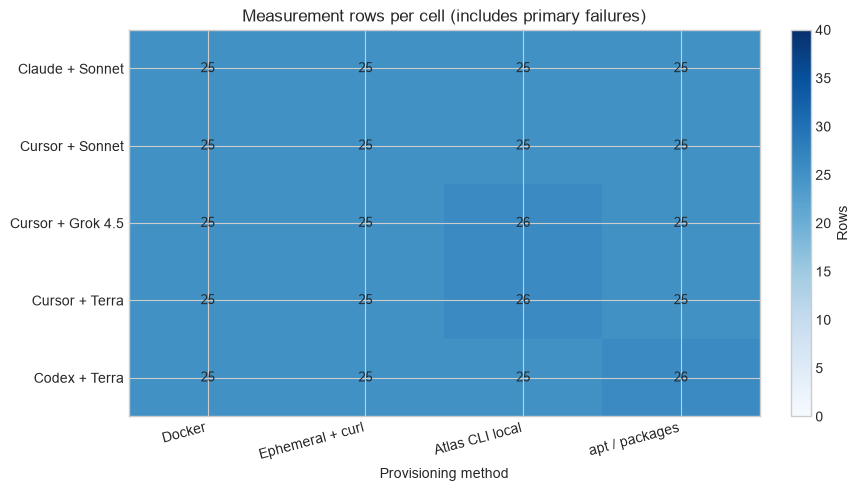

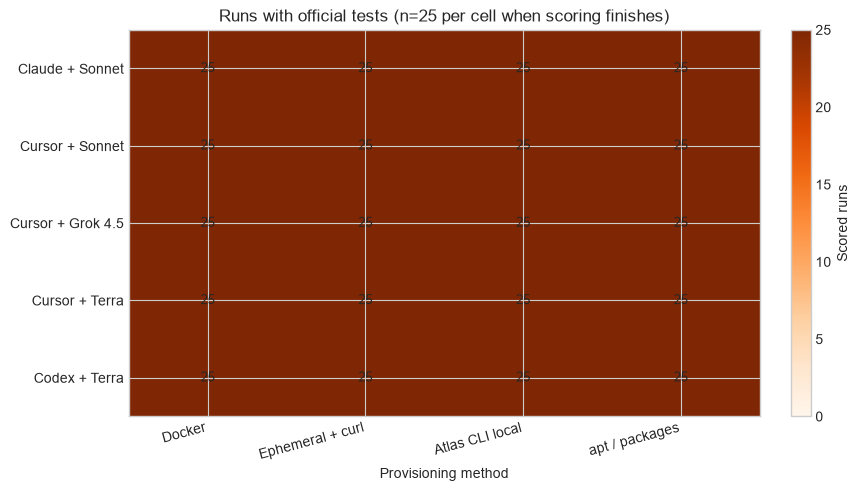

In [137]:
per_run_sql = f"""
SELECT
    run_request_id,
    run_id,
    agent,
    model,
    resolved_extend_id,
    prompt_id,
    repeat_idx,
    status,
    exit_reason,
    test_pass_count,
    test_fail_count,
    agent_time_ms / 1000.0 AS runtime_s,
    num_turns,
    tool_calls_total,
    tool_calls_failed,
    input_tokens,
    output_tokens,
    cost_usd_micros / 1000000.0 AS cost_usd
FROM measurements
WHERE run_request_id IN ({REQUEST_SQL})
ORDER BY agent, model, prompt_id, repeat_idx
"""

runs = assign_extension(_with_method_column(ax_query(per_run_sql)))
READY = not runs.empty
if not READY:
    print("No measurements yet. Re-run from this cell when the request finishes.")
else:
    numeric_columns = [
        "repeat_idx",
        "test_pass_count",
        "test_fail_count",
        "runtime_s",
        "num_turns",
        "tool_calls_total",
        "tool_calls_failed",
        "input_tokens",
        "output_tokens",
        "cost_usd",
    ]
    present = [column for column in numeric_columns if column in runs.columns]
    runs[present] = runs[present].apply(pd.to_numeric)
    runs["from_fillin"] = runs["run_request_id"].isin(FILLIN_REQUEST_IDS)
    runs["harness_error"] = runs["exit_reason"].eq("model_unsupported_by_harness")
    runs["has_official_tests"] = (
        runs["test_pass_count"].fillna(0) + runs["test_fail_count"].fillna(0)
    ) > 0
    runs["method"] = pd.Categorical(runs["method"], categories=METHOD_ORDER, ordered=True)
    print(f"Measurement rows: {len(runs)} (intended complete sample {EXPECTED_TRIALS})")
    print(
        "Official tests present: "
        f"{int(runs['has_official_tests'].sum())} / {len(runs)} "
        f"(fill-ins scored: {int(runs.loc[runs['from_fillin'], 'has_official_tests'].sum())} / "
        f"{int(runs['from_fillin'].sum())})"
    )
    print("By request (primary vs fill-in):")
    display(
        pd.Series(
            {
                "primary": int((~runs["from_fillin"]).sum()),
                "fill-in": int(runs["from_fillin"].sum()),
            },
            name="rows",
        ).to_frame()
    )
    print("status / exit_reason:")
    display(runs["status"].value_counts(dropna=False).rename("n").to_frame())
    display(runs["exit_reason"].fillna("(null)").value_counts().rename("n").to_frame())

    coverage = (
        runs.groupby(["extension", "method"], observed=True)
        .agg(
            n=("run_id", "size"),
            fillins=("from_fillin", "sum"),
            harness_errors=("harness_error", "sum"),
        )
        .reset_index()
    )
    n_pivot = (
        coverage.pivot(index="extension", columns="method", values="n")
        .reindex(index=EXTENSION_ORDER, columns=METHOD_ORDER)
    )
    fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
    image = ax.imshow(n_pivot.to_numpy(dtype=float), cmap="Blues", vmin=0, vmax=40, aspect="auto")
    ax.set_xticks(range(len(METHOD_ORDER)), [label_of(m) for m in METHOD_ORDER], rotation=15, ha="right")
    ax.set_yticks(range(len(EXTENSION_ORDER)), [label_of(e) for e in EXTENSION_ORDER])
    ax.set_title("Measurement rows per cell (includes primary failures)")
    for i, extension in enumerate(EXTENSION_ORDER):
        for j, method in enumerate(METHOD_ORDER):
            value = n_pivot.loc[extension, method]
            ax.text(j, i, "—" if pd.isna(value) else f"{int(value)}", ha="center", va="center", fontsize=9)
    fig.colorbar(image, ax=ax, fraction=0.046, label="Rows")
    ax.set_xlabel("Provisioning method")
    plt.show()

    scored_pivot = (
        runs.groupby(["extension", "method"], observed=True)["has_official_tests"]
        .sum()
        .unstack(fill_value=0)
        .reindex(index=EXTENSION_ORDER, columns=METHOD_ORDER)
    )
    fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
    image = ax.imshow(
        scored_pivot.to_numpy(dtype=float),
        cmap="Oranges",
        vmin=0,
        vmax=EXPECTED_PER_CELL,
        aspect="auto",
    )
    ax.set_xticks(range(len(METHOD_ORDER)), [label_of(m) for m in METHOD_ORDER], rotation=15, ha="right")
    ax.set_yticks(range(len(EXTENSION_ORDER)), [label_of(e) for e in EXTENSION_ORDER])
    ax.set_title("Runs with official tests (n=25 per cell when scoring finishes)")
    ax.set_xlabel("Provisioning method")
    for i, extension in enumerate(EXTENSION_ORDER):
        for j, method in enumerate(METHOD_ORDER):
            value = scored_pivot.loc[extension, method]
            ax.text(j, i, "—" if pd.isna(value) else f"{int(value)}", ha="center", va="center", fontsize=9)
    fig.colorbar(image, ax=ax, fraction=0.046, label="Scored runs")
    plt.show()
    if int(runs["has_official_tests"].sum()) < EXPECTED_TRIALS:
        print(
            "SCORING GAP: completion charts below use only scored runs. "
            "Re-run from the measurements cell after AX finishes grading, "
            "or `ax run rerun --tests <request-id>` if scoring is stuck."
        )


## Official test outcomes

Three packed scorers. Failures below are counts by test name, not
stderr (stderr can contain connection strings).


In [138]:
tests_sql = f"""
SELECT
    run_request_id,
    run_id,
    agent,
    model,
    resolved_extend_id,
    prompt_id,
    repeat_idx,
    test_name,
    exit_code = 0 AS passed,
    exit_code,
    substring(coalesce(stderr_tail, ''), 1, 240) AS stderr_tail
FROM test_output
WHERE run_request_id IN ({REQUEST_SQL})
ORDER BY agent, prompt_id, repeat_idx, test_name
"""

if not READY:
    tests = pd.DataFrame()
    print("Waiting for measurements.")
else:
    tests = assign_extension(_with_method_column(ax_query(tests_sql)))
    tests["repeat_idx"] = pd.to_numeric(tests["repeat_idx"])
    tests["exit_code"] = pd.to_numeric(tests["exit_code"])
    tests["passed"] = tests["passed"].map(
        lambda value: str(value).lower() in {"true", "1", "t"}
    )
    tests["method"] = pd.Categorical(tests["method"], categories=METHOD_ORDER, ordered=True)
    print(f"test_output rows: {len(tests)}")
    print(
        "crash signatures: "
        f"json.parse={(tests['stderr_tail'].str.contains('JSON.parse', case=False, na=False)).sum()}, "
        f"maxBuffer={(tests['stderr_tail'].str.contains('maxBuffer', case=False, na=False)).sum()}, "
        f"html={(tests['stderr_tail'].str.contains('leafygreen|<!DOCTYPE', case=False, na=False, regex=True)).sum()}, "
        f"weird_exit={(~tests['exit_code'].isin([0, 1])).sum()}"
    )
    test_summary = (
        tests.groupby(["extension", "method", "test_name"], observed=True)["passed"]
        .agg(passes="sum", n="count", rate="mean")
        .reset_index()
    )
    test_summary["rate_pct"] = test_summary["rate"] * 100
    fail_counts = (
        tests.loc[tests["passed"].eq(False)]
        .groupby(["method", "test_name"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(METHOD_ORDER)
    )
    print("Failed test rows by method × test (no stderr):")
    display(fail_counts)


test_output rows: 1500
crash signatures: json.parse=0, maxBuffer=0, html=0, weird_exit=0
Failed test rows by method × test (no stderr):


test_name,connection-verified-in-agent,uri-reported
method,,
docker,2,0
atlas-ephemeral-curl,16,0
atlas-cli-local,1,1
local-package-manager,1,0


## Job completion (primary: method, pooled)

A run is graded when it has official test rows and is not a harness
`model_unsupported_by_harness` error. Primary-request sandbox failures
(`starved`, `never_started`) drop out here; fill-ins take their place.


Graded trials: 500 (intended 500)
Fill-in share of graded: 63 / 500
Rows where measurements.status==pass disagrees with all-three-tests: 0
Graded n per cell:


method,Docker,Ephemeral + curl,Atlas CLI local,apt / packages
extension,,,,
Claude + Sonnet,25,25,25,25
Cursor + Sonnet,25,25,25,25
Cursor + Grok 4.5,25,25,25,25
Cursor + Terra,25,25,25,25
Codex + Terra,25,25,25,25


Every extension × method cell has ≥25 graded rows.


,value
measurement_rows,503.000
graded_runs,500.000
harness_errors,0.000
all_three_tests_pass,479.000
pooled_pct,95.800
pooled_lo_pct,94.308
pooled_hi_pct,96.913
substitution_runs,0.000
total_cost_usd,116.121
mean_cost_usd,0.232


,method_label,runs,all_tests_passed,pass_rate_pct,pass_rate_lo_pct,pass_rate_hi_pct,uri_and_connection,substitution
0,Docker,125,123,98.4,95.8,99.4,123,0
1,Ephemeral + curl,125,109,87.2,82.3,90.9,109,0
2,Atlas CLI local,125,123,98.4,95.8,99.4,123,0
3,apt / packages,125,124,99.2,97.0,99.8,124,0


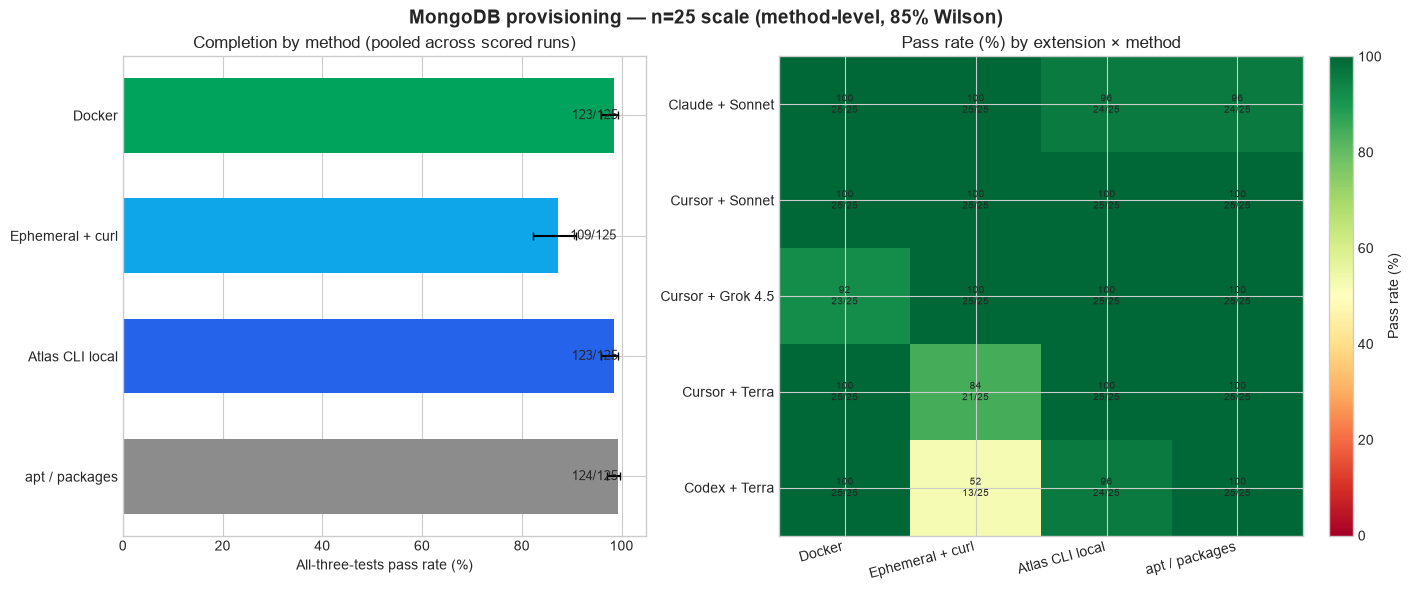

n=5 Atlas CLI cloud overlay: 0/25 all-three (partial-credit mean 9.3%). Scale skipped this auth-required method; shown on the partial-credit heatmap and all-runs efficiency charts.


In [139]:
if not READY or tests.empty:
    summary = pd.DataFrame()
    method_summary = pd.DataFrame()
    GRADED_N5_CLOUD = pd.DataFrame()
    GRADED_WITH_AUTH = pd.DataFrame()
    print("Waiting for tests.")
else:
    wide = (
        tests.pivot_table(
            index="run_id",
            columns="test_name",
            values="passed",
            aggfunc="max",
            observed=True,
        )
        .reset_index()
    )
    for name in TEST_NAMES:
        if name not in wide.columns:
            wide[name] = False
    wide["all_tests_passed"] = wide[TEST_NAMES].all(axis=1)
    wide["uri_and_connection"] = (
        wide["uri-reported"] & wide["connection-verified-in-agent"]
    )
    wide["substitution"] = wide["uri_and_connection"] & ~wide["method-constraint"]

    runs = runs.merge(
        wide[
            [
                "run_id",
                "all_tests_passed",
                "uri_and_connection",
                "substitution",
                *TEST_NAMES,
            ]
        ],
        on="run_id",
        how="left",
    )
    for column in TEST_NAMES + ["all_tests_passed", "uri_and_connection", "substitution"]:
        runs[column] = runs[column].astype("boolean")

    graded = runs.loc[
        runs["harness_error"].eq(False)
        & runs["all_tests_passed"].notna()
        & runs["method"].isin(METHOD_ORDER)
    ].copy()
    graded["passed"] = graded["all_tests_passed"].astype(bool)
    graded["pass_frac"] = graded[TEST_NAMES].astype(float).mean(axis=1)
    graded["tests_passed_n"] = graded[TEST_NAMES].astype(int).sum(axis=1)
    GRADED = graded
    READY_GRADED = not GRADED.empty

    status_mismatch = int((GRADED["status"].eq("pass") != GRADED["passed"]).sum())
    print(f"Graded trials: {len(GRADED)} (intended {EXPECTED_TRIALS})")
    print(f"Fill-in share of graded: {int(GRADED['from_fillin'].sum())} / {len(GRADED)}")
    print(f"Rows where measurements.status==pass disagrees with all-three-tests: {status_mismatch}")

    cell_n = (
        GRADED.groupby(["extension", "method"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(index=EXTENSION_ORDER, columns=METHOD_ORDER)
    )
    print("Graded n per cell:")
    display(cell_n.rename(index=label_of, columns=label_of))
    short = (cell_n < EXPECTED_PER_CELL).stack()
    short = short[short]
    if short.empty:
        print(f"Every extension × method cell has ≥{EXPECTED_PER_CELL} graded rows.")
    else:
        print("Cells under n=25:")
        display(short.rename("under").to_frame())

    method_summary = (
        GRADED.groupby("method", observed=True)
        .agg(
            runs=("run_id", "size"),
            all_tests_passed=("passed", "sum"),
            uri_and_connection=("uri_and_connection", "sum"),
            substitution=("substitution", "sum"),
        )
        .reindex(METHOD_ORDER)
        .reset_index()
    )
    add_wilson_columns(method_summary, "all_tests_passed", "runs")
    method_summary["method_label"] = method_summary["method"].map(DISPLAY_NAMES)

    _, pool_lo, pool_hi = wilson_interval(GRADED["passed"].sum(), len(GRADED))
    totals = pd.Series(
        {
            "measurement_rows": len(runs),
            "graded_runs": len(GRADED),
            "harness_errors": int(runs["harness_error"].sum()),
            "all_three_tests_pass": int(GRADED["passed"].sum()),
            "pooled_pct": float(GRADED["passed"].mean()) * 100 if len(GRADED) else np.nan,
            "pooled_lo_pct": pool_lo * 100,
            "pooled_hi_pct": pool_hi * 100,
            "substitution_runs": int(GRADED["substitution"].sum()),
            "total_cost_usd": float(GRADED["cost_usd"].sum()),
            "mean_cost_usd": float(GRADED["cost_usd"].mean()),
            "mean_runtime_s": float(GRADED["runtime_s"].mean()),
            "mean_turns": float(GRADED["num_turns"].mean()),
            "mean_tool_calls": float(GRADED["tool_calls_total"].mean()),
        }
    )
    display(totals.to_frame("value").round(3))
    display(
        method_summary[
            [
                "method_label",
                "runs",
                "all_tests_passed",
                "pass_rate_pct",
                "pass_rate_lo_pct",
                "pass_rate_hi_pct",
                "uri_and_connection",
                "substitution",
            ]
        ].round(1)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), constrained_layout=True)
    fig.suptitle(
        "MongoDB provisioning — n=25 scale (method-level, 85% Wilson)",
        fontsize=14,
        fontweight="bold",
    )
    rates = method_summary.set_index("method").reindex(METHOD_ORDER)
    y_methods = [m for m in METHOD_ORDER if pd.notna(rates.loc[m, "runs"])]
    y = np.arange(len(y_methods))
    lo_err = np.clip(
        [(rates.loc[m, "pass_rate"] - rates.loc[m, "pass_rate_lo"]) * 100 for m in y_methods],
        0,
        None,
    )
    hi_err = np.clip(
        [(rates.loc[m, "pass_rate_hi"] - rates.loc[m, "pass_rate"]) * 100 for m in y_methods],
        0,
        None,
    )
    axes[0].barh(
        y,
        [rates.loc[m, "pass_rate_pct"] for m in y_methods],
        color=[COLORS[m] for m in y_methods],
        xerr=np.vstack([lo_err, hi_err]),
        capsize=3,
        height=0.62,
    )
    axes[0].set_yticks(y, [label_of(m) for m in y_methods])
    axes[0].invert_yaxis()
    axes[0].set_xlim(0, 105)
    axes[0].set_xlabel("All-three-tests pass rate (%)")
    axes[0].set_title("Completion by method (pooled across scored runs)")
    for yi, method in enumerate(y_methods):
        row = rates.loc[method]
        axes[0].text(
            min(float(row.pass_rate_pct) + 2.5, 90),
            yi,
            f"{int(row.all_tests_passed)}/{int(row.runs)}",
            va="center",
            fontsize=9,
        )

    pass_pivot = (
        GRADED.pivot_table(
            index="extension",
            columns="method",
            values="passed",
            aggfunc="mean",
            observed=True,
        )
        .reindex(index=EXTENSION_ORDER, columns=METHOD_ORDER)
        * 100
    )
    image = axes[1].imshow(
        pass_pivot.to_numpy(dtype=float), cmap="RdYlGn", vmin=0, vmax=100, aspect="auto"
    )
    axes[1].set_xticks(
        np.arange(len(METHOD_ORDER)),
        [label_of(m) for m in METHOD_ORDER],
        rotation=15,
        ha="right",
    )
    axes[1].set_yticks(
        np.arange(len(EXTENSION_ORDER)),
        [label_of(e) for e in EXTENSION_ORDER],
    )
    kn = GRADED.pivot_table(
        index="extension", columns="method", values="passed", aggfunc=["sum", "count"], observed=True
    )
    for i, extension in enumerate(EXTENSION_ORDER):
        for j, method in enumerate(METHOD_ORDER):
            value = pass_pivot.loc[extension, method]
            k = kn["sum"].reindex(index=EXTENSION_ORDER, columns=METHOD_ORDER).loc[extension, method]
            n = kn["count"].reindex(index=EXTENSION_ORDER, columns=METHOD_ORDER).loc[extension, method]
            text = "—" if pd.isna(value) else f"{value:.0f}\n{int(k)}/{int(n)}"
            axes[1].text(j, i, text, ha="center", va="center", fontsize=7.5)
    axes[1].set_title("Pass rate (%) by extension × method")
    fig.colorbar(image, ax=axes[1], fraction=0.046, label="Pass rate (%)")
    plt.show()

    GRADED_N5_CLOUD = load_n5_auth_cloud()
    if GRADED_N5_CLOUD.empty:
        GRADED_WITH_AUTH = GRADED.copy()
        print("n=5 Atlas CLI cloud overlay unavailable; charts stay scale-only.")
    else:
        GRADED_WITH_AUTH = pd.concat([GRADED, GRADED_N5_CLOUD], ignore_index=True)
        GRADED_WITH_AUTH["method"] = pd.Categorical(
            GRADED_WITH_AUTH["method"].astype(str),
            categories=METHOD_ORDER_WITH_AUTH,
            ordered=True,
        )
        n5_k = int(GRADED_N5_CLOUD["passed"].sum())
        n5_n = len(GRADED_N5_CLOUD)
        n5_frac = float(GRADED_N5_CLOUD["pass_frac"].mean()) * 100
        print(
            f"n=5 Atlas CLI cloud overlay: {n5_k}/{n5_n} all-three "
            f"(partial-credit mean {n5_frac:.1f}%). Scale skipped this "
            "auth-required method; shown on the partial-credit heatmap and "
            "all-runs efficiency charts."
        )


## Completion slices (supporting)

Harness / model / model+harness breakdowns. Confirmatory claims stay
method-level; these charts are robustness checks.


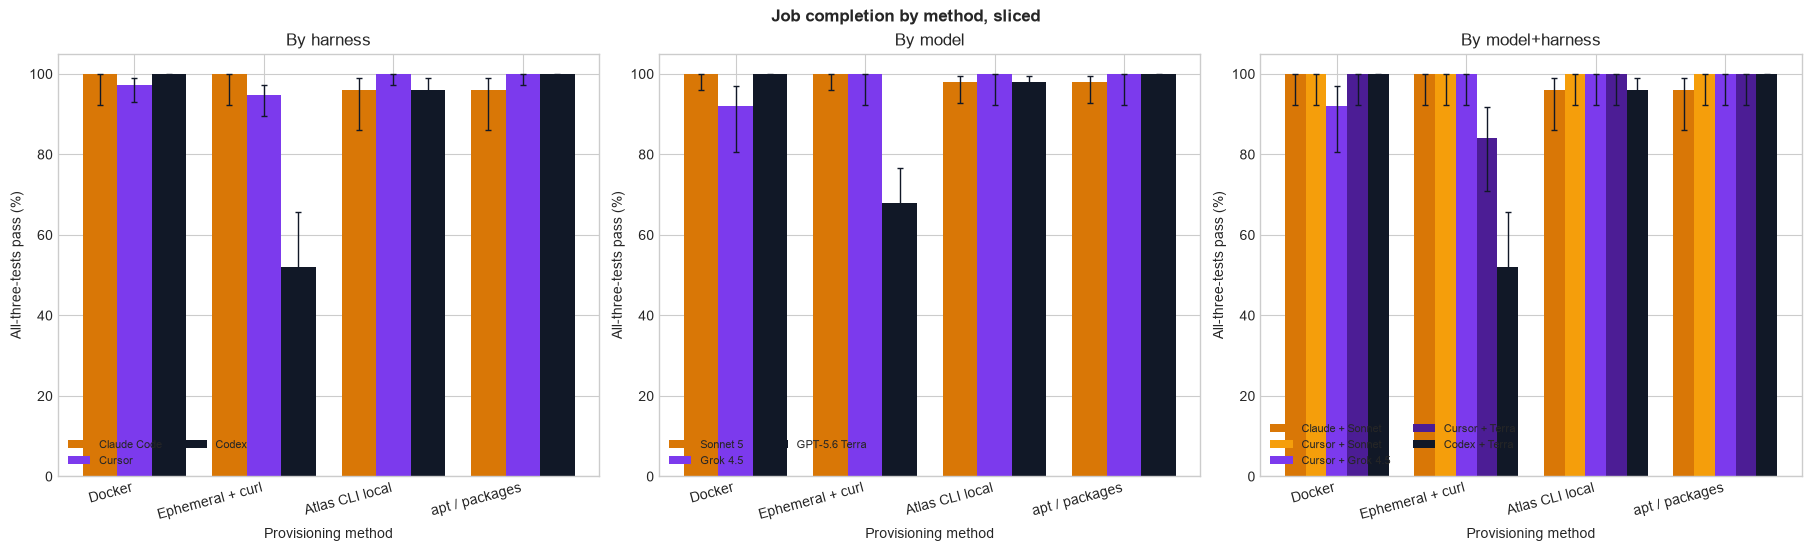

By harness (pooled over methods)


,label,runs,k,pass_rate_pct,pass_rate_lo_pct,pass_rate_hi_pct
0,Claude Code,100,98,98.0,94.8,99.2
1,Codex,100,87,87.0,81.4,91.1
2,Cursor,300,294,98.0,96.5,98.9


By model (pooled)


,label,runs,k,pass_rate_pct,pass_rate_lo_pct,pass_rate_hi_pct
0,Sonnet 5,200,198,99.0,97.4,99.6
1,GPT-5.6 Terra,200,183,91.5,88.2,93.9
2,Grok 4.5,100,98,98.0,94.8,99.2


By extension (pooled over methods)


,label,runs,k,pass_rate_pct,pass_rate_lo_pct,pass_rate_hi_pct
0,Claude + Sonnet,100,98,98.0,94.8,99.2
1,Cursor + Sonnet,100,100,100.0,98.0,100.0
2,Cursor + Grok 4.5,100,98,98.0,94.8,99.2
3,Cursor + Terra,100,96,96.0,92.1,98.0
4,Codex + Terra,100,87,87.0,81.4,91.1


In [140]:
if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    def rate_table(group_cols):
        table = (
            GRADED.groupby(group_cols, observed=True)
            .agg(runs=("run_id", "size"), k=("passed", "sum"))
            .reset_index()
        )
        add_wilson_columns(table, "k", "runs")
        return table

    by_harness = rate_table(["agent", "method"]).rename(columns={"agent": "harness"})
    by_model = rate_table(["model", "method"])
    by_extension = rate_table(["extension", "method"])
    CELL = by_extension.copy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.4), constrained_layout=True)
    grouped_bars(
        axes[0], by_harness, "harness", "pass_rate_pct", "By harness",
        "All-three-tests pass (%)", percent=True, groups=HARNESS_ORDER,
        lo_column="pass_rate_lo_pct", hi_column="pass_rate_hi_pct",
    )
    grouped_bars(
        axes[1], by_model, "model", "pass_rate_pct", "By model",
        "All-three-tests pass (%)", percent=True, groups=MODEL_ORDER,
        lo_column="pass_rate_lo_pct", hi_column="pass_rate_hi_pct",
    )
    grouped_bars(
        axes[2], by_extension, "extension", "pass_rate_pct", "By model+harness",
        "All-three-tests pass (%)", percent=True,
        lo_column="pass_rate_lo_pct", hi_column="pass_rate_hi_pct",
    )
    fig.suptitle("Job completion by method, sliced", fontweight="bold")
    plt.show()

    print("By harness (pooled over methods)")
    h = rate_table(["agent"])
    display(
        h.assign(label=h["agent"].map(DISPLAY_NAMES))[
            ["label", "runs", "k", "pass_rate_pct", "pass_rate_lo_pct", "pass_rate_hi_pct"]
        ].round(1)
    )
    print("By model (pooled)")
    m = rate_table(["model"])
    display(
        m.assign(label=m["model"].map(DISPLAY_NAMES).fillna(m["model"].astype(str)))[
            ["label", "runs", "k", "pass_rate_pct", "pass_rate_lo_pct", "pass_rate_hi_pct"]
        ].round(1)
    )
    print("By extension (pooled over methods)")
    e = rate_table(["extension"])
    display(
        e.assign(label=e["extension"].map(DISPLAY_NAMES))[
            ["label", "runs", "k", "pass_rate_pct", "pass_rate_lo_pct", "pass_rate_hi_pct"]
        ].round(1)
    )


## Method contrasts at 85% (completion)

Newcombe difference of Wilson intervals. Labels follow the tech design:
material (≥10pp and CI excludes 0), practically equivalent (CI inside
±10pp), or underpowered / inconclusive.


,contrast,left_kn,right_kn,diff_pp,lo_pp,hi_pp,label
0,Atlas CLI local − Docker,123/125,123/125,0.0,-2.8,2.8,Practically equivalent
1,apt / packages − Docker,124/125,123/125,0.8,-1.6,3.4,Practically equivalent
2,Ephemeral + curl − Docker,109/125,123/125,-11.2,-16.2,-6.7,Material difference
3,Atlas CLI local − apt / packages,123/125,124/125,-0.8,-3.4,1.6,Practically equivalent
4,Ephemeral + curl − Atlas CLI local,109/125,123/125,-11.2,-16.2,-6.7,Material difference
5,Ephemeral + curl − apt / packages,109/125,124/125,-12.0,-17.0,-7.7,Material difference


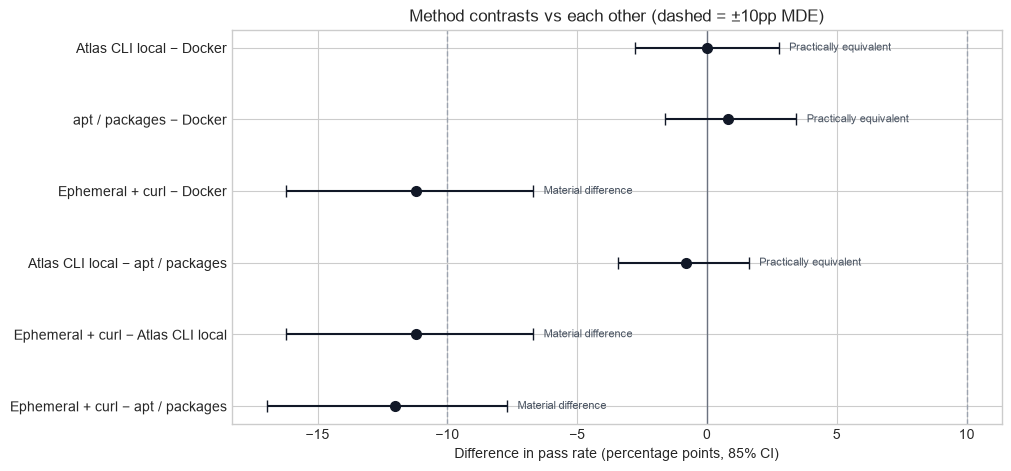

In [141]:
if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    pairs = [
        ("atlas-cli-local", "docker"),
        ("local-package-manager", "docker"),
        ("atlas-ephemeral-curl", "docker"),
        ("atlas-cli-local", "local-package-manager"),
        ("atlas-ephemeral-curl", "atlas-cli-local"),
        ("atlas-ephemeral-curl", "local-package-manager"),
    ]
    rows = []
    for left, right in pairs:
        a = GRADED[GRADED["method"].eq(left)]
        b = GRADED[GRADED["method"].eq(right)]
        diff, lo, hi = newcombe_diff(a["passed"].sum(), len(a), b["passed"].sum(), len(b))
        rows.append(
            {
                "contrast": f"{label_of(left)} − {label_of(right)}",
                "left_kn": f"{int(a['passed'].sum())}/{len(a)}",
                "right_kn": f"{int(b['passed'].sum())}/{len(b)}",
                "diff_pp": diff * 100,
                "lo_pp": lo * 100,
                "hi_pp": hi * 100,
                "label": label_abs_diff(diff, lo, hi),
            }
        )
    contrasts = pd.DataFrame(rows)
    display(contrasts.round(1))

    fig, ax = plt.subplots(figsize=(10, 4.6), constrained_layout=True)
    y = np.arange(len(contrasts))
    ax.axvline(0, color="#6B7280", linewidth=1)
    ax.axvline(-MDE_PP * 100, color="#9CA3AF", linestyle="--", linewidth=1)
    ax.axvline(MDE_PP * 100, color="#9CA3AF", linestyle="--", linewidth=1)
    ax.errorbar(
        contrasts["diff_pp"],
        y,
        xerr=np.vstack(
            [
                contrasts["diff_pp"] - contrasts["lo_pp"],
                contrasts["hi_pp"] - contrasts["diff_pp"],
            ]
        ),
        fmt="o",
        color="#111827",
        ecolor="#111827",
        capsize=4,
        markersize=7,
    )
    ax.set_yticks(y, contrasts["contrast"])
    ax.invert_yaxis()
    ax.set_xlabel("Difference in pass rate (percentage points, 85% CI)")
    ax.set_title("Method contrasts vs each other (dashed = ±10pp MDE)")
    for yi, row in contrasts.iterrows():
        ax.text(row["hi_pp"] + 0.4, yi, row["label"], va="center", fontsize=8, color="#4B5563")
    plt.show()


## Scorer funnel

Where trials fail: URI missing, no in-agent connection evidence, or
method-constraint (ephemeral-curl substituting a local URI).


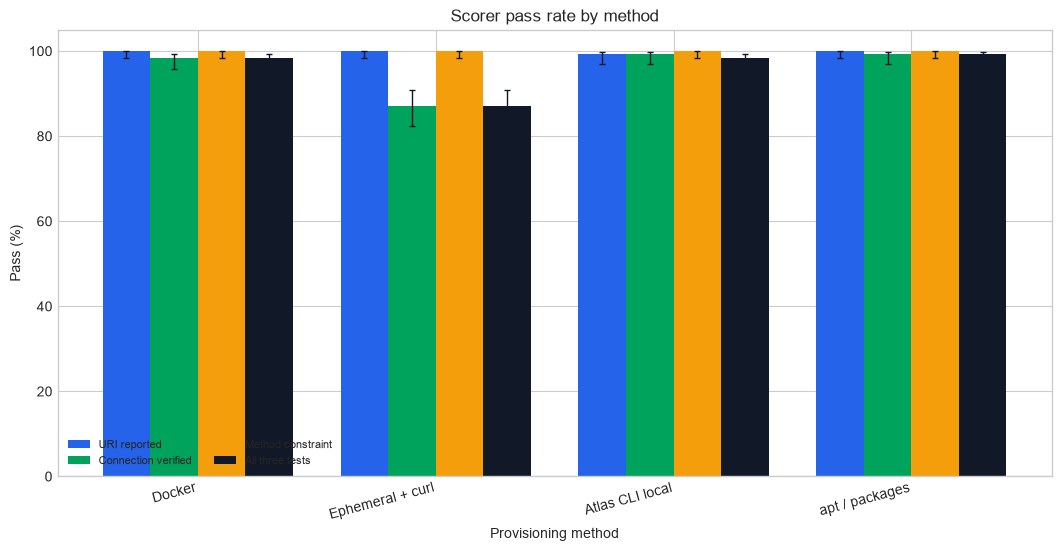

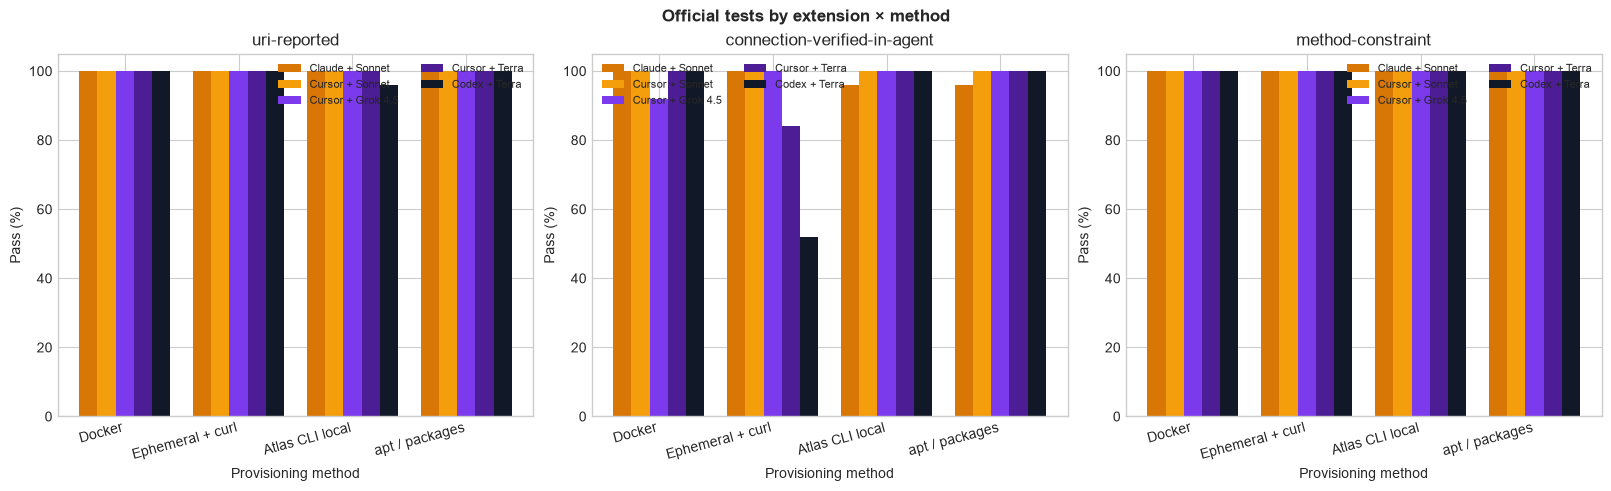

In [142]:
if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    funnel_rows = []
    for method in METHOD_ORDER:
        subset = GRADED[GRADED["method"].eq(method)]
        n = len(subset)
        for test_name, pretty in [
            ("uri-reported", "URI reported"),
            ("connection-verified-in-agent", "Connection verified"),
            ("method-constraint", "Method constraint"),
            ("passed", "All three tests"),
        ]:
            k = int(subset[test_name].sum())
            p, lo, hi = wilson_interval(k, n)
            funnel_rows.append(
                {
                    "method": method,
                    "test": pretty,
                    "k": k,
                    "n": n,
                    "pass_rate_pct": p * 100,
                    "pass_rate_lo_pct": lo * 100,
                    "pass_rate_hi_pct": hi * 100,
                }
            )
    funnel = pd.DataFrame(funnel_rows)
    test_order = ["URI reported", "Connection verified", "Method constraint", "All three tests"]
    fig, ax = plt.subplots(figsize=(10.5, 5.4), constrained_layout=True)
    grouped_bars(
        ax,
        funnel.rename(columns={"test": "scorer"}),
        "scorer",
        "pass_rate_pct",
        "Scorer pass rate by method",
        "Pass (%)",
        percent=True,
        groups=test_order,
        lo_column="pass_rate_lo_pct",
        hi_column="pass_rate_hi_pct",
        xlabel="Provisioning method",
    )
    # Recolor scorers, not methods — grouped_bars used COLORS.get(scorer)
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
    for ax, test_name, title in [
        (axes[0], "uri-reported", "uri-reported"),
        (axes[1], "connection-verified-in-agent", "connection-verified-in-agent"),
        (axes[2], "method-constraint", "method-constraint"),
    ]:
        slice_ = test_summary[test_summary["test_name"] == test_name].copy()
        grouped_bars(ax, slice_, "extension", "rate_pct", title, "Pass (%)", percent=True)
    fig.suptitle("Official tests by extension × method", fontweight="bold")
    plt.show()


## Partial-credit pass rate

The charts above treat a run as 0 unless all three tests pass. That
turns “reported a URI and used the recipe, never pinged” into a total
miss. Here each run scores `k/3`: two tests passing is **0.67**, not 0.

All-or-nothing completion stays the primary job-completion metric.
This is a parallel reading of the same three tests. CIs are bootstrap
85% on the mean of per-run `k/3` (tests within a run are not independent
Bernoulli trials, so Wilson on all-three does not apply).

The **first table and first figure in this section are scale-only**.
Scroll to **Partial-credit by extension × method — Atlas CLI cloud is n=5**:
a table, then sliced bars, then the heatmap. Scale did not repeat that
auth-required method: every n=5 trial failed all three tests. Cloud cells
show k/3 and all-three `k/n`. Contrasts and the pooled k/3 print stay
scale-only.


Partial-credit mean (k/3) vs all-three-tests (same runs)


,method_label,n,all_three,all_three_pct,pass_frac_pct,pass_frac_lo_pct,pass_frac_hi_pct
0,Docker,125,123,98.4,99.5,98.9,100.0
1,Ephemeral + curl,125,109,87.2,95.7,94.1,97.1
2,Atlas CLI local,125,123,98.4,99.5,98.9,100.0
3,apt / packages,125,124,99.2,99.7,99.2,100.0


Pooled partial-credit: 98.6% (85% bootstrap 98.1–99.0%) vs all-three 95.8%
Tests passed (k of 3) by method


tests_passed_n,0/3,1/3,2/3,3/3
method,,,,
Docker,0,0,2,123
Ephemeral + curl,0,0,16,109
Atlas CLI local,0,0,2,123
apt / packages,0,0,1,124


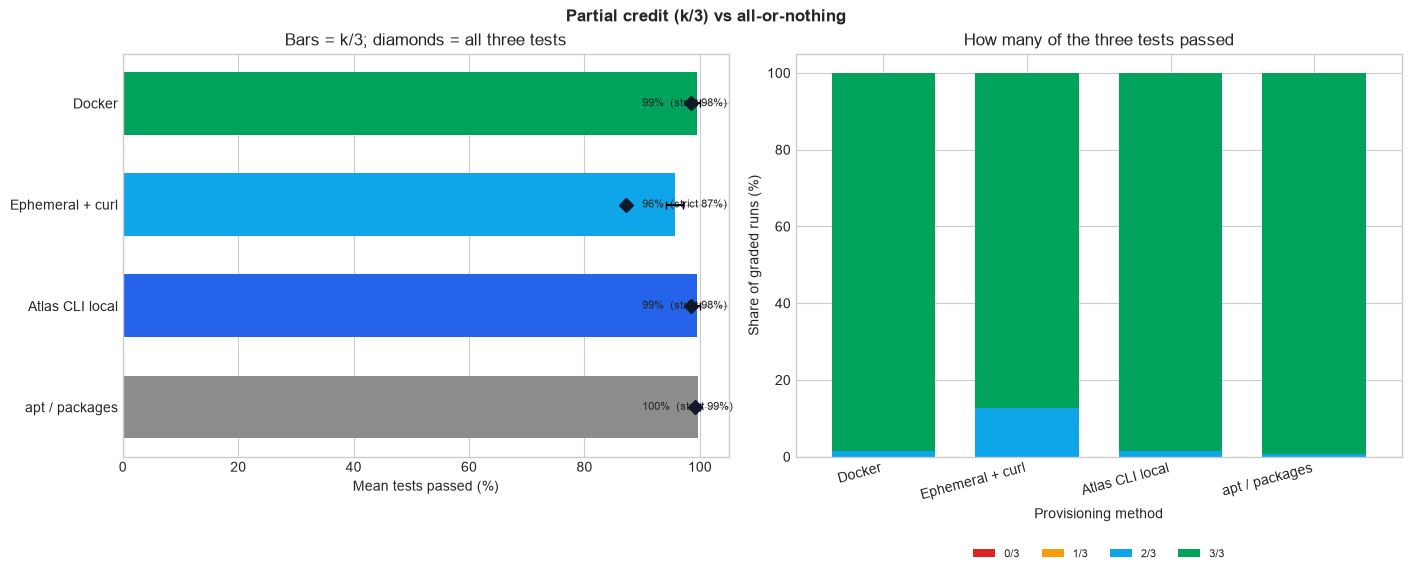

Partial-credit by extension × method — Atlas CLI cloud is n=5


method,Docker,Ephemeral + curl,Atlas CLI local,apt / packages,Atlas CLI cloud (n=5)
extension,,,,,
Claude + Sonnet,100.0,100.0,98.7,98.7,0.0
Cursor + Sonnet,100.0,100.0,100.0,100.0,6.7
Cursor + Grok 4.5,97.3,100.0,100.0,100.0,40.0
Cursor + Terra,100.0,94.7,100.0,100.0,0.0
Codex + Terra,100.0,84.0,98.7,100.0,0.0


All-three k/n (cloud is 0/5 per extension; not repeated at scale)


method,Docker,Ephemeral + curl,Atlas CLI local,apt / packages,Atlas CLI cloud (n=5)
extension,,,,,
Claude + Sonnet,25/25,25/25,24/25,24/25,0/5
Cursor + Sonnet,25/25,25/25,25/25,25/25,0/5
Cursor + Grok 4.5,23/25,25/25,25/25,25/25,0/5
Cursor + Terra,25/25,21/25,25/25,25/25,0/5
Codex + Terra,25/25,13/25,24/25,25/25,0/5


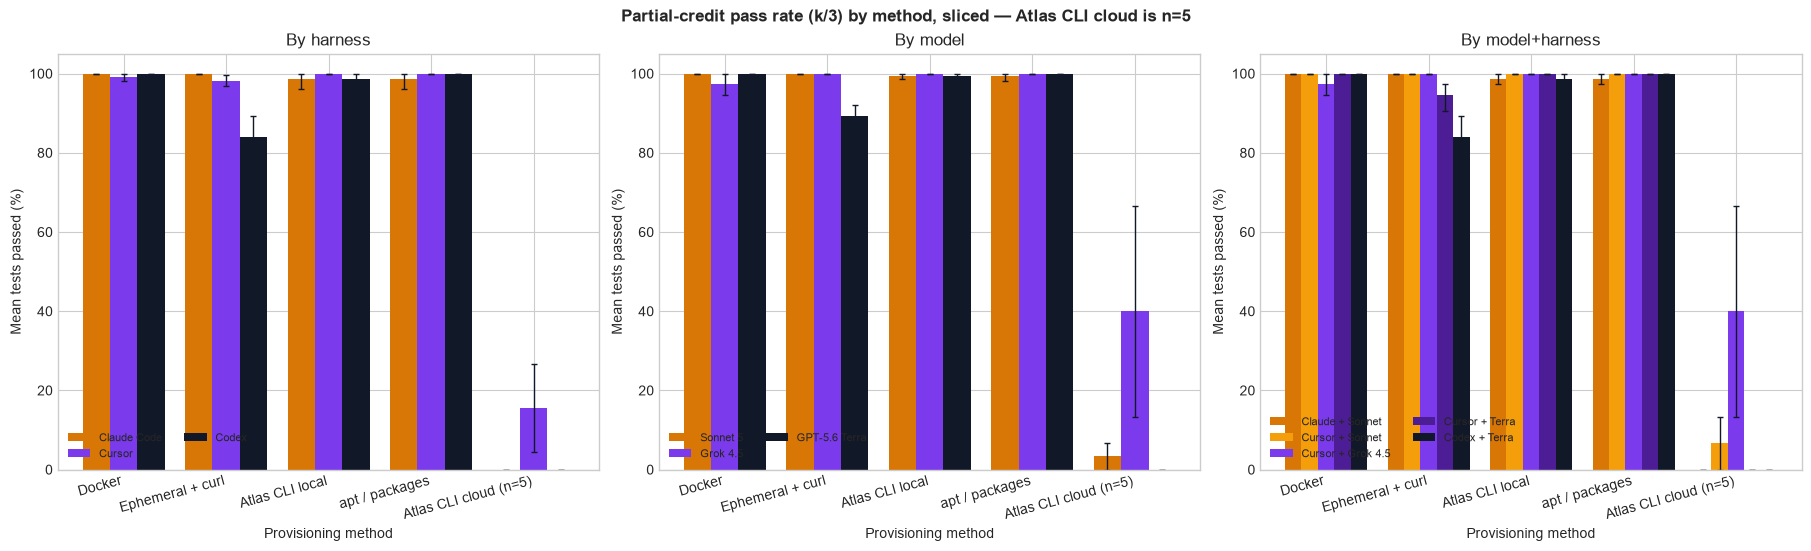

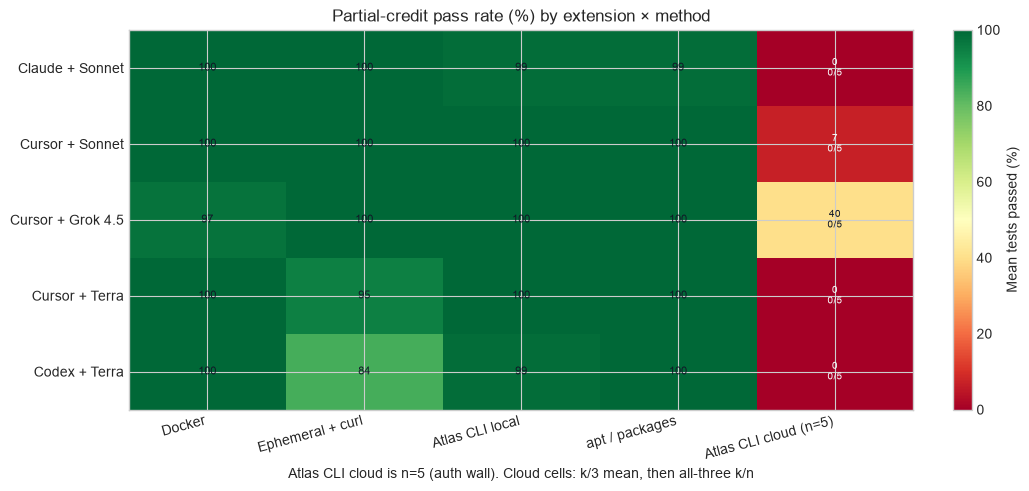

Partial-credit method contrasts (bootstrap 85% CI on mean k/3)


,contrast,diff_pp,lo_pp,hi_pp,label
0,Atlas CLI local − Docker,0.0,-0.8,0.8,Practically equivalent
1,apt / packages − Docker,0.3,-0.3,1.1,Practically equivalent
2,Ephemeral + curl − Docker,-3.7,-5.3,-2.1,Practically equivalent
3,Atlas CLI local − apt / packages,-0.3,-0.8,0.3,Practically equivalent
4,Ephemeral + curl − Atlas CLI local,-3.7,-5.3,-2.4,Practically equivalent
5,Ephemeral + curl − apt / packages,-4.0,-5.6,-2.4,Practically equivalent


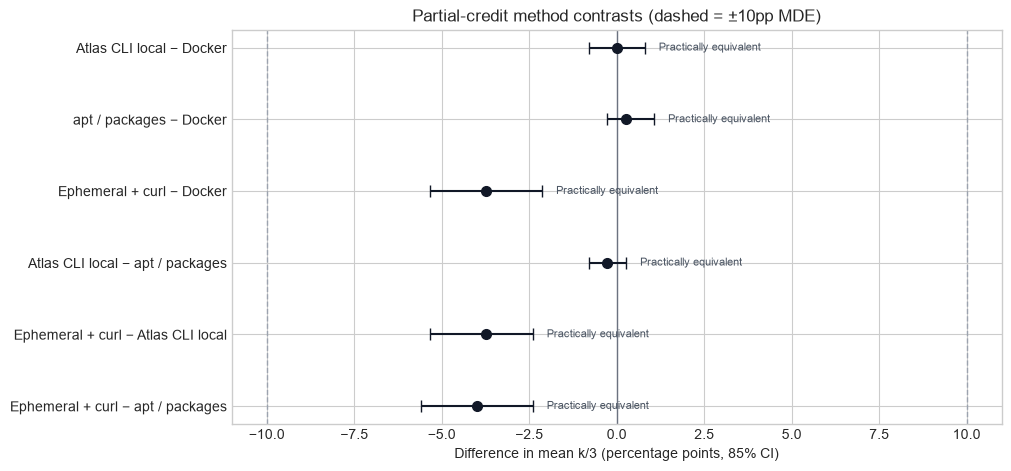

In [143]:
if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    def frac_summary(frame, group_cols):
        rows = []
        grouped = frame.groupby(group_cols, observed=True)
        for key, subset in grouped:
            key = key if isinstance(key, tuple) else (key,)
            mean, lo, hi = bootstrap_mean_ci(subset["pass_frac"].to_numpy(dtype=float))
            row = dict(zip(group_cols, key))
            row.update(
                {
                    "n": len(subset),
                    "all_three": int(subset["passed"].sum()),
                    "pass_frac": mean,
                    "pass_frac_lo": lo,
                    "pass_frac_hi": hi,
                    "pass_frac_pct": mean * 100,
                    "pass_frac_lo_pct": lo * 100,
                    "pass_frac_hi_pct": hi * 100,
                    "all_three_pct": float(subset["passed"].mean()) * 100,
                }
            )
            rows.append(row)
        return pd.DataFrame(rows)

    frac_method = frac_summary(GRADED, ["method"])
    frac_method["method"] = pd.Categorical(frac_method["method"], categories=METHOD_ORDER, ordered=True)
    frac_method = frac_method.sort_values("method")
    print("Partial-credit mean (k/3) vs all-three-tests (same runs)")
    display(
        frac_method.assign(method_label=frac_method["method"].map(DISPLAY_NAMES))[
            [
                "method_label",
                "n",
                "all_three",
                "all_three_pct",
                "pass_frac_pct",
                "pass_frac_lo_pct",
                "pass_frac_hi_pct",
            ]
        ].round(1)
    )

    pool_mean, pool_lo, pool_hi = bootstrap_mean_ci(GRADED["pass_frac"].to_numpy(dtype=float))
    print(
        f"Pooled partial-credit: {pool_mean*100:.1f}% "
        f"(85% bootstrap {pool_lo*100:.1f}–{pool_hi*100:.1f}%) vs "
        f"all-three {GRADED['passed'].mean()*100:.1f}%"
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), constrained_layout=True)
    fig.suptitle("Partial credit (k/3) vs all-or-nothing", fontweight="bold")
    y_methods = [m for m in METHOD_ORDER if m in set(frac_method["method"])]
    y = np.arange(len(y_methods))
    rates = frac_method.set_index("method")
    lo_err = np.clip(
        [rates.loc[m, "pass_frac_pct"] - rates.loc[m, "pass_frac_lo_pct"] for m in y_methods],
        0,
        None,
    )
    hi_err = np.clip(
        [rates.loc[m, "pass_frac_hi_pct"] - rates.loc[m, "pass_frac_pct"] for m in y_methods],
        0,
        None,
    )
    axes[0].barh(
        y,
        [rates.loc[m, "pass_frac_pct"] for m in y_methods],
        color=[COLORS[m] for m in y_methods],
        xerr=np.vstack([lo_err, hi_err]),
        capsize=3,
        height=0.62,
    )
    for yi, method in enumerate(y_methods):
        row = rates.loc[method]
        axes[0].plot(
            row.all_three_pct,
            yi,
            marker="D",
            color="#111827",
            markersize=7,
            zorder=4,
        )
        axes[0].text(
            min(row.pass_frac_pct + 1.8, 90),
            yi,
            f"{row.pass_frac_pct:.0f}%  (strict {row.all_three_pct:.0f}%)",
            va="center",
            fontsize=8,
        )
    axes[0].set_yticks(y, [label_of(m) for m in y_methods])
    axes[0].invert_yaxis()
    axes[0].set_xlim(0, 105)
    axes[0].set_xlabel("Mean tests passed (%)")
    axes[0].set_title("Bars = k/3; diamonds = all three tests")

    counts = (
        pd.crosstab(GRADED["method"], GRADED["tests_passed_n"])
        .reindex(index=METHOD_ORDER)
        .reindex(columns=[0, 1, 2, 3], fill_value=0)
    )
    print("Tests passed (k of 3) by method")
    display(
        counts.rename(index=lambda m: label_of(m)).rename(
            columns={0: "0/3", 1: "1/3", 2: "2/3", 3: "3/3"}
        )
    )
    share = counts.div(counts.sum(axis=1), axis=0) * 100
    share.plot(
        kind="bar",
        stacked=True,
        ax=axes[1],
        color=["#DC2626", "#F59E0B", "#0EA5E9", "#00A35C"],
        legend=False,
        width=0.72,
    )
    axes[1].set_xticklabels([label_of(m) for m in share.index], rotation=15, ha="right")
    axes[1].set_ylim(0, 105)
    axes[1].set_ylabel("Share of graded runs (%)")
    axes[1].set_xlabel("Provisioning method")
    axes[1].set_title("How many of the three tests passed")
    axes[1].legend(
        ["0/3", "1/3", "2/3", "3/3"],
        frameon=False,
        fontsize=8,
        ncol=4,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.28),
    )
    plt.show()

    overlay_frac = GRADED_WITH_AUTH if not GRADED_WITH_AUTH.empty else GRADED
    overlay_methods = [m for m in METHOD_ORDER_WITH_AUTH if m in set(overlay_frac["method"])]
    print("Partial-credit by extension × method — Atlas CLI cloud is n=5")
    ext_k3 = (
        overlay_frac.pivot_table(
            index="extension",
            columns="method",
            values="pass_frac",
            aggfunc="mean",
            observed=True,
        )
        .reindex(index=EXTENSION_ORDER, columns=overlay_methods)
        * 100
    )
    display(ext_k3.rename(index=label_of, columns=label_of).round(1))
    ext_kn = (
        overlay_frac.groupby(["extension", "method"], observed=True)["passed"]
        .agg(all_three="sum", n="size")
        .assign(kn=lambda d: d["all_three"].map(int).astype(str) + "/" + d["n"].map(int).astype(str))
        .reset_index()
        .pivot(index="extension", columns="method", values="kn")
        .reindex(index=EXTENSION_ORDER, columns=overlay_methods)
    )
    print("All-three k/n (cloud is 0/5 per extension; not repeated at scale)")
    display(ext_kn.rename(index=label_of, columns=label_of))
    frac_ext = frac_summary(overlay_frac, ["extension", "method"])
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.4), constrained_layout=True)
    grouped_bars(
        axes[0],
        frac_summary(overlay_frac, ["agent", "method"]).rename(columns={"agent": "harness"}),
        "harness",
        "pass_frac_pct",
        "By harness",
        "Mean tests passed (%)",
        percent=True,
        groups=HARNESS_ORDER,
        lo_column="pass_frac_lo_pct",
        hi_column="pass_frac_hi_pct",
        index_order=overlay_methods,
    )
    grouped_bars(
        axes[1],
        frac_summary(overlay_frac, ["model", "method"]),
        "model",
        "pass_frac_pct",
        "By model",
        "Mean tests passed (%)",
        percent=True,
        groups=MODEL_ORDER,
        lo_column="pass_frac_lo_pct",
        hi_column="pass_frac_hi_pct",
        index_order=overlay_methods,
    )
    grouped_bars(
        axes[2],
        frac_ext,
        "extension",
        "pass_frac_pct",
        "By model+harness",
        "Mean tests passed (%)",
        percent=True,
        lo_column="pass_frac_lo_pct",
        hi_column="pass_frac_hi_pct",
        index_order=overlay_methods,
    )
    fig.suptitle(
        "Partial-credit pass rate (k/3) by method, sliced — Atlas CLI cloud is n=5",
        fontweight="bold",
    )
    plt.show()

    heat = (
        overlay_frac.pivot_table(
            index="extension",
            columns="method",
            values="pass_frac",
            aggfunc="mean",
            observed=True,
        )
        .reindex(index=EXTENSION_ORDER, columns=overlay_methods)
        * 100
    )
    fig, ax = plt.subplots(figsize=(10.2, 4.8), constrained_layout=True)
    image = ax.imshow(heat.to_numpy(dtype=float), cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
    ax.set_xticks(
        np.arange(len(overlay_methods)),
        [label_of(m) for m in overlay_methods],
        rotation=15,
        ha="right",
    )
    ax.set_yticks(
        np.arange(len(EXTENSION_ORDER)),
        [label_of(e) for e in EXTENSION_ORDER],
    )
    for i, extension in enumerate(EXTENSION_ORDER):
        for j, method in enumerate(overlay_methods):
            value = heat.loc[extension, method]
            if pd.isna(value):
                text = "—"
            elif method == AUTH_METHOD:
                cell = overlay_frac.loc[
                    overlay_frac["extension"].eq(extension)
                    & overlay_frac["method"].eq(method)
                ]
                text = f"{value:.0f}\n{int(cell['passed'].sum())}/{len(cell)}"
            else:
                text = f"{value:.0f}"
            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=7 if method == AUTH_METHOD else 8,
                color="#F9FAFB" if (not pd.isna(value) and value < 40) else "#111827",
            )
    ax.set_title("Partial-credit pass rate (%) by extension × method")
    ax.set_xlabel(
        "Atlas CLI cloud is n=5 (auth wall). Cloud cells: k/3 mean, then all-three k/n"
    )
    fig.colorbar(image, ax=ax, fraction=0.046, label="Mean tests passed (%)")
    plt.show()

    pairs = [
        ("atlas-cli-local", "docker"),
        ("local-package-manager", "docker"),
        ("atlas-ephemeral-curl", "docker"),
        ("atlas-cli-local", "local-package-manager"),
        ("atlas-ephemeral-curl", "atlas-cli-local"),
        ("atlas-ephemeral-curl", "local-package-manager"),
    ]
    contrast_rows = []
    for left, right in pairs:
        a = GRADED.loc[GRADED["method"].eq(left), "pass_frac"].to_numpy(dtype=float)
        b = GRADED.loc[GRADED["method"].eq(right), "pass_frac"].to_numpy(dtype=float)
        diffs = np.empty(N_BOOT)
        for i in range(N_BOOT):
            diffs[i] = RNG.choice(a, size=a.size, replace=True).mean() - RNG.choice(
                b, size=b.size, replace=True
            ).mean()
        alpha = (1.0 - 0.85) / 2.0
        lo, hi = np.quantile(diffs, [alpha, 1.0 - alpha])
        diff = float(a.mean() - b.mean())
        contrast_rows.append(
            {
                "contrast": f"{label_of(left)} − {label_of(right)}",
                "diff_pp": diff * 100,
                "lo_pp": lo * 100,
                "hi_pp": hi * 100,
                "label": label_abs_diff(diff, lo, hi),
            }
        )
    frac_contrasts = pd.DataFrame(contrast_rows)
    print("Partial-credit method contrasts (bootstrap 85% CI on mean k/3)")
    display(frac_contrasts.round(1))

    fig, ax = plt.subplots(figsize=(10, 4.6), constrained_layout=True)
    y = np.arange(len(frac_contrasts))
    ax.axvline(0, color="#6B7280", linewidth=1)
    ax.axvline(-MDE_PP * 100, color="#9CA3AF", linestyle="--", linewidth=1)
    ax.axvline(MDE_PP * 100, color="#9CA3AF", linestyle="--", linewidth=1)
    ax.errorbar(
        frac_contrasts["diff_pp"],
        y,
        xerr=np.vstack(
            [
                frac_contrasts["diff_pp"] - frac_contrasts["lo_pp"],
                frac_contrasts["hi_pp"] - frac_contrasts["diff_pp"],
            ]
        ),
        fmt="o",
        color="#111827",
        ecolor="#111827",
        capsize=4,
        markersize=7,
    )
    ax.set_yticks(y, frac_contrasts["contrast"])
    ax.invert_yaxis()
    ax.set_xlabel("Difference in mean k/3 (percentage points, 85% CI)")
    ax.set_title("Partial-credit method contrasts (dashed = ±10pp MDE)")
    for yi, row in frac_contrasts.iterrows():
        ax.text(row["hi_pp"] + 0.4, yi, row["label"], va="center", fontsize=8, color="#4B5563")
    plt.show()


## Per-test pass rates

Three official tests as separate bars (not all-or-nothing). For ephemeral
+ curl this is the useful split: URI and method-constraint are near
ceiling; connection-verified is the miss.


Official test pass counts (k/n) by method


test,URI reported,Connection verified,Method constraint
method_label,,,
Docker,125/125,123/125,125/125
Ephemeral + curl,125/125,109/125,125/125
Atlas CLI local,124/125,124/125,125/125
apt / packages,125/125,124/125,125/125


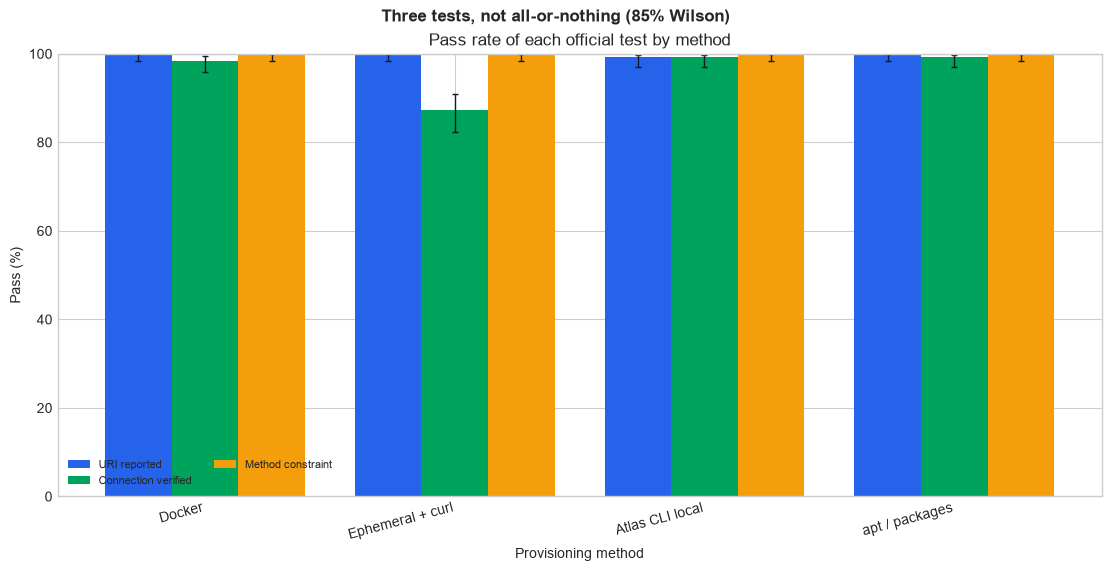

Ephemeral + curl only


test,URI reported,Connection verified,Method constraint
extension_label,,,
Claude + Sonnet,25/25,25/25,25/25
Cursor + Sonnet,25/25,25/25,25/25
Cursor + Grok 4.5,25/25,25/25,25/25
Cursor + Terra,25/25,21/25,25/25
Codex + Terra,25/25,13/25,25/25


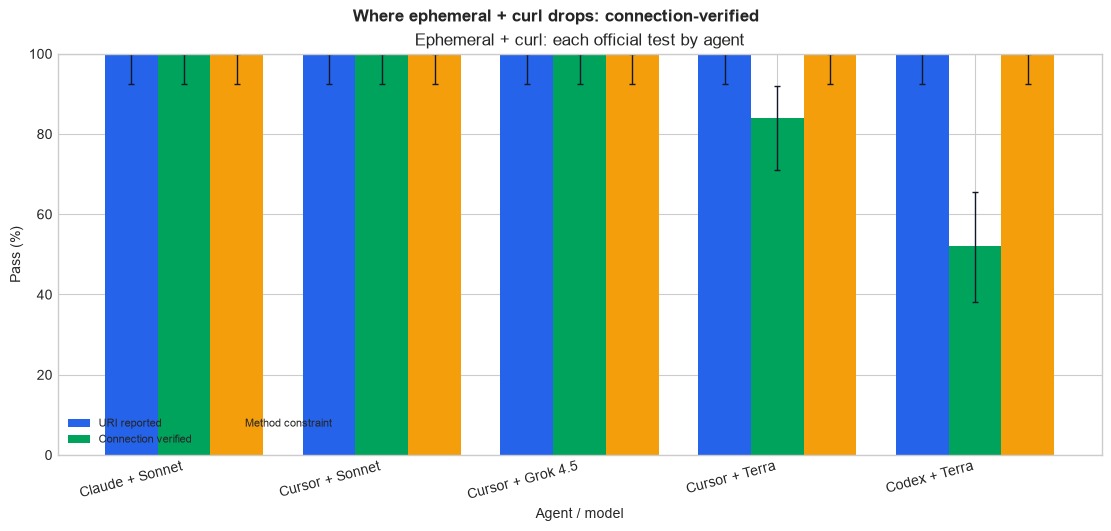

In [144]:
if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    TEST_DISPLAY = [
        ("uri-reported", "URI reported"),
        ("connection-verified-in-agent", "Connection verified"),
        ("method-constraint", "Method constraint"),
    ]
    per_test_rows = []
    for method in METHOD_ORDER:
        subset = GRADED[GRADED["method"].eq(method)]
        n = len(subset)
        for column, pretty in TEST_DISPLAY:
            k = int(subset[column].sum())
            p, lo, hi = wilson_interval(k, n)
            per_test_rows.append(
                {
                    "method": method,
                    "test": pretty,
                    "k": k,
                    "n": n,
                    "pass_rate_pct": p * 100,
                    "pass_rate_lo_pct": lo * 100,
                    "pass_rate_hi_pct": hi * 100,
                }
            )
    per_test = pd.DataFrame(per_test_rows)
    table = (
        per_test.assign(
            kn=per_test.apply(lambda r: f"{int(r.k)}/{int(r.n)}", axis=1),
            method_label=per_test["method"].map(DISPLAY_NAMES),
        )
        .pivot(index="method_label", columns="test", values="kn")
        .reindex([label_of(m) for m in METHOD_ORDER])
        .reindex(columns=[pretty for _, pretty in TEST_DISPLAY])
    )
    print("Official test pass counts (k/n) by method")
    display(table)

    fig, ax = plt.subplots(figsize=(11, 5.6), constrained_layout=True)
    grouped_bars(
        ax,
        per_test,
        "test",
        "pass_rate_pct",
        "Pass rate of each official test by method",
        "Pass (%)",
        percent=True,
        groups=[pretty for _, pretty in TEST_DISPLAY],
        lo_column="pass_rate_lo_pct",
        hi_column="pass_rate_hi_pct",
        xlabel="Provisioning method",
    )
    ax.set_ylim(0, 100)
    fig.suptitle("Three tests, not all-or-nothing (85% Wilson)", fontweight="bold")
    plt.show()

    eph = GRADED[GRADED["method"].eq("atlas-ephemeral-curl")]
    eph_rows = []
    for extension in EXTENSION_ORDER:
        subset = eph[eph["extension"].eq(extension)]
        n = len(subset)
        if n == 0:
            continue
        for column, pretty in TEST_DISPLAY:
            k = int(subset[column].sum())
            p, lo, hi = wilson_interval(k, n)
            eph_rows.append(
                {
                    "extension": extension,
                    "test": pretty,
                    "k": k,
                    "n": n,
                    "pass_rate_pct": p * 100,
                    "pass_rate_lo_pct": lo * 100,
                    "pass_rate_hi_pct": hi * 100,
                }
            )
    eph_tests = pd.DataFrame(eph_rows)
    print("Ephemeral + curl only")
    display(
        eph_tests.assign(
            kn=eph_tests.apply(lambda r: f"{int(r.k)}/{int(r.n)}", axis=1),
            extension_label=eph_tests["extension"].map(DISPLAY_NAMES),
        )
        .pivot(index="extension_label", columns="test", values="kn")
        .reindex([label_of(e) for e in EXTENSION_ORDER])
        .reindex(columns=[pretty for _, pretty in TEST_DISPLAY])
    )

    fig, ax = plt.subplots(figsize=(11, 5.2), constrained_layout=True)
    grouped_bars(
        ax,
        eph_tests,
        "test",
        "pass_rate_pct",
        "Ephemeral + curl: each official test by agent",
        "Pass (%)",
        percent=True,
        groups=[pretty for _, pretty in TEST_DISPLAY],
        lo_column="pass_rate_lo_pct",
        hi_column="pass_rate_hi_pct",
        index_col="extension",
        index_order=EXTENSION_ORDER,
        xlabel="Agent / model",
    )
    ax.set_ylim(0, 100)
    fig.suptitle("Where ephemeral + curl drops: connection-verified", fontweight="bold")
    plt.show()


**Reading (does not replace the all-or-nothing charts above).** Pooled k/3 is
**97.5%** (85% bootstrap 97.0–98.1%) versus all-three **92.5%**. No run
scored 0/3 or 1/3. Every all-or-nothing miss is **2/3**: URI reported and
method-constraint passed, `connection-verified-in-agent` failed (Docker 2,
Atlas CLI local 2, ephemeral 16, apt 17).

Method means: Docker **99.5%**, Atlas CLI local **99.5%**, ephemeral
**95.7%**, apt **95.4%**. The ~11–12pp all-or-nothing gap vs Docker
shrinks to ~4pp. Those 4pp CIs exclude 0, but they sit inside the 10pp
product MDE (defined for binary completion), so the same pairwise tests
read as practically equivalent here.

All-or-nothing stays the primary RQ1 metric: a cluster you never ping is
not a completed job. Partial credit shows the agents usually got
two-thirds of the way there.

Atlas CLI → cloud from n=5 is on the heatmap and sliced bars only:
**0/25** all-three. It is not in the pooled 97.5% figure.


## Job efficiency: success path vs failure path

RQ3 averages **successful** provisions only. Failure-path cost is a
separate estimand and is not mixed in. Primary efficiency metric is
turns; Codex is identically 1 turn on this harness, so tool calls and
dollars are the fairer agent comparison.


Successful provisioning only (RQ3 estimand)


,method_label,n,turns_mean,turns_lo,turns_hi,tools_mean,tools_lo,tools_hi,cost_mean,cost_lo,cost_hi,runtime_mean_s
0,Docker,123,2.992,2.748,3.228,3.919,3.780,4.065,0.114,0.107,0.122,46.611
1,Ephemeral + curl,109,4.064,3.541,4.615,7.422,7.055,7.807,0.203,0.189,0.217,66.597
2,Atlas CLI local,123,6.138,5.496,6.764,13.276,12.894,13.691,0.311,0.292,0.330,111.731
3,apt / packages,124,7.008,6.048,8.040,12.234,11.492,13.032,0.311,0.286,0.337,95.957


Failure-path cost (separate estimand)


,method_label,n,turns_mean,tools_mean,cost_mean,cost_lo,cost_hi,runtime_mean_s
0,Docker,2,3.5,3.0,0.143,0.136,0.150,41.006
1,Ephemeral + curl,16,1.0,4.0,0.058,0.050,0.066,46.277
2,Atlas CLI local,2,21.0,25.0,0.678,0.073,1.283,210.266
3,apt / packages,1,14.0,13.0,0.650,0.650,0.650,125.069


Success-path efficiency vs Docker (bootstrap 85% CI on mean ratio)


,method_label,metric,ratio_vs_docker,lo,hi,rel_pct,label
0,Ephemeral + curl,turns (harness-defined),1.358,1.163,1.576,35.842,Material difference
1,Ephemeral + curl,tool calls,1.894,1.781,2.019,89.400,Material difference
2,Ephemeral + curl,cost,1.772,1.611,1.953,77.191,Material difference
3,Ephemeral + curl,runtime,1.429,1.326,1.536,42.878,Material difference
4,Atlas CLI local,turns (harness-defined),2.052,1.805,2.329,105.163,Material difference
5,Atlas CLI local,tool calls,3.388,3.235,3.547,238.797,Material difference
6,Atlas CLI local,cost,2.718,2.483,2.978,171.835,Material difference
7,Atlas CLI local,runtime,2.397,2.282,2.520,139.711,Material difference
8,apt / packages,turns (harness-defined),2.342,1.984,2.754,134.237,Material difference
9,apt / packages,tool calls,3.122,2.909,3.347,212.192,Material difference


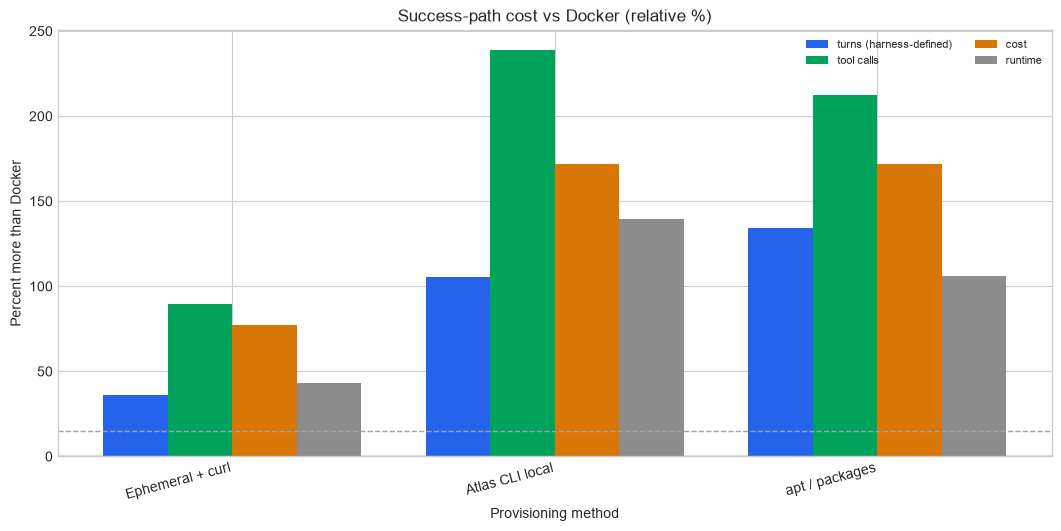

In [145]:
if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    success = GRADED.loc[GRADED["passed"]].copy()
    failure = GRADED.loc[GRADED["passed"].eq(False)].copy()
    SUCCESS, FAILURE = success, failure

    def efficiency_table(frame, label):
        rows = []
        for method in METHOD_ORDER:
            subset = frame[frame["method"].eq(method)]
            if subset.empty:
                continue
            t_mean, t_lo, t_hi = bootstrap_mean_ci(subset["num_turns"].to_numpy())
            k_mean, k_lo, k_hi = bootstrap_mean_ci(subset["tool_calls_total"].to_numpy())
            c_mean, c_lo, c_hi = bootstrap_mean_ci(subset["cost_usd"].to_numpy())
            r_mean, r_lo, r_hi = bootstrap_mean_ci(subset["runtime_s"].to_numpy())
            rows.append(
                {
                    "path": label,
                    "method": method,
                    "method_label": label_of(method),
                    "n": len(subset),
                    "turns_mean": t_mean,
                    "turns_lo": t_lo,
                    "turns_hi": t_hi,
                    "tools_mean": k_mean,
                    "tools_lo": k_lo,
                    "tools_hi": k_hi,
                    "cost_mean": c_mean,
                    "cost_lo": c_lo,
                    "cost_hi": c_hi,
                    "runtime_mean_s": r_mean,
                    "runtime_lo_s": r_lo,
                    "runtime_hi_s": r_hi,
                }
            )
        return pd.DataFrame(rows)

    SUCCESS_EFF = efficiency_table(success, "success")
    FAIL_EFF = efficiency_table(failure, "failure")
    print("Successful provisioning only (RQ3 estimand)")
    display(
        SUCCESS_EFF[
            [
                "method_label",
                "n",
                "turns_mean",
                "turns_lo",
                "turns_hi",
                "tools_mean",
                "tools_lo",
                "tools_hi",
                "cost_mean",
                "cost_lo",
                "cost_hi",
                "runtime_mean_s",
            ]
        ].round(3)
    )
    print("Failure-path cost (separate estimand)")
    if FAIL_EFF.empty:
        print("No failed graded trials.")
    else:
        display(
            FAIL_EFF[
                [
                    "method_label",
                    "n",
                    "turns_mean",
                    "tools_mean",
                    "cost_mean",
                    "cost_lo",
                    "cost_hi",
                    "runtime_mean_s",
                ]
            ].round(3)
        )

    docker_s = success[success["method"].eq("docker")]
    rel_rows = []
    for method in [m for m in METHOD_ORDER if m != "docker"]:
        other = success[success["method"].eq(method)]
        if other.empty or docker_s.empty:
            continue
        for metric, pretty in [
            ("num_turns", "turns (harness-defined)"),
            ("tool_calls_total", "tool calls"),
            ("cost_usd", "cost"),
            ("runtime_s", "runtime"),
        ]:
            ratio, lo, hi = bootstrap_ratio_ci(
                other[metric].to_numpy(), docker_s[metric].to_numpy()
            )
            rel_rows.append(
                {
                    "method_label": label_of(method),
                    "metric": pretty,
                    "ratio_vs_docker": ratio,
                    "lo": lo,
                    "hi": hi,
                    "rel_pct": (ratio - 1) * 100,
                    "label": label_rel_ratio(ratio, lo, hi),
                }
            )
    rel = pd.DataFrame(rel_rows)
    print("Success-path efficiency vs Docker (bootstrap 85% CI on mean ratio)")
    display(rel.round(3))

    fig, ax = plt.subplots(figsize=(10.5, 5.2), constrained_layout=True)
    metric_order = ["turns (harness-defined)", "tool calls", "cost", "runtime"]
    grouped_bars(
        ax,
        rel.rename(columns={"method_label": "method_disp", "metric": "metric"}),
        "metric",
        "rel_pct",
        "Success-path cost vs Docker (relative %)",
        "Percent more than Docker",
        percent=False,
        groups=metric_order,
        index_col="method_disp",
        index_order=[label_of(m) for m in METHOD_ORDER if m != "docker"],
        xlabel="Provisioning method",
    )
    ax.axhline(0, color="#6B7280", linewidth=1)
    ax.axhline(MDE_REL * 100, color="#9CA3AF", linestyle="--", linewidth=1)
    plt.show()


## Efficiency distributions

Box + strip plots on the success path, then failure-path cost so the
expensive misses are visible without polluting RQ3 averages.


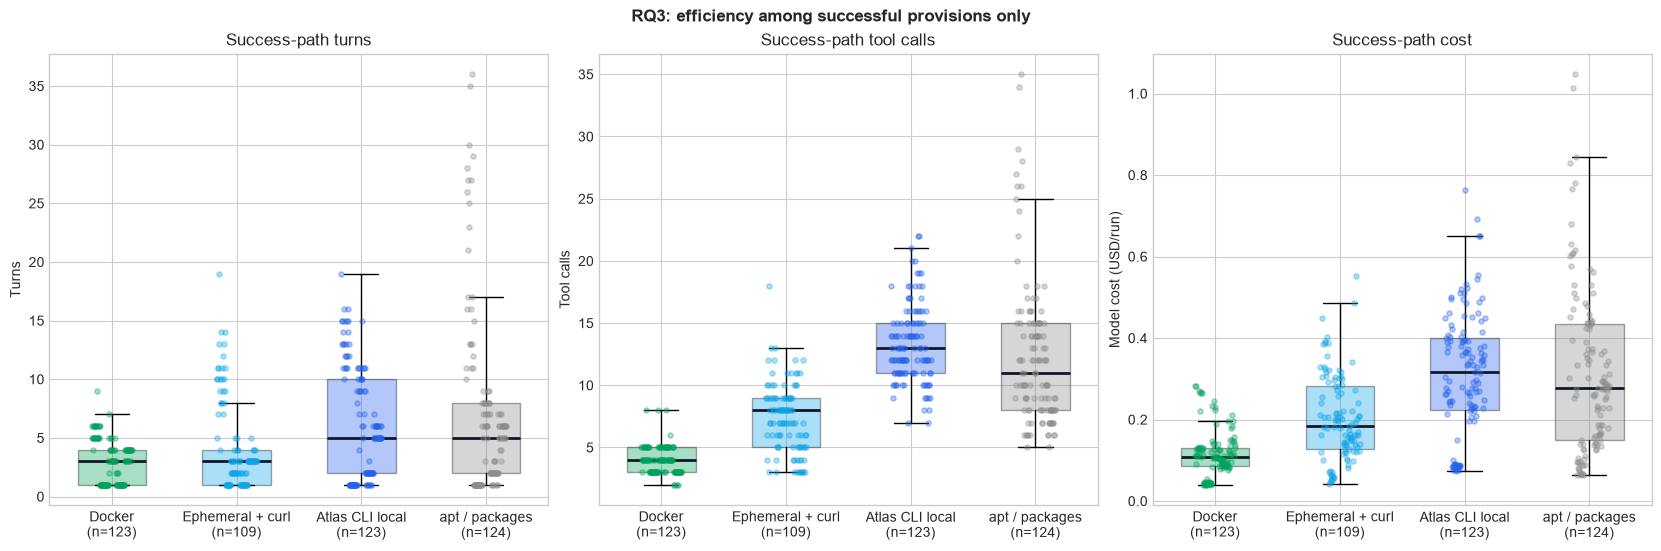

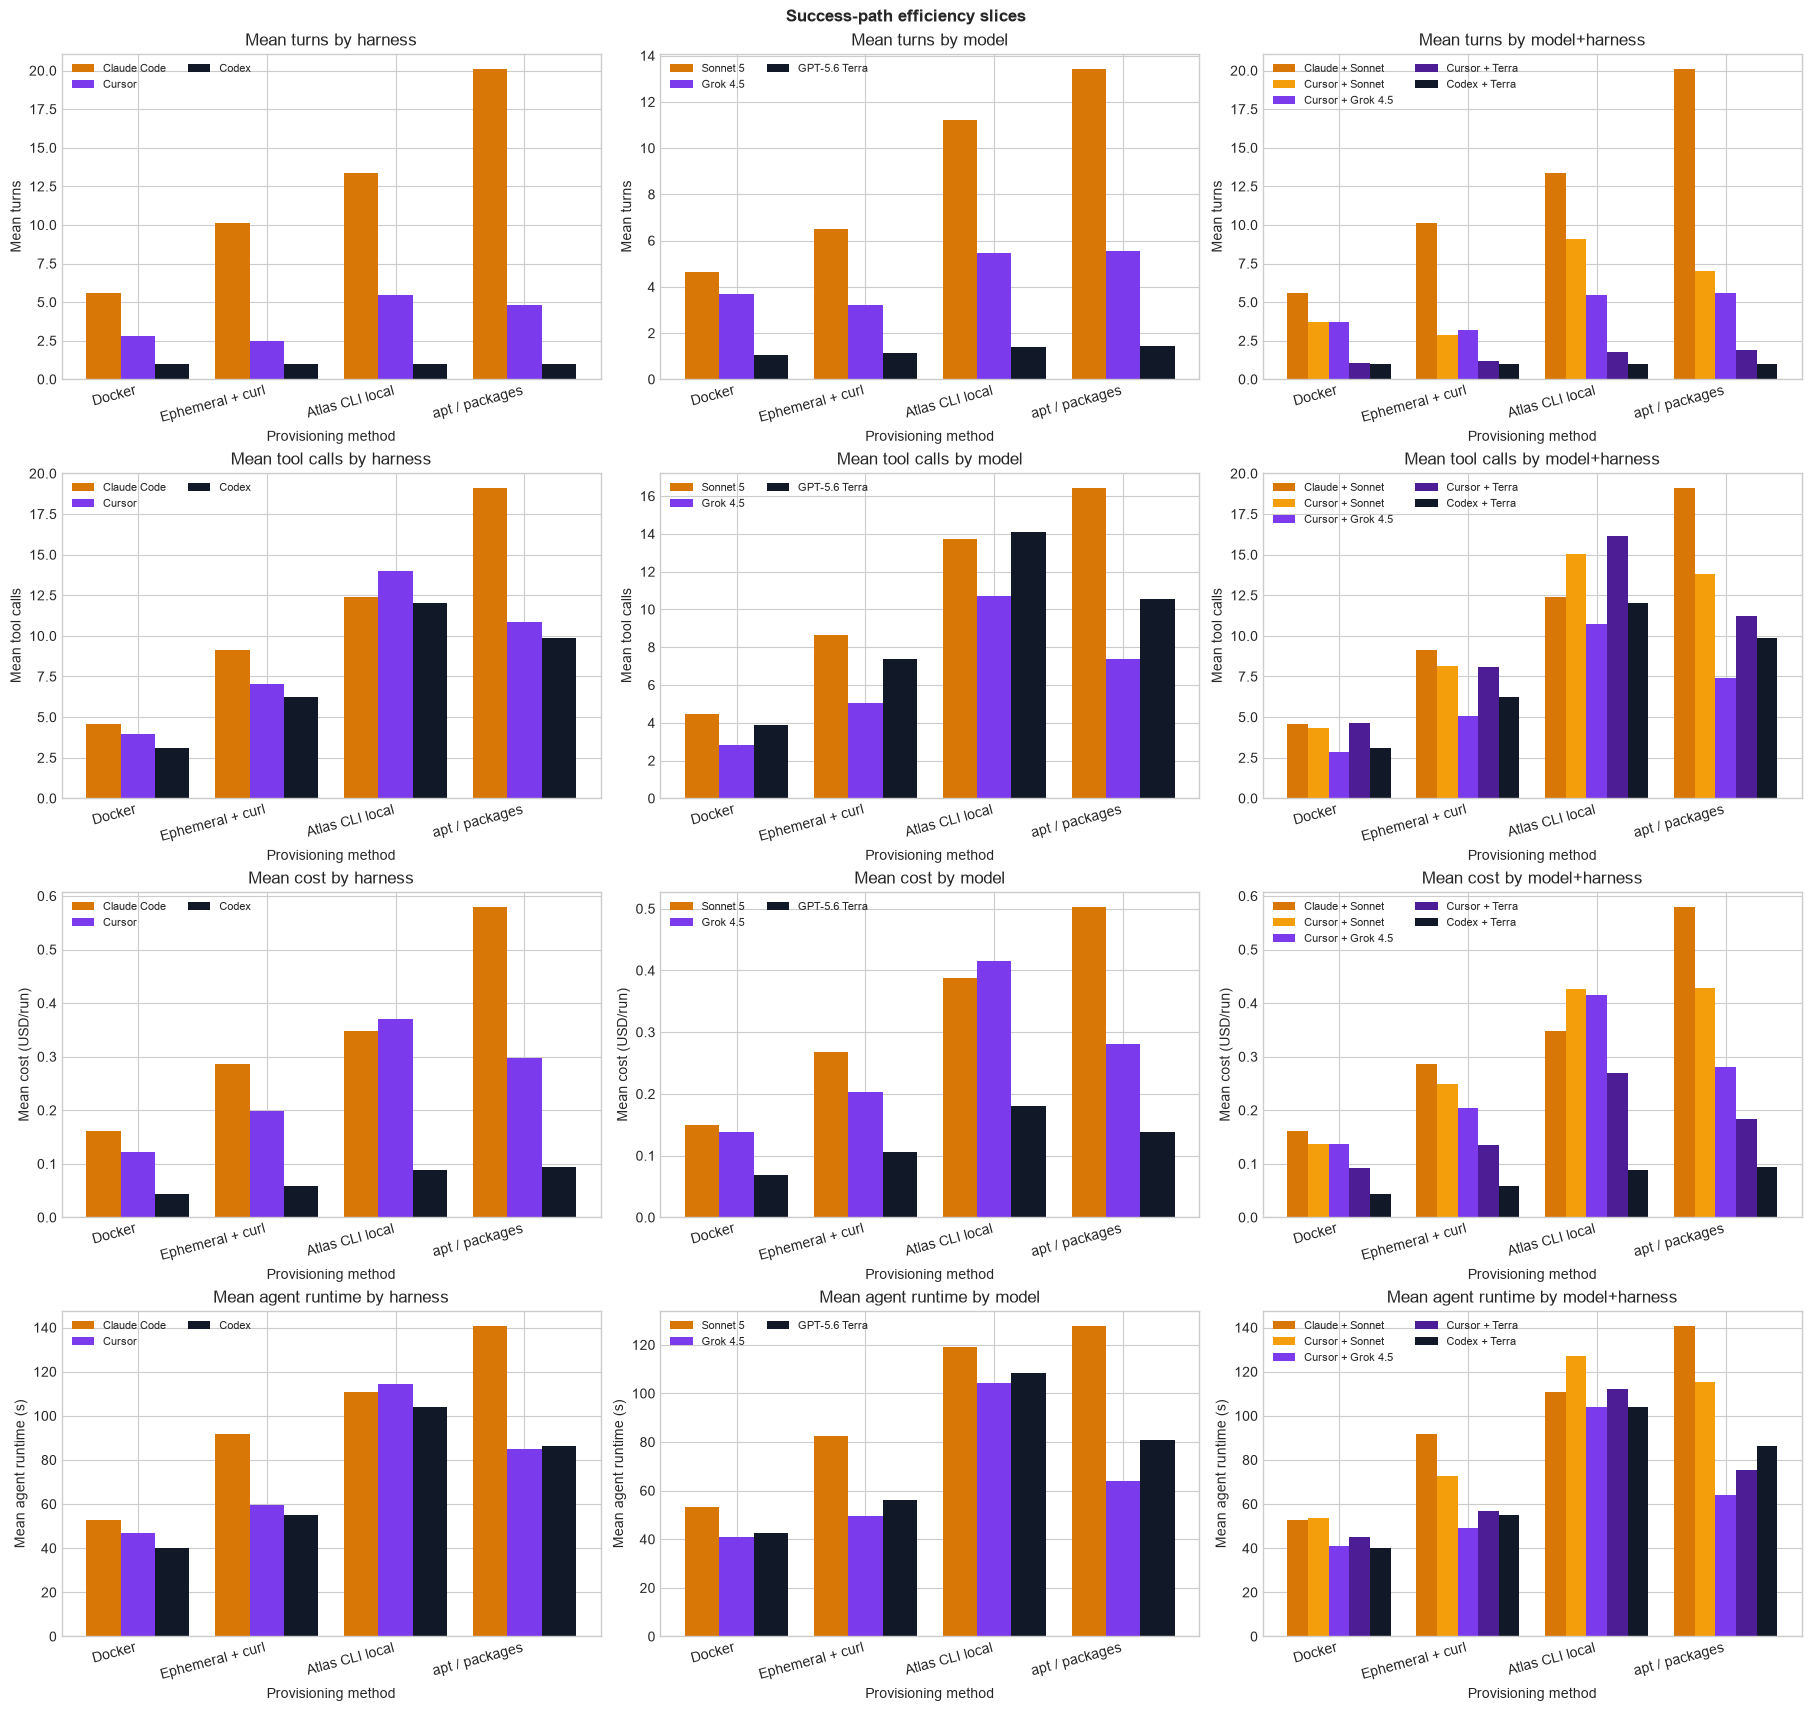

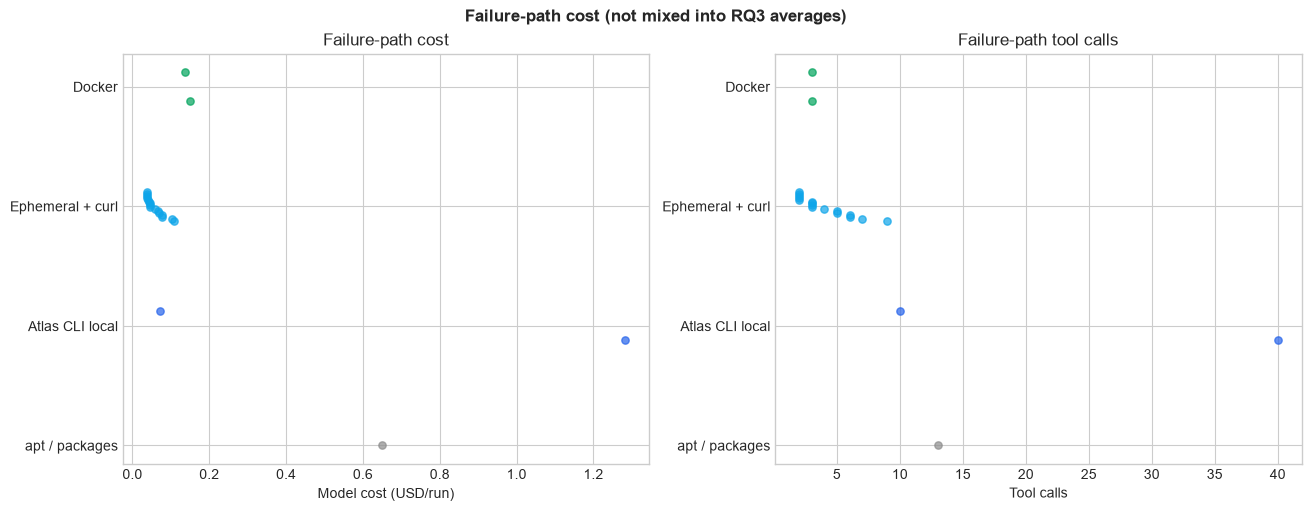

In [146]:
if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    success_methods = [m for m in METHOD_ORDER if m in set(SUCCESS["method"])]
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.4), constrained_layout=True)
    for ax, metric, ylabel, title in [
        (axes[0], "num_turns", "Turns", "Success-path turns"),
        (axes[1], "tool_calls_total", "Tool calls", "Success-path tool calls"),
        (axes[2], "cost_usd", "Model cost (USD/run)", "Success-path cost"),
    ]:
        distributions = [
            SUCCESS.loc[SUCCESS["method"].eq(method), metric].dropna().to_numpy(dtype=float)
            for method in success_methods
        ]
        positions = np.arange(1, len(success_methods) + 1)
        boxes = ax.boxplot(
            distributions,
            positions=positions,
            widths=0.55,
            patch_artist=True,
            showfliers=False,
            medianprops={"color": "#111827", "linewidth": 2},
        )
        for patch, method in zip(boxes["boxes"], success_methods):
            patch.set_facecolor(COLORS[method])
            patch.set_alpha(0.35)
        for position, method, values in zip(positions, success_methods, distributions):
            jitter = np.linspace(-0.16, 0.16, len(values)) if len(values) > 1 else np.array([0.0])
            ax.scatter(position + jitter, values, color=COLORS[method], alpha=0.35, s=14, zorder=3)
        ax.set_xticks(
            positions,
            [f"{label_of(m)}\n(n={len(v)})" for m, v in zip(success_methods, distributions)],
        )
        ax.set_ylabel(ylabel)
        ax.set_title(title)
    fig.suptitle("RQ3: efficiency among successful provisions only", fontweight="bold")
    plt.show()

    by_h = (
        SUCCESS.groupby(["agent", "method"], observed=True)[
            ["runtime_s", "cost_usd", "num_turns", "tool_calls_total"]
        ]
        .mean()
        .reset_index()
        .rename(
            columns={
                "agent": "harness",
                "runtime_s": "runtime_mean",
                "cost_usd": "cost_mean",
                "num_turns": "turns_mean",
                "tool_calls_total": "tools_mean",
            }
        )
    )
    by_m = (
        SUCCESS.groupby(["model", "method"], observed=True)[
            ["runtime_s", "cost_usd", "num_turns", "tool_calls_total"]
        ]
        .mean()
        .reset_index()
        .rename(
            columns={
                "runtime_s": "runtime_mean",
                "cost_usd": "cost_mean",
                "num_turns": "turns_mean",
                "tool_calls_total": "tools_mean",
            }
        )
    )
    by_e = (
        SUCCESS.groupby(["extension", "method"], observed=True)[
            ["runtime_s", "cost_usd", "num_turns", "tool_calls_total"]
        ]
        .mean()
        .reset_index()
        .rename(
            columns={
                "runtime_s": "runtime_mean",
                "cost_usd": "cost_mean",
                "num_turns": "turns_mean",
                "tool_calls_total": "tools_mean",
            }
        )
    )
    metrics = [
        ("turns_mean", "Mean turns"),
        ("tools_mean", "Mean tool calls"),
        ("cost_mean", "Mean cost (USD/run)"),
        ("runtime_mean", "Mean agent runtime (s)"),
    ]
    fig, axes = plt.subplots(4, 3, figsize=(18, 17), constrained_layout=True)
    slices = [
        (by_h, "harness", HARNESS_ORDER, "harness"),
        (by_m, "model", MODEL_ORDER, "model"),
        (by_e, "extension", EXTENSION_ORDER, "model+harness"),
    ]
    for row, (metric, ylabel) in enumerate(metrics):
        for col, (frame, group, groups, slice_name) in enumerate(slices):
            grouped_bars(
                axes[row, col],
                frame,
                group,
                metric,
                f"{ylabel.split('(')[0].strip()} by {slice_name}",
                ylabel,
                groups=groups,
            )
    fig.suptitle("Success-path efficiency slices", fontweight="bold")
    plt.show()

    if not FAILURE.empty:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
        fail_methods = [m for m in METHOD_ORDER if m in set(FAILURE["method"])]
        y = np.arange(len(fail_methods))
        for ax, metric, xlabel, title in [
            (axes[0], "cost_usd", "Model cost (USD/run)", "Failure-path cost"),
            (axes[1], "tool_calls_total", "Tool calls", "Failure-path tool calls"),
        ]:
            for yi, method in enumerate(fail_methods):
                subset = FAILURE[FAILURE["method"].eq(method)].sort_values(metric)
                jitter = np.linspace(-0.12, 0.12, len(subset)) if len(subset) > 1 else np.array([0.0])
                ax.scatter(subset[metric], yi + jitter, color=COLORS[method], alpha=0.7, s=28)
            ax.set_yticks(y, [label_of(m) for m in fail_methods])
            ax.invert_yaxis()
            ax.set_xlabel(xlabel)
            ax.set_title(title)
        fig.suptitle("Failure-path cost (not mixed into RQ3 averages)", fontweight="bold")
        plt.show()


## Efficiency distributions (all graded runs)

Same charts as the success-path cell above, but on **every graded run**
(pass and fail). This is not the RQ3 estimand — failures pull apt and
ephemeral means up. Use it to see total agent cost, not “cost given a
working database.”

**Atlas CLI → cloud** is overlaid from the n=5 run (**0/25** all-three;
not repeated at scale). That series is failure-path cost: agents
grinding on the Atlas login wall. It is not mixed into the success-path
RQ3 charts above.

The table at the top of the next cell includes Atlas CLI cloud (`n=25`
pooled, 5 per extension). Then the boxplots and slices.


All-runs efficiency by method — Atlas CLI cloud is n=5 (0/25 all-three; failure-path cost, not repeated at scale)


,method_label,n,all_three,turns_mean,tools_mean,cost_mean,runtime_mean
0,Docker,125,123,3.00,3.90,0.11,46.52
1,Ephemeral + curl,125,109,3.67,6.98,0.18,64.00
2,Atlas CLI local,125,123,6.38,13.46,0.32,113.31
3,apt / packages,125,124,7.06,12.24,0.31,96.19
4,Atlas CLI cloud (n=5),25,0,4.56,15.84,0.58,194.62


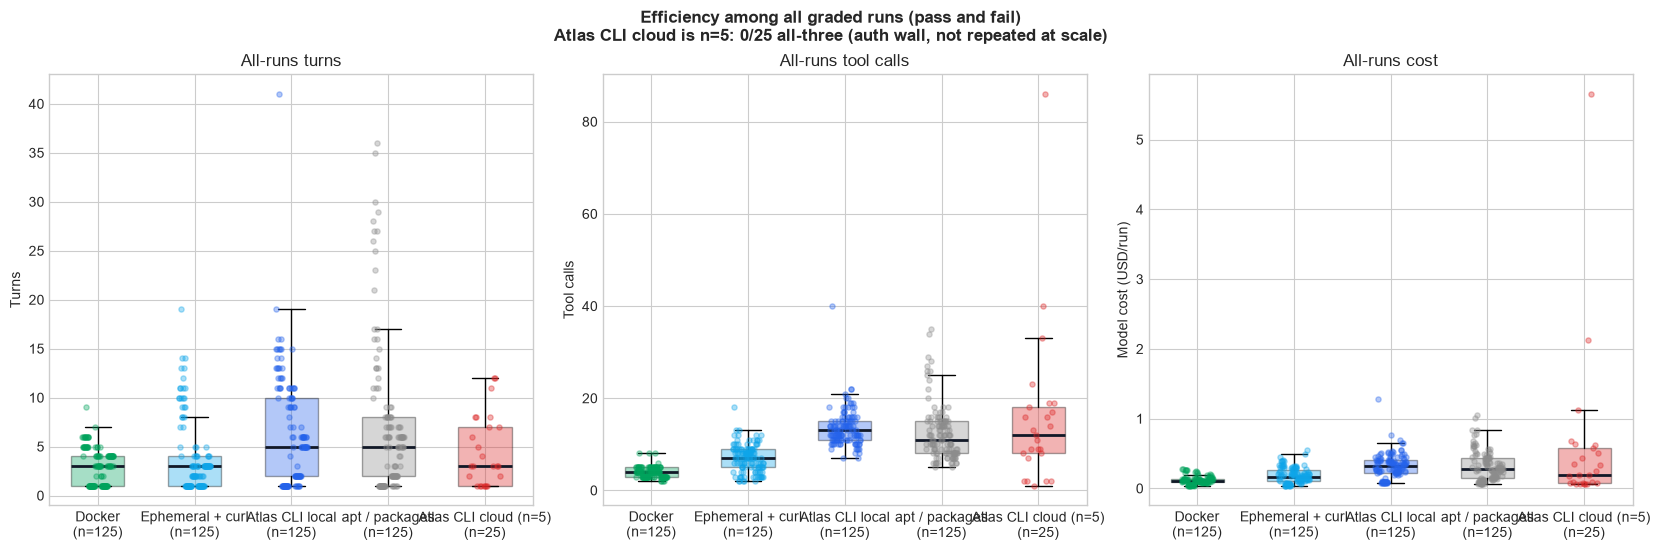

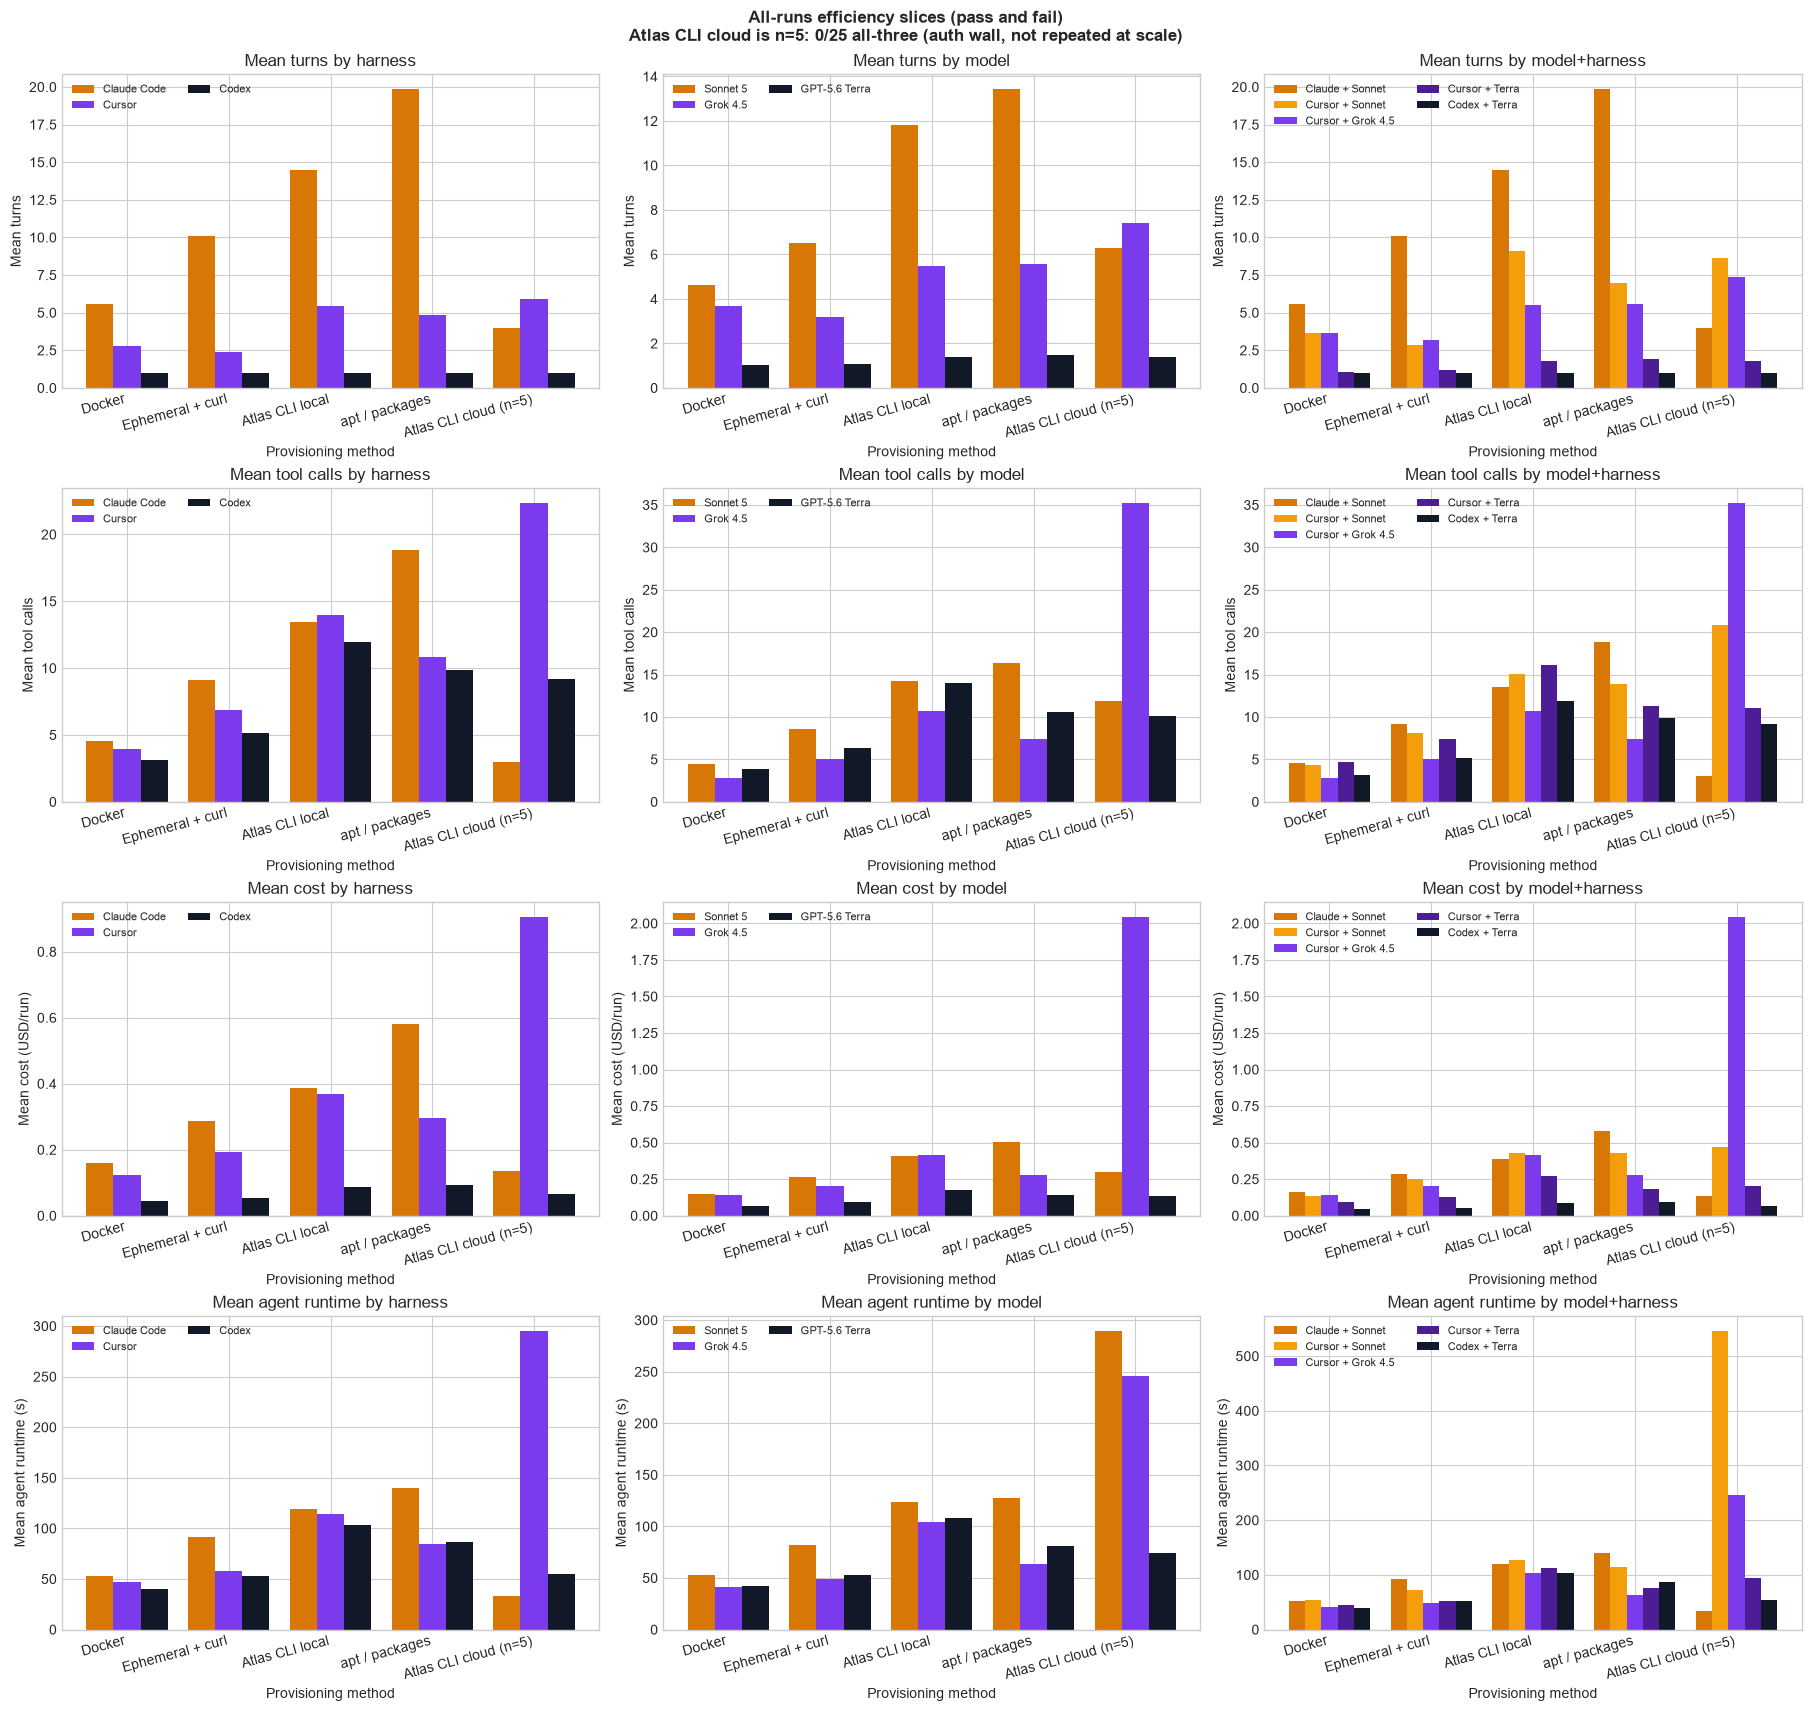

In [147]:
if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    overlay = GRADED_WITH_AUTH if not GRADED_WITH_AUTH.empty else GRADED
    all_methods = [m for m in METHOD_ORDER_WITH_AUTH if m in set(overlay["method"])]
    print(
        "All-runs efficiency by method — Atlas CLI cloud is n=5 "
        "(0/25 all-three; failure-path cost, not repeated at scale)"
    )
    eff_table = (
        overlay.groupby("method", observed=True)
        .agg(
            n=("run_id", "size"),
            all_three=("passed", "sum"),
            turns_mean=("num_turns", "mean"),
            tools_mean=("tool_calls_total", "mean"),
            cost_mean=("cost_usd", "mean"),
            runtime_mean=("runtime_s", "mean"),
        )
        .reindex(all_methods)
        .reset_index()
    )
    display(
        eff_table.assign(method_label=eff_table["method"].map(DISPLAY_NAMES))[
            [
                "method_label",
                "n",
                "all_three",
                "turns_mean",
                "tools_mean",
                "cost_mean",
                "runtime_mean",
            ]
        ].round(2)
    )
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.4), constrained_layout=True)
    for ax, metric, ylabel, title in [
        (axes[0], "num_turns", "Turns", "All-runs turns"),
        (axes[1], "tool_calls_total", "Tool calls", "All-runs tool calls"),
        (axes[2], "cost_usd", "Model cost (USD/run)", "All-runs cost"),
    ]:
        distributions = [
            overlay.loc[overlay["method"].eq(method), metric].dropna().to_numpy(dtype=float)
            for method in all_methods
        ]
        positions = np.arange(1, len(all_methods) + 1)
        boxes = ax.boxplot(
            distributions,
            positions=positions,
            widths=0.55,
            patch_artist=True,
            showfliers=False,
            medianprops={"color": "#111827", "linewidth": 2},
        )
        for patch, method in zip(boxes["boxes"], all_methods):
            patch.set_facecolor(COLORS[method])
            patch.set_alpha(0.35)
        for position, method, values in zip(positions, all_methods, distributions):
            jitter = np.linspace(-0.16, 0.16, len(values)) if len(values) > 1 else np.array([0.0])
            ax.scatter(position + jitter, values, color=COLORS[method], alpha=0.35, s=14, zorder=3)
        ax.set_xticks(
            positions,
            [f"{label_of(m)}\n(n={len(v)})" for m, v in zip(all_methods, distributions)],
        )
        ax.set_ylabel(ylabel)
        ax.set_title(title)
    fig.suptitle(
        "Efficiency among all graded runs (pass and fail)\n"
        "Atlas CLI cloud is n=5: 0/25 all-three (auth wall, not repeated at scale)",
        fontweight="bold",
    )
    plt.show()

    by_h = (
        overlay.groupby(["agent", "method"], observed=True)[
            ["runtime_s", "cost_usd", "num_turns", "tool_calls_total"]
        ]
        .mean()
        .reset_index()
        .rename(
            columns={
                "agent": "harness",
                "runtime_s": "runtime_mean",
                "cost_usd": "cost_mean",
                "num_turns": "turns_mean",
                "tool_calls_total": "tools_mean",
            }
        )
    )
    by_m = (
        overlay.groupby(["model", "method"], observed=True)[
            ["runtime_s", "cost_usd", "num_turns", "tool_calls_total"]
        ]
        .mean()
        .reset_index()
        .rename(
            columns={
                "runtime_s": "runtime_mean",
                "cost_usd": "cost_mean",
                "num_turns": "turns_mean",
                "tool_calls_total": "tools_mean",
            }
        )
    )
    by_e = (
        overlay.groupby(["extension", "method"], observed=True)[
            ["runtime_s", "cost_usd", "num_turns", "tool_calls_total"]
        ]
        .mean()
        .reset_index()
        .rename(
            columns={
                "runtime_s": "runtime_mean",
                "cost_usd": "cost_mean",
                "num_turns": "turns_mean",
                "tool_calls_total": "tools_mean",
            }
        )
    )
    metrics = [
        ("turns_mean", "Mean turns"),
        ("tools_mean", "Mean tool calls"),
        ("cost_mean", "Mean cost (USD/run)"),
        ("runtime_mean", "Mean agent runtime (s)"),
    ]
    fig, axes = plt.subplots(4, 3, figsize=(18, 17), constrained_layout=True)
    slices = [
        (by_h, "harness", HARNESS_ORDER, "harness"),
        (by_m, "model", MODEL_ORDER, "model"),
        (by_e, "extension", EXTENSION_ORDER, "model+harness"),
    ]
    for row, (metric, ylabel) in enumerate(metrics):
        for col, (frame, group, groups, slice_name) in enumerate(slices):
            grouped_bars(
                axes[row, col],
                frame,
                group,
                metric,
                f"{ylabel.split('(')[0].strip()} by {slice_name}",
                ylabel,
                groups=groups,
                index_order=all_methods,
            )
    fig.suptitle(
        "All-runs efficiency slices (pass and fail)\n"
        "Atlas CLI cloud is n=5: 0/25 all-three (auth wall, not repeated at scale)",
        fontweight="bold",
    )
    plt.show()


## Turns in detail

Codex's harness reports one turn even when the job is many tool calls.
The left panel is the platform turn count; the right panel is tool
calls, which is the comparable step metric.


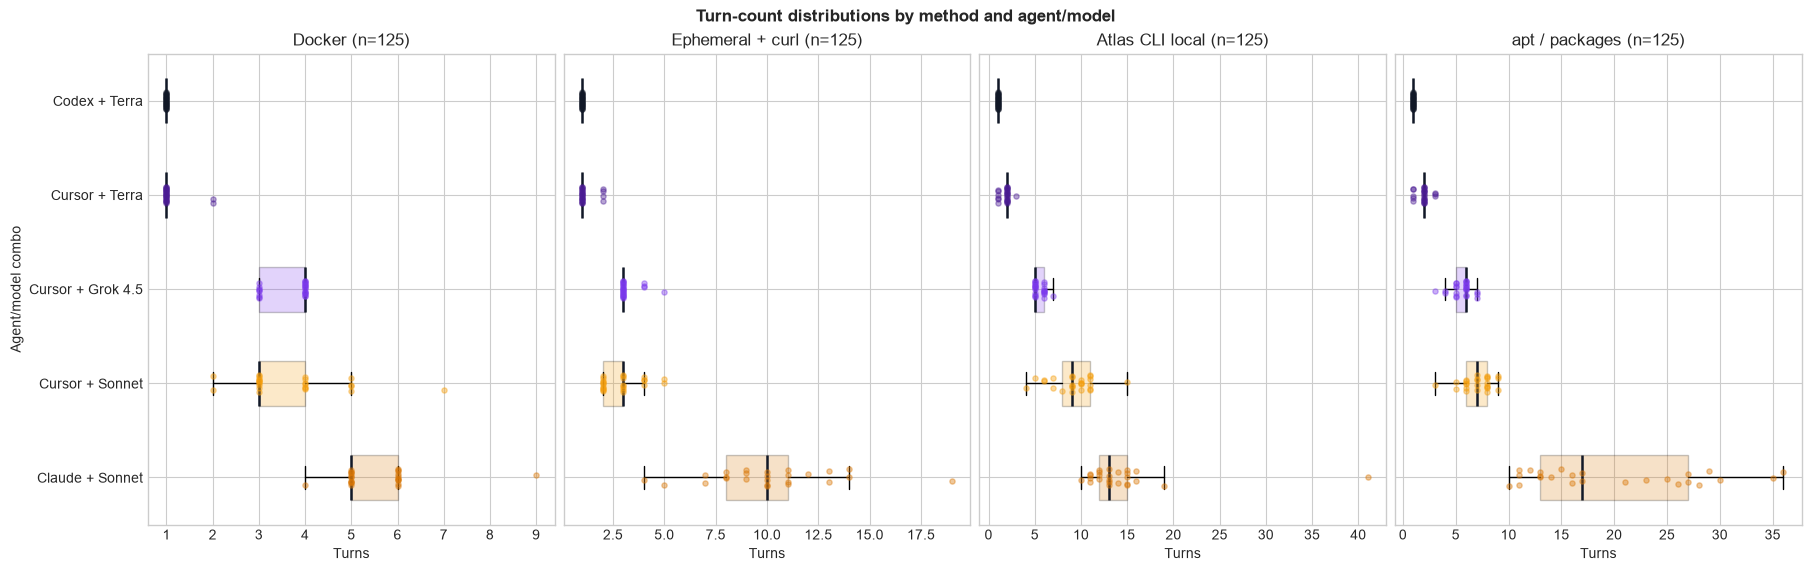

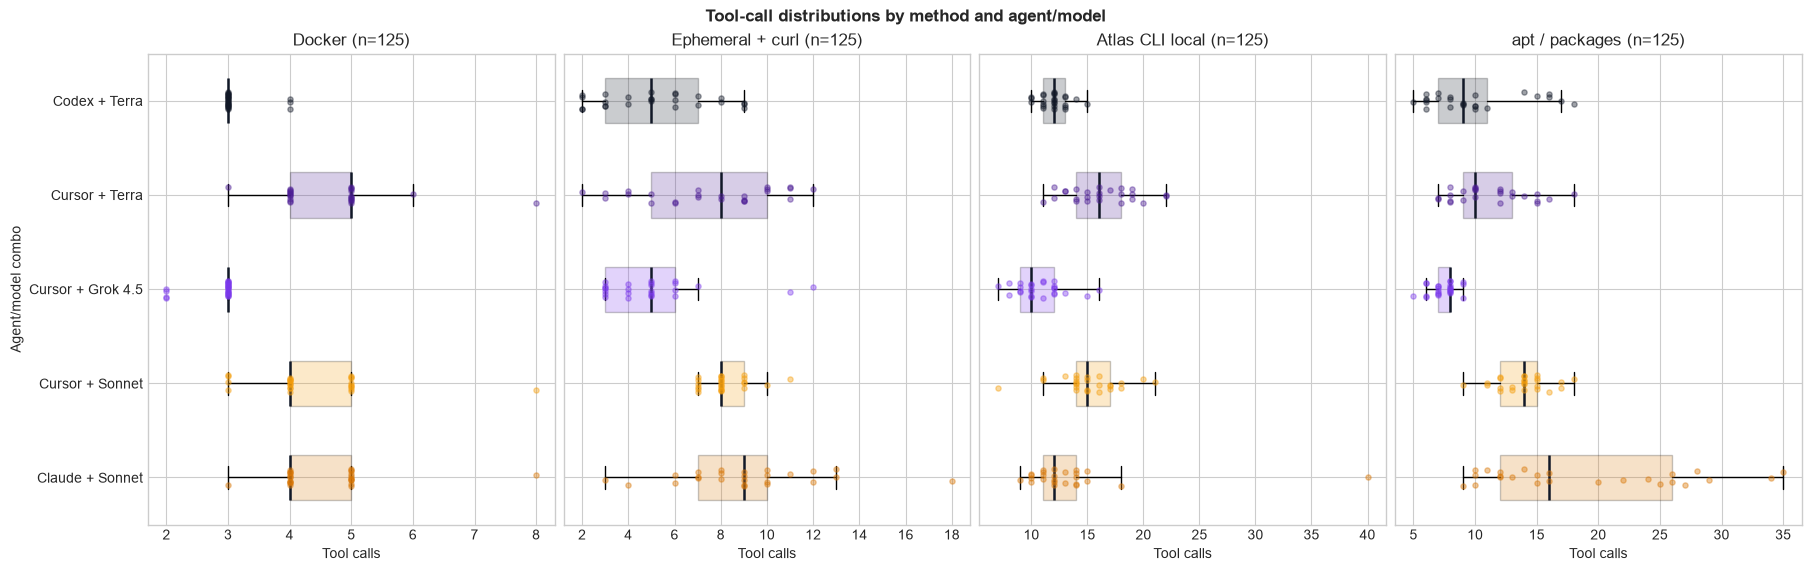

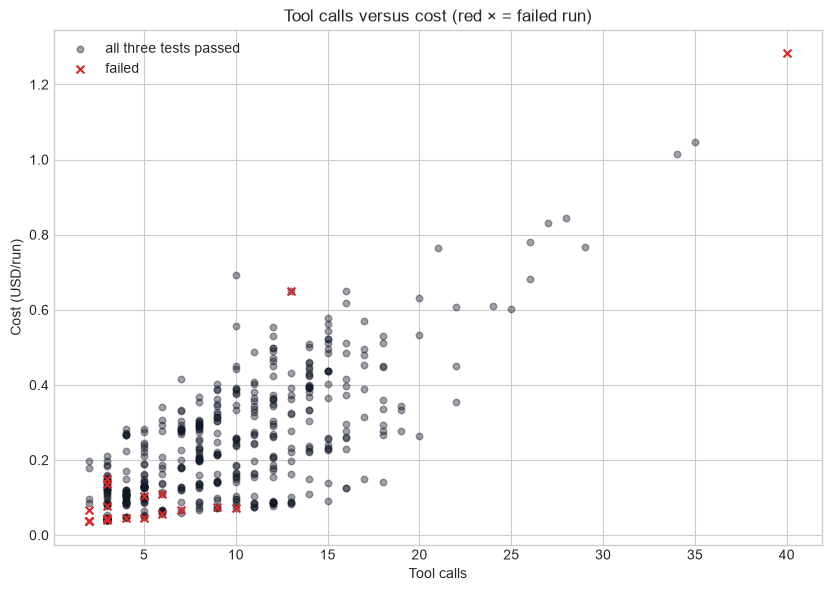

Turns by extension on graded rows (Codex is typically 1):


,min,median,mean,max
extension,,,,
Claude + Sonnet,4,11.0,12.50,41
Cursor + Sonnet,2,5.0,5.67,15
Cursor + Grok 4.5,3,4.0,4.48,7
Cursor + Terra,1,1.0,1.49,3
Codex + Terra,1,1.0,1.00,1


In [148]:
if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    present_extensions = [name for name in EXTENSION_ORDER if name in set(GRADED["extension"])]
    y_positions = np.arange(len(present_extensions))

    fig, axes = plt.subplots(1, 4, figsize=(18, 5.6), sharey=True, constrained_layout=True)
    for ax, method in zip(axes, METHOD_ORDER):
        method_runs = GRADED[GRADED["method"] == method]
        distributions, positions = [], []
        for y_position, extension in zip(y_positions, present_extensions):
            values = (
                method_runs.loc[method_runs["extension"] == extension, "num_turns"]
                .dropna()
                .to_numpy(dtype=float)
            )
            if not len(values):
                continue
            distributions.append(values)
            positions.append(y_position)
            jitter = np.linspace(-0.09, 0.09, len(values)) if len(values) > 1 else np.array([0.0])
            ax.scatter(
                values,
                y_position + jitter,
                color=COLORS.get(extension, "#6B7280"),
                alpha=0.4,
                s=14,
                zorder=3,
            )
        if distributions:
            boxes = ax.boxplot(
                distributions,
                positions=positions,
                orientation="horizontal",
                widths=0.48,
                patch_artist=True,
                showfliers=False,
                medianprops={"color": "#111827", "linewidth": 1.8},
            )
            for patch, position in zip(boxes["boxes"], positions):
                patch.set_facecolor(COLORS.get(present_extensions[position], "#9CA3AF"))
                patch.set_alpha(0.22)
        ax.set_title(f"{label_of(method)} (n={len(method_runs)})")
        ax.set_xlabel("Turns")
        ax.set_yticks(y_positions, [label_of(name) for name in present_extensions])
        ax.invert_yaxis()
    axes[0].set_ylabel("Agent/model combo")
    fig.suptitle("Turn-count distributions by method and agent/model", fontweight="bold")
    plt.show()

    fig, axes = plt.subplots(1, 4, figsize=(18, 5.6), sharey=True, constrained_layout=True)
    for ax, method in zip(axes, METHOD_ORDER):
        method_runs = GRADED[GRADED["method"] == method]
        distributions, positions = [], []
        for y_position, extension in zip(y_positions, present_extensions):
            values = (
                method_runs.loc[method_runs["extension"] == extension, "tool_calls_total"]
                .dropna()
                .to_numpy(dtype=float)
            )
            if not len(values):
                continue
            distributions.append(values)
            positions.append(y_position)
            jitter = np.linspace(-0.09, 0.09, len(values)) if len(values) > 1 else np.array([0.0])
            ax.scatter(
                values,
                y_position + jitter,
                color=COLORS.get(extension, "#6B7280"),
                alpha=0.4,
                s=14,
                zorder=3,
            )
        if distributions:
            boxes = ax.boxplot(
                distributions,
                positions=positions,
                orientation="horizontal",
                widths=0.48,
                patch_artist=True,
                showfliers=False,
                medianprops={"color": "#111827", "linewidth": 1.8},
            )
            for patch, position in zip(boxes["boxes"], positions):
                patch.set_facecolor(COLORS.get(present_extensions[position], "#9CA3AF"))
                patch.set_alpha(0.22)
        ax.set_title(f"{label_of(method)} (n={len(method_runs)})")
        ax.set_xlabel("Tool calls")
        ax.set_yticks(y_positions, [label_of(name) for name in present_extensions])
        ax.invert_yaxis()
    axes[0].set_ylabel("Agent/model combo")
    fig.suptitle("Tool-call distributions by method and agent/model", fontweight="bold")
    plt.show()

    fig, ax = plt.subplots(figsize=(8.2, 5.8), constrained_layout=True)
    passed = GRADED["passed"].to_numpy(dtype=bool)
    ax.scatter(
        GRADED.loc[passed, "tool_calls_total"],
        GRADED.loc[passed, "cost_usd"],
        color="#111827",
        alpha=0.4,
        s=22,
        label="all three tests passed",
    )
    ax.scatter(
        GRADED.loc[~passed, "tool_calls_total"],
        GRADED.loc[~passed, "cost_usd"],
        color="#DC2626",
        marker="x",
        s=32,
        label="failed",
    )
    ax.set_xlabel("Tool calls")
    ax.set_ylabel("Cost (USD/run)")
    ax.set_title("Tool calls versus cost (red × = failed run)")
    ax.legend(frameon=False)
    plt.show()

    print("Turns by extension on graded rows (Codex is typically 1):")
    display(
        GRADED.groupby("extension", observed=True)["num_turns"]
        .agg(["min", "median", "mean", "max"])
        .reindex(EXTENSION_ORDER)
        .round(2)
        .rename(index=label_of)
    )


## Compound completion and efficiency: Pareto frontier

Left: one point per method (pooled). Right: one line per method, points
are agent/model combos — the design's agent-experience chart. X-axis is
success-path tool calls (turns are harness-noisy for Codex). Y-axis is
all-three-tests pass rate.


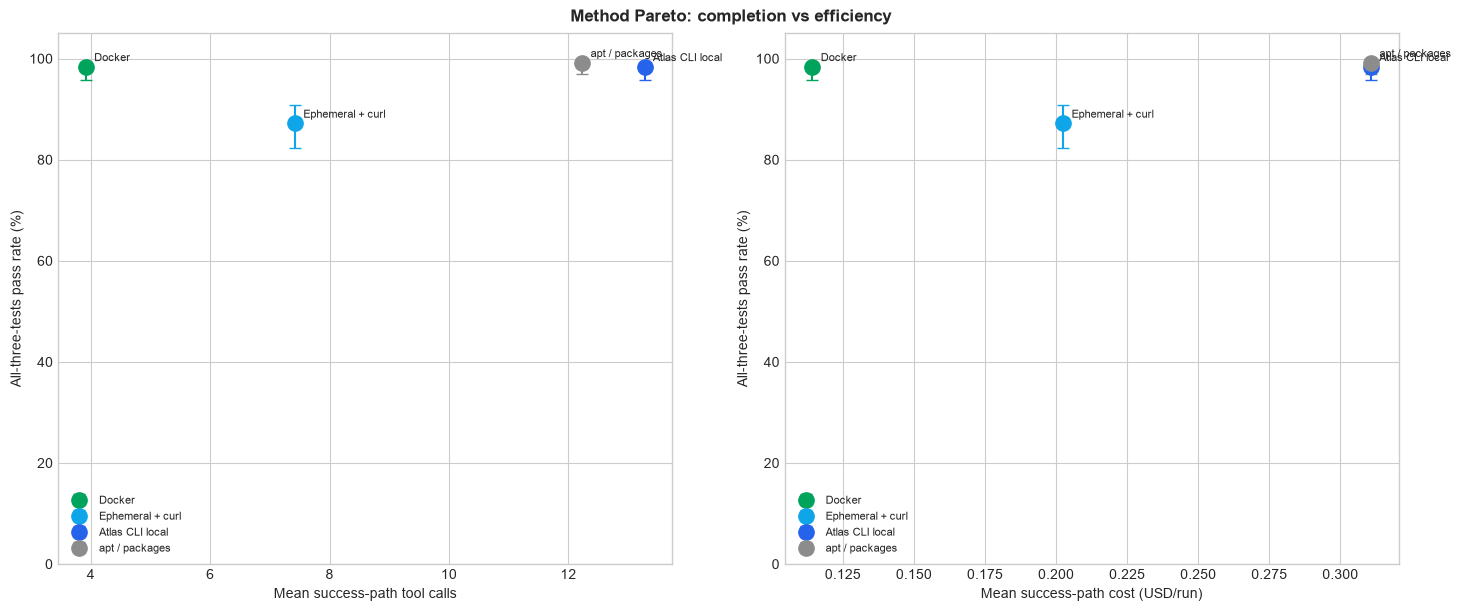

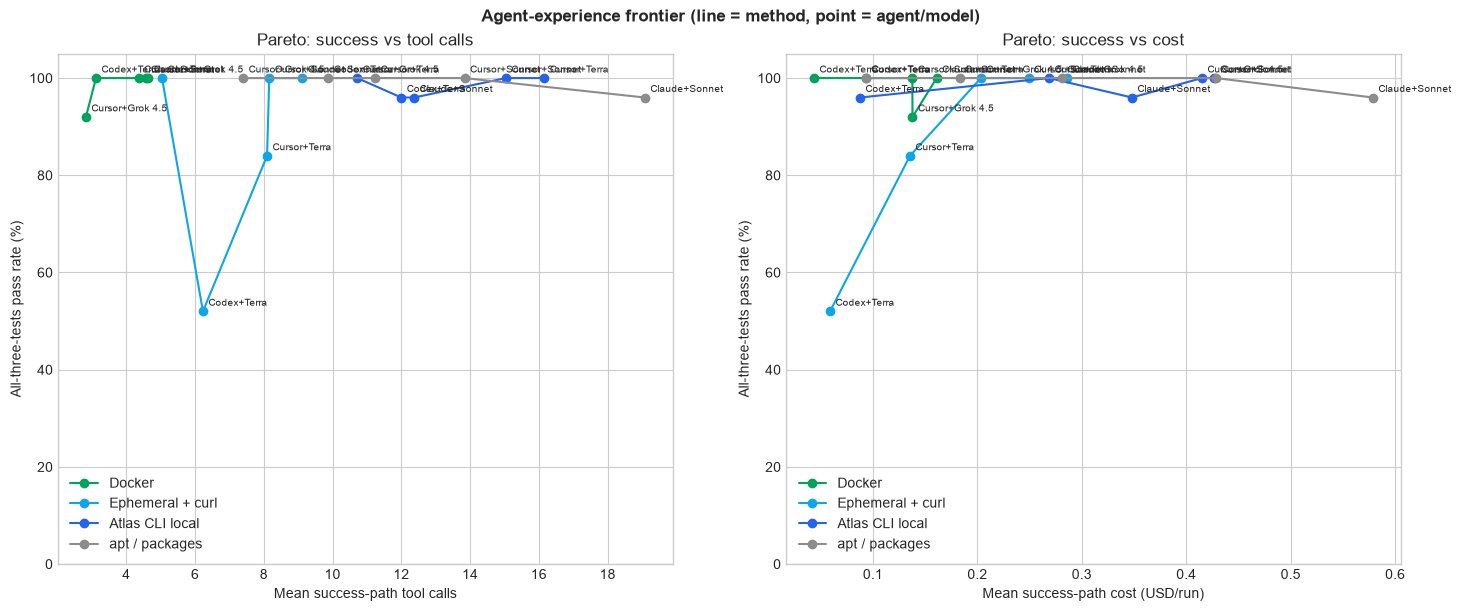

In [149]:
if not READY_GRADED or method_summary.empty:
    print("Waiting for graded runs.")
else:
    cell_summary = (
        GRADED.groupby(["extension", "method"], observed=True)
        .agg(
            runs=("run_id", "size"),
            passed=("passed", "sum"),
        )
        .reset_index()
    )
    add_wilson_columns(cell_summary, "passed", "runs")
    succ_cell = (
        SUCCESS.groupby(["extension", "method"], observed=True)
        .agg(
            tools_mean=("tool_calls_total", "mean"),
            cost_mean=("cost_usd", "mean"),
            turns_mean=("num_turns", "mean"),
            runtime_mean_s=("runtime_s", "mean"),
        )
        .reset_index()
    )
    cell_summary = cell_summary.merge(succ_cell, on=["extension", "method"], how="left")

    fig, axes = plt.subplots(1, 2, figsize=(14.5, 6), constrained_layout=True)
    fig.suptitle("Method Pareto: completion vs efficiency", fontweight="bold")
    rates = method_summary.set_index("method")
    for ax, x_col, xlabel in [
        (axes[0], "tools_mean", "Mean success-path tool calls"),
        (axes[1], "cost_mean", "Mean success-path cost (USD/run)"),
    ]:
        for method in METHOD_ORDER:
            if method not in rates.index or pd.isna(rates.loc[method, "runs"]):
                continue
            rate_row = rates.loc[method]
            y_rate = float(rate_row.pass_rate) * 100
            yerr = np.clip(
                np.array(
                    [
                        [y_rate - float(rate_row.pass_rate_lo) * 100],
                        [float(rate_row.pass_rate_hi) * 100 - y_rate],
                    ]
                ),
                0,
                None,
            )
            if pd.isna(y_rate):
                continue
            if rate_row.all_tests_passed > 0:
                x = float(SUCCESS_EFF.set_index("method").loc[method, x_col])
                marker = "o"
            else:
                if FAIL_EFF.empty or method not in set(FAIL_EFF["method"]):
                    continue
                x = float(FAIL_EFF.set_index("method").loc[method, x_col])
                marker = "X"
            ax.errorbar(
                x,
                y_rate,
                yerr=yerr,
                fmt=marker,
                color=COLORS[method],
                markerfacecolor=COLORS[method] if marker == "o" else "white",
                markeredgecolor=COLORS[method],
                markersize=11,
                capsize=4,
                label=label_of(method),
            )
            ax.annotate(label_of(method), (x, y_rate), fontsize=8, xytext=(6, 4), textcoords="offset points")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("All-three-tests pass rate (%)")
        ax.set_ylim(0, 105)
        ax.legend(frameon=False, fontsize=8)
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14.5, 6), constrained_layout=True)
    fig.suptitle("Agent-experience frontier (line = method, point = agent/model)", fontweight="bold")

    def pareto(ax, x_column, xlabel, title):
        for method in METHOD_ORDER:
            subset = cell_summary[cell_summary["method"] == method].dropna(subset=[x_column]).sort_values(x_column)
            if subset.empty:
                continue
            ax.plot(
                subset[x_column],
                subset["pass_rate_pct"],
                marker="o",
                color=COLORS[method],
                label=label_of(method),
            )
            for _, row in subset.iterrows():
                ax.annotate(
                    label_of(row["extension"]).replace(" + ", "+"),
                    (row[x_column], row["pass_rate_pct"]),
                    fontsize=7,
                    xytext=(4, 4),
                    textcoords="offset points",
                )
        ax.set_xlabel(xlabel)
        ax.set_ylabel("All-three-tests pass rate (%)")
        ax.set_ylim(0, 105)
        ax.set_title(title)
        ax.legend(frameon=False)

    pareto(axes[0], "tools_mean", "Mean success-path tool calls", "Pareto: success vs tool calls")
    pareto(axes[1], "cost_mean", "Mean success-path cost (USD/run)", "Pareto: success vs cost")
    plt.show()


## Recipe-following (boolean tool evidence)

Counts of tool-call payloads that mention Docker, the ephemeral API,
`atlas deployments`, apt, or Atlas auth. Boolean evidence only — no
payload text.


Substitution (uri+connection pass, method-constraint fail): 0 / 500


,method,runs,docker_run,atlas_deployments,ephemeral_api,apt,atlas_auth,mentions_atlas_host,method_label
0,docker,125,125,0,0,0,0,0,Docker
1,atlas-ephemeral-curl,125,3,0,125,9,0,125,Ephemeral + curl
2,atlas-cli-local,127,41,127,0,75,25,0,Atlas CLI local
3,local-package-manager,126,0,0,0,126,0,0,apt / packages


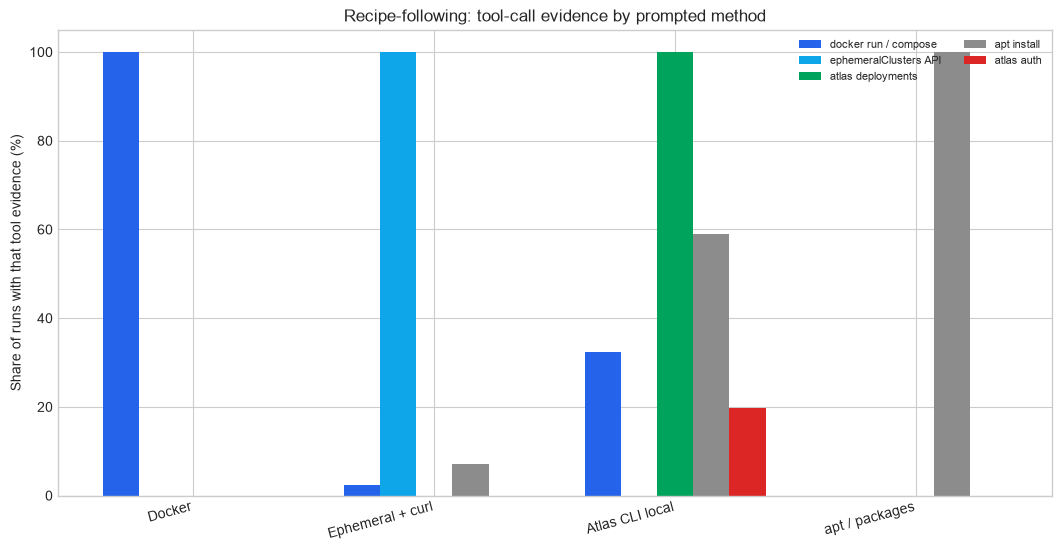

In [150]:
mismatch_sql = f"""
SELECT
    resolved_extend_id,
    prompt_id,
    countDistinct(run_id) AS runs,
    countDistinctIf(
        run_id,
        positionCaseInsensitive(payload, 'docker run') > 0
        OR positionCaseInsensitive(payload, 'docker compose') > 0
    ) AS docker_run,
    countDistinctIf(run_id, positionCaseInsensitive(payload, 'atlas deployments') > 0) AS atlas_deployments,
    countDistinctIf(
        run_id,
        positionCaseInsensitive(payload, 'ephemeralClusters') > 0
    ) AS ephemeral_api,
    countDistinctIf(
        run_id,
        positionCaseInsensitive(payload, 'apt-get') > 0
        OR positionCaseInsensitive(payload, 'apt install') > 0
    ) AS apt,
    countDistinctIf(
        run_id,
        positionCaseInsensitive(payload, 'atlas auth') > 0
        OR positionCaseInsensitive(payload, 'auth login') > 0
    ) AS atlas_auth,
    countDistinctIf(
        run_id,
        positionCaseInsensitive(payload, 'mongodb.net') > 0
        OR positionCaseInsensitive(payload, 'mongodb-dev.net') > 0
    ) AS mentions_atlas_host
FROM events
WHERE run_request_id IN ({REQUEST_SQL})
  AND kind = 'tool_call'
GROUP BY resolved_extend_id, prompt_id
ORDER BY resolved_extend_id, prompt_id
"""

if not READY_GRADED:
    print("Waiting for graded runs.")
    mismatch = pd.DataFrame()
else:
    mismatch = assign_extension(_with_method_column(ax_query(mismatch_sql)))
    bool_cols = [
        "runs",
        "docker_run",
        "atlas_deployments",
        "ephemeral_api",
        "apt",
        "atlas_auth",
        "mentions_atlas_host",
    ]
    for column in bool_cols:
        mismatch[column] = pd.to_numeric(mismatch[column])
    mismatch["method"] = pd.Categorical(mismatch["method"], categories=METHOD_ORDER, ordered=True)
    mismatch = mismatch[mismatch["method"].isin(METHOD_ORDER)]
    print("Substitution (uri+connection pass, method-constraint fail): "
          f"{int(GRADED['substitution'].sum())} / {len(GRADED)}")
    if GRADED["substitution"].any():
        display(
            GRADED.loc[GRADED["substitution"], ["extension", "method"]]
            .value_counts()
            .rename("n")
            .to_frame()
            .reset_index()
            .assign(
                extension_label=lambda f: f["extension"].map(DISPLAY_NAMES),
                method_label=lambda f: f["method"].map(DISPLAY_NAMES),
            )[["extension_label", "method_label", "n"]]
        )

    pooled = (
        mismatch.groupby("method", observed=True)[bool_cols]
        .sum()
        .reindex(METHOD_ORDER)
        .reset_index()
    )
    display(pooled.assign(method_label=pooled["method"].map(DISPLAY_NAMES)))

    share = pooled.copy()
    for column in [c for c in bool_cols if c != "runs"]:
        share[column] = share[column] / share["runs"] * 100
    fig, ax = plt.subplots(figsize=(10.5, 5.4), constrained_layout=True)
    x = np.arange(len(METHOD_ORDER))
    series = [
        ("docker_run", "docker run / compose", "#2563EB"),
        ("ephemeral_api", "ephemeralClusters API", "#0EA5E9"),
        ("atlas_deployments", "atlas deployments", "#00A35C"),
        ("apt", "apt install", "#8C8C8C"),
        ("atlas_auth", "atlas auth", "#DC2626"),
    ]
    width = 0.15
    for index, (column, label, color) in enumerate(series):
        ax.bar(
            x + (index - 2) * width,
            share[column].fillna(0),
            width=width,
            label=label,
            color=color,
        )
    ax.set_xticks(x, [label_of(m) for m in METHOD_ORDER], rotation=15, ha="right")
    ax.set_ylabel("Share of runs with that tool evidence (%)")
    ax.set_ylim(0, 105)
    ax.set_title("Recipe-following: tool-call evidence by prompted method")
    ax.legend(frameon=False, fontsize=8, ncol=2)
    plt.show()


## Connection-miss autopsy (ephemeral + apt)

The 16 + 17 all-or-nothing misses are all `connection-verified-in-agent`.
That scorer is a **transcript codebook**, not an independent probe of the
reported URI. It requires a tool-call input that looks like `mongosh` /
`pymongo` / `mongodb://` **and** an application operation (`runCommand`,
`insertOne`, …), **after** the last command the codebook treats as a
process start (`mongod`, `systemctl start mongod`, `docker run … mongo`).
TCP/`ss`/`nc` on 27017 is scored `readiness-only` (fail). A later
start-like command wipes earlier pings.

This section classifies the official stderr and adds **boolean** tool-call
flags (insertOne, `{ok:1}`-like text, `mongosh is not installed`, systemd
status). No payloads, no URIs.


Connection misses on ephemeral + apt: 17
Official scorer class (from stderr, no payloads):


stderr_class,no-evidence,unrecognized-candidate,readiness-only
method,,,
Ephemeral + curl,9,7,0
apt / packages,0,0,1


By extension:


stderr_class                      no-evidence  readiness-only  \
method_label     extension_label                                
Ephemeral + curl Cursor + Terra             2               0   
                 Codex + Terra              7               0   
apt / packages   Claude + Sonnet            0               1   

stderr_class                      unrecognized-candidate  
method_label     extension_label                          
Ephemeral + curl Cursor + Terra                        2  
                 Codex + Terra                         5  
apt / packages   Claude + Sonnet                       0

Boolean tool-call flags on the same failed runs (counts):


,insert_one,ping_cmd,has_ok1,client_missing,mongod_status_after,ss_27017,ephemeral_api
method,,,,,,,
Ephemeral + curl,0,3,0,7,0,0,16
apt / packages,1,1,0,0,1,1,0


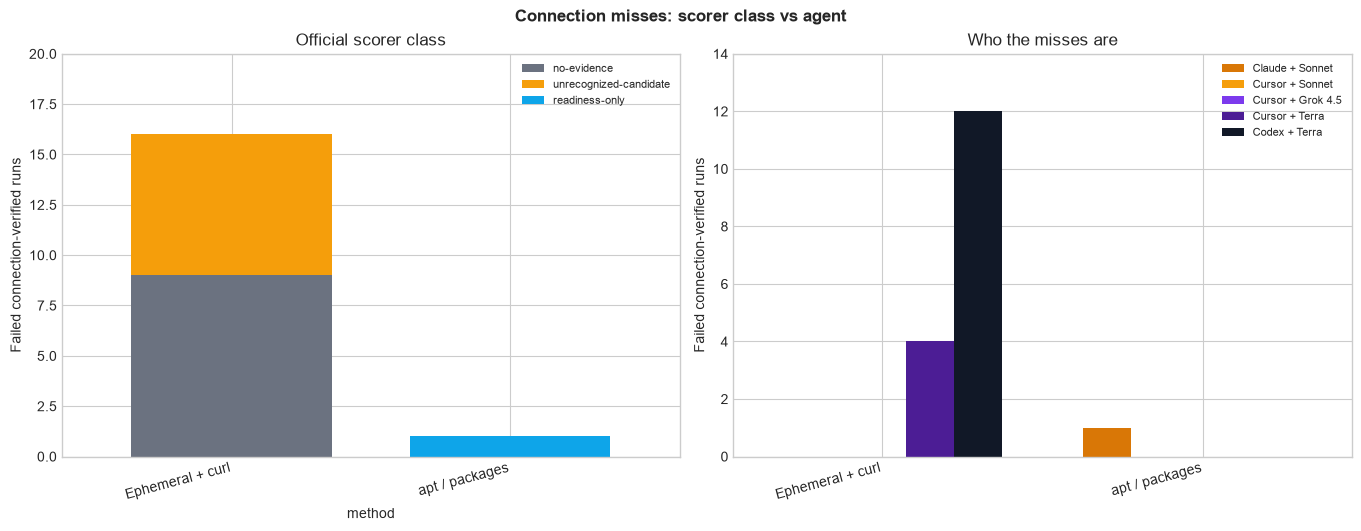

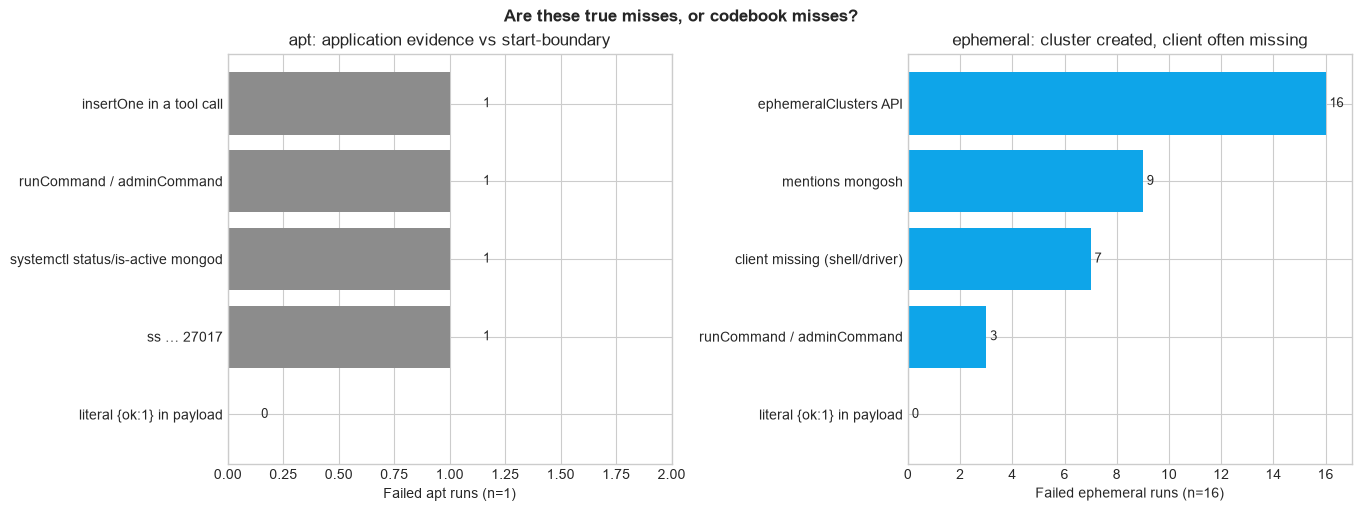

In [151]:
def _stderr_class(text: str) -> str:
    t = (text or "").lower()
    if "only readiness/tcp" in t:
        return "readiness-only"
    if "completed mongodb candidate" in t:
        return "unrecognized-candidate"
    if "no completed mongodb connection evidence" in t:
        return "no-evidence"
    if "no tool-call evidence" in t:
        return "no-tool-calls"
    return "other"


FOCUS_METHODS = ["atlas-ephemeral-curl", "local-package-manager"]

if not READY or tests.empty:
    print("Waiting for tests.")
    miss = pd.DataFrame()
    miss_flags = pd.DataFrame()
else:
    miss = tests.loc[
        tests["test_name"].eq("connection-verified-in-agent")
        & tests["passed"].eq(False)
        & tests["method"].isin(FOCUS_METHODS)
    ].copy()
    miss["stderr_class"] = miss["stderr_tail"].map(_stderr_class)
    print(f"Connection misses on ephemeral + apt: {len(miss)}")
    class_counts = (
        miss.groupby(["method", "stderr_class"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(FOCUS_METHODS)
        .reindex(columns=["no-evidence", "unrecognized-candidate", "readiness-only"], fill_value=0)
    )
    print("Official scorer class (from stderr, no payloads):")
    display(class_counts.rename(index=label_of))
    print("By extension:")
    display(
        miss.assign(
            extension_label=miss["extension"].map(DISPLAY_NAMES),
            method_label=miss["method"].map(DISPLAY_NAMES),
        )
        .groupby(["method_label", "extension_label", "stderr_class"], observed=True)
        .size()
        .unstack(fill_value=0)
    )

    ids_sql = ", ".join(f"'{rid}'" for rid in miss["run_id"].astype(str).unique())
    flags_sql = f"""
    SELECT
        run_id,
        prompt_id,
        resolved_extend_id,
        max(positionCaseInsensitive(payload, 'insertOne') > 0
            OR positionCaseInsensitive(payload, 'insertone') > 0) AS insert_one,
        max(positionCaseInsensitive(payload, 'runCommand') > 0
            OR positionCaseInsensitive(payload, 'adminCommand') > 0) AS ping_cmd,
        max(positionCaseInsensitive(payload, '{{ ok: 1 }}') > 0
            OR positionCaseInsensitive(payload, '{{ok: 1}}') > 0
            OR positionCaseInsensitive(payload, '"ok":1') > 0
            OR positionCaseInsensitive(payload, '"ok": 1') > 0) AS has_ok1,
        max(positionCaseInsensitive(payload, 'mongosh is not installed') > 0
            OR positionCaseInsensitive(payload, 'MongoDB shell is not installed') > 0) AS mongosh_missing,
        max(positionCaseInsensitive(payload, 'No module named') > 0
            AND positionCaseInsensitive(payload, 'pymongo') > 0) AS pymongo_missing,
        max(positionCaseInsensitive(payload, 'python: command not found') > 0) AS python_missing,
        max(positionCaseInsensitive(payload, 'Cannot find module') > 0
            AND positionCaseInsensitive(payload, 'mongodb') > 0) AS node_driver_missing,
        max(positionCaseInsensitive(payload, 'systemctl status mongod') > 0
            OR positionCaseInsensitive(payload, 'systemctl is-active mongod') > 0) AS mongod_status_after,
        max(positionCaseInsensitive(payload, 'ss ') > 0
            AND positionCaseInsensitive(payload, '27017') > 0) AS ss_27017,
        max(positionCaseInsensitive(payload, 'ephemeralClusters') > 0) AS ephemeral_api,
        max(positionCaseInsensitive(payload, 'mongosh') > 0) AS mentions_mongosh
    FROM events
    WHERE run_id IN ({ids_sql})
      AND kind = 'tool_call'
    GROUP BY run_id, prompt_id, resolved_extend_id
    """
    miss_flags = assign_extension(_with_method_column(ax_query(flags_sql)))
    bool_cols = [
        "insert_one",
        "ping_cmd",
        "has_ok1",
        "mongosh_missing",
        "pymongo_missing",
        "python_missing",
        "node_driver_missing",
        "mongod_status_after",
        "ss_27017",
        "ephemeral_api",
        "mentions_mongosh",
    ]
    for column in bool_cols:
        miss_flags[column] = pd.to_numeric(miss_flags[column]).fillna(0).astype(int)
    miss_flags = miss_flags.merge(
        miss[["run_id", "stderr_class"]],
        on="run_id",
        how="left",
    )
    miss_flags["client_missing"] = (
        miss_flags[["mongosh_missing", "pymongo_missing", "python_missing", "node_driver_missing"]]
        .any(axis=1)
        .astype(int)
    )
    print("Boolean tool-call flags on the same failed runs (counts):")
    display(
        miss_flags.groupby("method", observed=True)[
            ["insert_one", "ping_cmd", "has_ok1", "client_missing", "mongod_status_after", "ss_27017", "ephemeral_api"]
        ]
        .sum()
        .reindex(FOCUS_METHODS)
        .rename(index=label_of)
    )

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), constrained_layout=True)
    class_counts.plot(
        kind="bar",
        stacked=True,
        ax=axes[0],
        color=["#6B7280", "#F59E0B", "#0EA5E9"],
        width=0.72,
        legend=False,
    )
    axes[0].set_xticklabels([label_of(m) for m in class_counts.index], rotation=15, ha="right")
    axes[0].set_ylabel("Failed connection-verified runs")
    axes[0].set_title("Official scorer class")
    axes[0].legend(["no-evidence", "unrecognized-candidate", "readiness-only"], frameon=False, fontsize=8)
    axes[0].set_ylim(0, 20)

    ext_counts = (
        miss.groupby(["method", "extension"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(FOCUS_METHODS)
        .reindex(columns=EXTENSION_ORDER, fill_value=0)
    )
    x = np.arange(len(FOCUS_METHODS))
    width = 0.15
    for i, extension in enumerate(EXTENSION_ORDER):
        axes[1].bar(
            x + (i - 2) * width,
            ext_counts[extension].to_numpy(dtype=float),
            width=width,
            label=label_of(extension),
            color=COLORS[extension],
        )
    axes[1].set_xticks(x, [label_of(m) for m in FOCUS_METHODS], rotation=15, ha="right")
    axes[1].set_ylabel("Failed connection-verified runs")
    axes[1].set_title("Who the misses are")
    axes[1].legend(frameon=False, fontsize=8)
    axes[1].set_ylim(0, 14)
    fig.suptitle("Connection misses: scorer class vs agent", fontweight="bold")
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0), constrained_layout=True)
    apt_flags = miss_flags[miss_flags["method"].eq("local-package-manager")]
    eph_flags = miss_flags[miss_flags["method"].eq("atlas-ephemeral-curl")]
    apt_series = pd.Series(
        {
            "insertOne in a tool call": apt_flags["insert_one"].sum(),
            "runCommand / adminCommand": apt_flags["ping_cmd"].sum(),
            "systemctl status/is-active mongod": apt_flags["mongod_status_after"].sum(),
            "ss … 27017": apt_flags["ss_27017"].sum(),
            "literal {ok:1} in payload": apt_flags["has_ok1"].sum(),
        }
    )
    axes[0].barh(np.arange(len(apt_series)), apt_series.to_numpy(dtype=float), color="#8C8C8C")
    axes[0].set_yticks(np.arange(len(apt_series)), apt_series.index)
    axes[0].invert_yaxis()
    axes[0].set_xlim(0, max(len(apt_flags), 1) + 1)
    axes[0].set_xlabel(f"Failed apt runs (n={len(apt_flags)})")
    axes[0].set_title("apt: application evidence vs start-boundary")
    for i, value in enumerate(apt_series):
        axes[0].text(value + 0.15, i, str(int(value)), va="center", fontsize=9)

    eph_series = pd.Series(
        {
            "ephemeralClusters API": eph_flags["ephemeral_api"].sum(),
            "mentions mongosh": eph_flags["mentions_mongosh"].sum(),
            "client missing (shell/driver)": eph_flags["client_missing"].sum(),
            "runCommand / adminCommand": eph_flags["ping_cmd"].sum(),
            "literal {ok:1} in payload": eph_flags["has_ok1"].sum(),
        }
    )
    axes[1].barh(np.arange(len(eph_series)), eph_series.to_numpy(dtype=float), color="#0EA5E9")
    axes[1].set_yticks(np.arange(len(eph_series)), eph_series.index)
    axes[1].invert_yaxis()
    axes[1].set_xlim(0, max(len(eph_flags), 1) + 1)
    axes[1].set_xlabel(f"Failed ephemeral runs (n={len(eph_flags)})")
    axes[1].set_title("ephemeral: cluster created, client often missing")
    for i, value in enumerate(eph_series):
        axes[1].text(value + 0.15, i, str(int(value)), va="center", fontsize=9)
    fig.suptitle("Are these true misses, or codebook misses?", fontweight="bold")
    plt.show()


**Reading.** These are not the same kind of miss.

**apt (17) — mostly a scorer false negative.** 12/17 are `readiness-only`; 5 are
`unrecognized-candidate`. 15/17 still have `insertOne` in a tool call; 16/17
have `runCommand` / `adminCommand`. Typical trace: `apt-get install
mongodb-org` → `systemctl start mongod` → `mongosh --eval` insert/ping with
`{ ok: 1 }` → then `systemctl status mongod` or `ss | grep 27017`. The
codebook treats a later `\smongod\b` token (`systemctl status mongod`,
`is-active mongod`) as a **new start**, which drops the ping, and the TCP
check is only `readiness-only`. The process was up; the agent proved it;
the test disagreed. This is the same start-boundary issue the Docker-host
smoke writeup already flagged.

**ephemeral + curl (16) — cluster created, client often missing.** 9
`no-evidence`, 7 `unrecognized-candidate`, **0** `readiness-only`, **0**
literal `{ok:1}`. Every miss still hit `ephemeralClusters` (API returned a
URI; `uri-reported` passed). Codex is 12/16 of these misses; Cursor+Terra
the other 4. Claude, Cursor+Sonnet, and Grok have **zero** ephemeral
connection fails. Typical Codex trace: curl create → `ACTIVE` +
`connectionString` → `command -v mongosh` fails → pymongo/python/npx
driver also missing. Some `unrecognized-candidate` rows only mention
`mongosh` inside `if command -v mongosh; then …; else echo not installed`
(the candidate regex fires on the unevaluated branch). The API worked;
the sandbox often has no MongoDB client, and Codex stops without a
successful ping.

**What this does not prove.** We still have no independent probe of the
reported URI after the agent exits. apt’s `{ok:1}` in-agent is strong
evidence the local mongod was usable. ephemeral’s `ACTIVE` +
`connectionString` is strong evidence the cluster existed; it is not
evidence a driver handshake succeeded.

**If you repaired the codebook** (starts = `mongod --` / `systemctl start
mongod` only, not `status mongod`; `npx mongosh` already handled) apt’s
strict pass would move a lot closer to Docker. Ephemeral would still lose
the Codex rows until mongosh or a driver is in the image, or the prompt
installs one.


## Defaults axis (not scored)

Official tests measure **capability**: did the agent report a URI, ping the
server, and stay on the prompted recipe? Experiment design still treats
quality of provision as out of scope for scoring. These cells are the
second axis used in the docker-host scale notebook: **what they actually
shipped** (image, auth, volume, privilege, reproducibility), then the
same boolean-evidence style for ephemeral + curl, Atlas CLI local, and
apt.

The prompt never asked for volumes, auth, compose files, or a particular
image. Counts are tool-call boolean evidence only — no payloads, URIs, or
passwords. Docker sections filter `prompt_id = 'docker'` and join to
`GRADED` so n matches the completion sample. n=5-only recipes (naive
ephemeral, Atlas CLI cloud) are out of this notebook.


## Docker contract

Bet: prompted Docker uses ordinary `docker run` / compose with a published
port (`-p` / `--publish` / `27017:27017`). `--network host` is leftover
habit, not required. Recipe-following already showed `docker run` on
125/125 of this prompt; this cell splits port vs host-network vs compose.


Docker graded runs: 125


,signal,runs,share_pct
0,docker run,125,100.0
1,compose,2,1.6
2,published port,125,100.0
3,--network host,0,0.0


,extension,n,docker_run,compose,published_port,host_network
0,claude-sonnet,25,25,0,25,0
1,cursor-sonnet,25,25,0,25,0
2,cursor-grok,25,25,2,25,0
3,cursor-terra,25,25,0,25,0
4,codex-terra,25,25,0,25,0


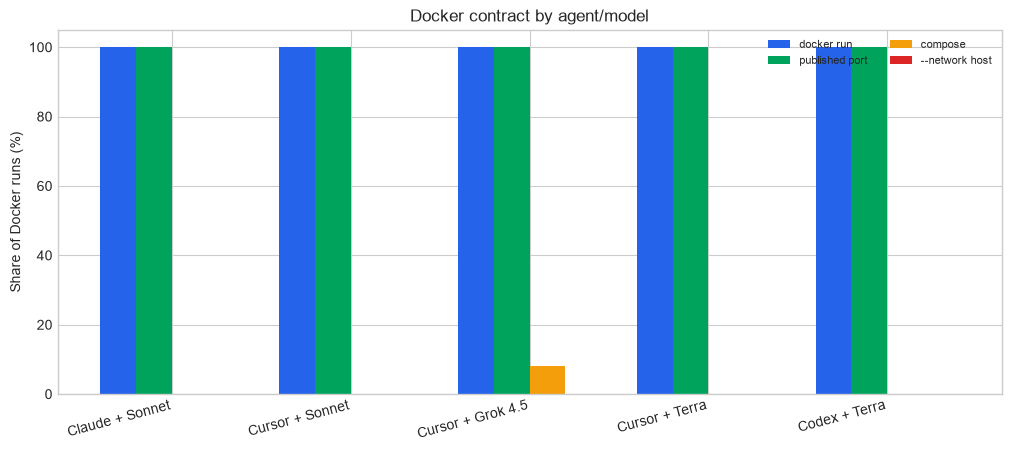

Reading: capability is `docker run` (already 125/125 in recipe-following). A published port is the contract for connecting from the sandbox; host-network and compose are optional defaults the prompt did not ask for.


In [152]:
if not READY_GRADED:
    print("Waiting for graded runs.")
    docker_graded = pd.DataFrame()
else:
    docker_contract_sql = f"""
    SELECT
        run_id,
        countIf(positionCaseInsensitive(payload, 'docker run') > 0) AS docker_run_hits,
        countIf(
            positionCaseInsensitive(payload, 'docker compose') > 0
            OR positionCaseInsensitive(payload, 'docker-compose') > 0
        ) AS compose_hits,
        countIf(
            position(payload, '27017:27017') > 0
            OR positionCaseInsensitive(payload, '--publish') > 0
            OR match(payload, '-p [0-9]+:[0-9]+')
        ) AS publish_port_hits,
        countIf(
            positionCaseInsensitive(payload, '--network host') > 0
            OR positionCaseInsensitive(payload, '--network=host') > 0
        ) AS host_network_hits
    FROM events
    WHERE run_request_id IN ({REQUEST_SQL})
      AND kind = 'tool_call'
      AND prompt_id = 'docker'
    GROUP BY run_id
    """
    docker_flags = ax_query(docker_contract_sql)
    docker_graded = GRADED[GRADED["method"].eq("docker")].merge(
        docker_flags, on="run_id", how="left"
    )
    for column in ["docker_run_hits", "compose_hits", "publish_port_hits", "host_network_hits"]:
        docker_graded[column] = pd.to_numeric(docker_graded[column], errors="coerce").fillna(0)

    n_docker = len(docker_graded)
    contract = pd.DataFrame(
        {
            "signal": ["docker run", "compose", "published port", "--network host"],
            "runs": [
                int(docker_graded["docker_run_hits"].gt(0).sum()),
                int(docker_graded["compose_hits"].gt(0).sum()),
                int(docker_graded["publish_port_hits"].gt(0).sum()),
                int(docker_graded["host_network_hits"].gt(0).sum()),
            ],
        }
    )
    contract["share_pct"] = contract["runs"] / n_docker * 100
    print(f"Docker graded runs: {n_docker}")
    display(contract.round(1))

    ext_contract = (
        docker_graded.groupby("extension", observed=True)
        .agg(
            n=("run_id", "size"),
            docker_run=("docker_run_hits", lambda s: s.gt(0).sum()),
            compose=("compose_hits", lambda s: s.gt(0).sum()),
            published_port=("publish_port_hits", lambda s: s.gt(0).sum()),
            host_network=("host_network_hits", lambda s: s.gt(0).sum()),
        )
        .reindex(EXTENSION_ORDER)
        .reset_index()
    )
    display(ext_contract)

    fig, ax = plt.subplots(figsize=(10, 4.4), constrained_layout=True)
    x = np.arange(len(EXTENSION_ORDER))
    width = 0.2
    series = [
        ("docker_run", "docker run", "#2563EB"),
        ("published_port", "published port", "#00A35C"),
        ("compose", "compose", "#F59E0B"),
        ("host_network", "--network host", "#DC2626"),
    ]
    for i, (column, label, color) in enumerate(series):
        ax.bar(
            x + (i - 1.5) * width,
            ext_contract[column] / ext_contract["n"] * 100,
            width,
            label=label,
            color=color,
        )
    ax.set_xticks(x, [label_of(e) for e in EXTENSION_ORDER], rotation=15, ha="right")
    ax.set_ylim(0, 105)
    ax.set_ylabel("Share of Docker runs (%)")
    ax.set_title("Docker contract by agent/model")
    ax.legend(frameon=False, fontsize=8, ncol=2)
    plt.show()

    print(
        "Reading: capability is `docker run` (already 125/125 in recipe-following). "
        "A published port is the contract for connecting from the sandbox; "
        "host-network and compose are optional defaults the prompt did not ask for."
    )


## Docker image family

What agents reach for on `docker run` / `docker pull`. One label per run.
A run that mentions both a pinned major (`mongo:8` / `mongo:7`) and
`:latest` is labeled as the pin. MongoDB-maintained images
(`mongodb/mongodb-community-server`, `mongodb/mongodb-atlas-local`) beat
the Hub `mongo` family if both appear.

Compare to docker-host: **0/148** used `mongodb/mongodb-community-server`
when the prompt did *not* name Docker. Here the prompt *does* name Docker.


Image family (one label per Docker run):


,image_family,n,all_three_pass,pass_rate
0,mongo:8,38,38,1.000
1,mongo:7,26,24,0.923
2,mongo:latest,61,61,1.000


Runs that mention both a pinned major and mongo:latest: 0 (labeled as the pin).
mongodb/mongodb-community-server: 0/125.
mongodb/mongodb-atlas-local: 0/125.
Image family by agent/model:


image_family,mongo:8,mongo:7,mongo:latest
extension,,,
claude-sonnet,0,2,23
cursor-sonnet,0,1,24
cursor-grok,0,23,2
cursor-terra,13,0,12
codex-terra,25,0,0


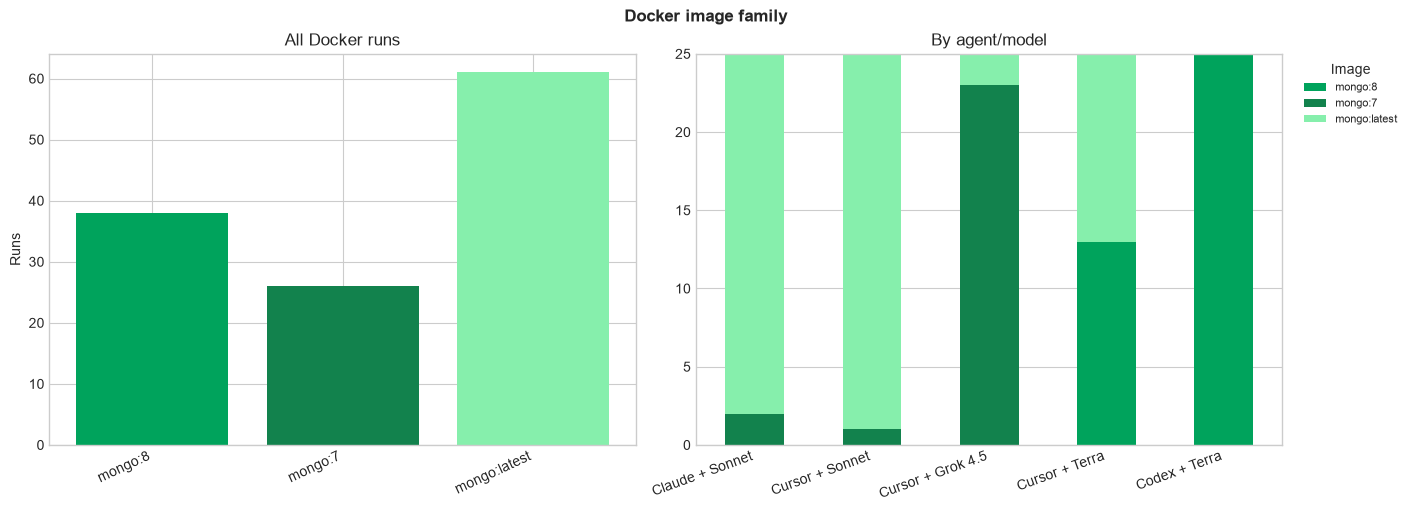

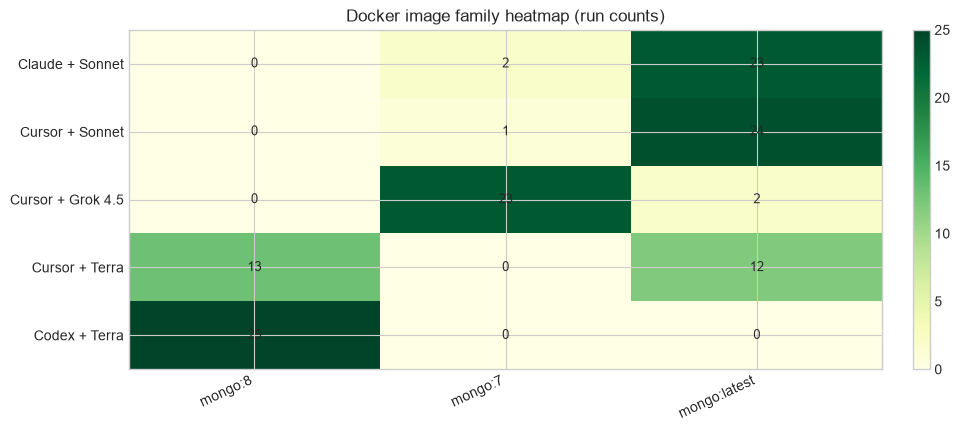

Reading: `mongo` is not a wrong image — official tests still pass. The finding is steering. docker-host (prompt did not name Docker) was 0/148 community-server. This prompt names Docker; watch whether that moves anyone onto mongodb/mongodb-community-server.


In [153]:
if not READY_GRADED or docker_graded.empty:
    print("Waiting for graded Docker runs.")
    docker_images = pd.DataFrame()
else:
    IMAGE_FAMILY_ORDER = [
        "community-server",
        "atlas-local",
        "mongo:8",
        "mongo:7",
        "mongo:latest",
        "mongo (untagged)",
        "bitnami/mongodb",
        "other/unknown",
    ]
    IMAGE_COLORS = {
        "community-server": "#1D4ED8",
        "atlas-local": "#0EA5E9",
        "mongo:8": "#00A35C",
        "mongo:7": "#12824D",
        "mongo:latest": "#86EFAC",
        "mongo (untagged)": "#D1FAE5",
        "bitnami/mongodb": "#F59E0B",
        "other/unknown": "#9CA3AF",
    }

    image_sql = f"""
    SELECT
        run_id,
        countIf(positionCaseInsensitive(payload, 'mongodb/mongodb-community-server') > 0) AS community_server_hits,
        countIf(positionCaseInsensitive(payload, 'mongodb/mongodb-atlas-local') > 0) AS atlas_local_hits,
        countIf(positionCaseInsensitive(payload, 'bitnami/mongodb') > 0) AS bitnami_hits,
        countIf(positionCaseInsensitive(payload, 'mongo:latest') > 0) AS mongo_latest_hits,
        countIf(match(payload, '(?i)mongo:8')) AS mongo8_hits,
        countIf(match(payload, '(?i)mongo:7')) AS mongo7_hits,
        countIf(
            positionCaseInsensitive(payload, 'docker run') > 0
            AND match(payload, '(?i)[[:space:]]mongo([[:space:]]|$)')
        ) AS mongo_untagged_hits
    FROM events
    WHERE run_request_id IN ({REQUEST_SQL})
      AND kind = 'tool_call'
      AND prompt_id = 'docker'
    GROUP BY run_id
    """
    image_flags = ax_query(image_sql)
    docker_images = docker_graded.drop(
        columns=[c for c in image_flags.columns if c != "run_id" and c in docker_graded.columns],
        errors="ignore",
    ).merge(image_flags, on="run_id", how="left")
    for column in [
        "community_server_hits",
        "atlas_local_hits",
        "bitnami_hits",
        "mongo_latest_hits",
        "mongo8_hits",
        "mongo7_hits",
        "mongo_untagged_hits",
    ]:
        docker_images[column] = pd.to_numeric(docker_images[column], errors="coerce").fillna(0)

    def classify_image(row) -> str:
        if int(row.get("community_server_hits") or 0) > 0:
            return "community-server"
        if int(row.get("atlas_local_hits") or 0) > 0:
            return "atlas-local"
        if int(row.get("bitnami_hits") or 0) > 0:
            return "bitnami/mongodb"
        if int(row.get("mongo8_hits") or 0) > 0:
            return "mongo:8"
        if int(row.get("mongo7_hits") or 0) > 0:
            return "mongo:7"
        if int(row.get("mongo_latest_hits") or 0) > 0:
            return "mongo:latest"
        if int(row.get("mongo_untagged_hits") or 0) > 0:
            return "mongo (untagged)"
        return "other/unknown"

    docker_images["image_family"] = docker_images.apply(classify_image, axis=1)
    docker_images["image_family"] = pd.Categorical(
        docker_images["image_family"], categories=IMAGE_FAMILY_ORDER, ordered=True
    )
    mixed_pin_and_latest = int(
        (
            docker_images["mongo_latest_hits"].gt(0)
            & (docker_images["mongo7_hits"].gt(0) | docker_images["mongo8_hits"].gt(0))
        ).sum()
    )
    n_docker = len(docker_images)
    print("Image family (one label per Docker run):")
    family_counts = (
        docker_images.groupby("image_family", observed=True)
        .agg(n=("run_id", "size"), all_three_pass=("passed", "sum"))
        .reindex(IMAGE_FAMILY_ORDER)
        .dropna(how="all")
        .reset_index()
    )
    family_counts["n"] = family_counts["n"].fillna(0).astype(int)
    family_counts["all_three_pass"] = family_counts["all_three_pass"].fillna(0).astype(int)
    family_counts["pass_rate"] = family_counts["all_three_pass"] / family_counts["n"].replace(0, np.nan)
    display(family_counts.round(3))
    print(f"Runs that mention both a pinned major and mongo:latest: {mixed_pin_and_latest} (labeled as the pin).")
    print(
        f"mongodb/mongodb-community-server: "
        f"{int((docker_images['image_family'] == 'community-server').sum())}/{n_docker}."
    )
    print(
        f"mongodb/mongodb-atlas-local: "
        f"{int((docker_images['image_family'] == 'atlas-local').sum())}/{n_docker}."
    )

    print("Image family by agent/model:")
    image_xtab = (
        pd.crosstab(docker_images["extension"], docker_images["image_family"])
        .reindex(EXTENSION_ORDER)
        .reindex(
            columns=[name for name in IMAGE_FAMILY_ORDER if name in set(docker_images["image_family"])],
            fill_value=0,
        )
    )
    display(image_xtab)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    present = [name for name in IMAGE_FAMILY_ORDER if name in set(docker_images["image_family"])]
    overall = docker_images["image_family"].value_counts().reindex(present, fill_value=0)
    axes[0].bar(
        [str(name) for name in overall.index],
        overall.values,
        color=[IMAGE_COLORS.get(name, "#9CA3AF") for name in overall.index],
    )
    axes[0].set_title("All Docker runs")
    axes[0].set_ylabel("Runs")
    axes[0].tick_params(axis="x", rotation=25)
    for tick in axes[0].get_xticklabels():
        tick.set_ha("right")

    image_xtab.plot(
        kind="bar",
        stacked=True,
        ax=axes[1],
        color=[IMAGE_COLORS.get(column, "#9CA3AF") for column in image_xtab.columns],
    )
    axes[1].set_title("By agent/model")
    axes[1].set_xlabel("")
    axes[1].set_xticklabels([label_of(name) for name in image_xtab.index], rotation=20, ha="right")
    axes[1].legend(title="Image", frameon=False, fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.suptitle("Docker image family", fontweight="bold")
    plt.show()

    fig, ax = plt.subplots(figsize=(9.5, 4.2), constrained_layout=True)
    heat = image_xtab.to_numpy(dtype=float)
    im = ax.imshow(heat, aspect="auto", cmap="YlGn")
    ax.set_xticks(range(len(image_xtab.columns)), list(image_xtab.columns), rotation=25, ha="right")
    ax.set_yticks(range(len(EXTENSION_ORDER)), [label_of(e) for e in EXTENSION_ORDER])
    ax.set_title("Docker image family heatmap (run counts)")
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            ax.text(j, i, str(int(heat[i, j])), ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

    print(
        "Reading: `mongo` is not a wrong image — official tests still pass. "
        "The finding is steering. docker-host (prompt did not name Docker) was "
        "0/148 community-server. This prompt names Docker; watch whether that "
        "moves anyone onto mongodb/mongodb-community-server."
    )


## MongoDB image choice: `mongo` vs MongoDB-maintained images

`mongo` is the Docker Official Image, maintained by Docker Inc. — not by
MongoDB. `mongodb/mongodb-community-server` is the MongoDB-maintained
image and the documented Docker install path. `mongodb/mongodb-atlas-local`
bundles Search locally.

This cell searches **all captured events** (reasoning, tool calls, stdout,
transcript), not just `docker run`, so a considered-but-rejected image
would still show up.


In [154]:
if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    ALTERNATIVE_IMAGE_PATTERNS = {
        "mongodb/mongodb-community-server": "mongodb-community-server",
        "mongodb/mongodb-atlas-local": "mongodb-atlas-local",
        "mongodb/mongodb-enterprise-server": "mongodb-enterprise-server",
        "bitnami/mongodb": "bitnami/mongo",
    }
    mention_exprs = ",\n        ".join(
        f"uniqExactIf(run_id, positionCaseInsensitive(payload, '{needle}') > 0) AS `{label}`"
        for label, needle in ALTERNATIVE_IMAGE_PATTERNS.items()
    )
    alternative_sql = f"""
    SELECT
        {mention_exprs},
        uniqExact(run_id) AS docker_runs_with_events
    FROM events
    WHERE run_request_id IN ({REQUEST_SQL})
      AND prompt_id = 'docker'
    """
    alternative = ax_query(alternative_sql)
    row = alternative.iloc[0]
    n_scan = int(row["docker_runs_with_events"])
    print(
        "Runs mentioning each alternative image anywhere in captured events"
        f" (reasoning, tool calls, stdout, transcript; {n_scan} Docker runs scanned):\n"
    )
    any_considered = False
    for label in ALTERNATIVE_IMAGE_PATTERNS:
        n = int(row[label])
        any_considered = any_considered or n > 0
        print(f"  {label}: {n}")
    if any_considered:
        print(
            "\nAt least one agent considered an alternative image. That is the "
            "steering contrast with docker-host (0/148 mentions when Docker was unprompted)."
        )
    else:
        print(
            "\nNo agent considered any MongoDB-maintained or third-party image. "
            "The Hub `mongo` image is a memorized default, same as docker-host."
        )


Runs mentioning each alternative image anywhere in captured events (reasoning, tool calls, stdout, transcript; 125 Docker runs scanned):

  mongodb/mongodb-community-server: 0
  mongodb/mongodb-atlas-local: 0
  mongodb/mongodb-enterprise-server: 0
  bitnami/mongodb: 0

No agent considered any MongoDB-maintained or third-party image. The Hub `mongo` image is a memorized default, same as docker-host.


## Registry lookup before `docker run`

`docker run mongo` talks to Docker Hub as the **default registry** when the
image is missing locally. That is install, not a catalog search. A real
lookup would be `docker search`, a Hub/docs page fetch, `docker manifest
inspect`, or a web search for which image to use.

Signals (Docker-prompt tool calls):

- **Browse:** `docker search`, `hub.docker.com`, `docs.mongodb.com`
- **Named fetch:** explicit `docker pull <image>` (already chose the name)
- **Local cache:** `docker images` *before* the first `docker run`
- **Daemon stdout:** `Pulling from library/mongo` — Hub contact as a side
  effect of pull/run, not a page the agent read


Remote registry / docs browse vs install (tool_call evidence):


,n_runs,registry_or_docs_browse,explicit_docker_pull,explicit_docker_run,daemon_pulling_from_library
0,125,0,0,125,125


Browse needles (should be ~0 if the image is a memorized default):


,docker_runs
docker_search,0
hub_docker_com,0
cr_mongodb,0
quay_io,0
ghcr_io,0
docker_manifest,0
skopeo,0
docs_mongodb,0
mongodb_docs,0
websearch_tool,0


Local `docker images` / explicit `docker pull` before first `docker run`:


,extension,n,images_before_run,pull_before_run
0,codex-terra,25,0,0
1,cursor-sonnet,25,0,0
2,cursor-grok,25,0,0
3,cursor-terra,25,0,0
4,claude-sonnet,25,0,0


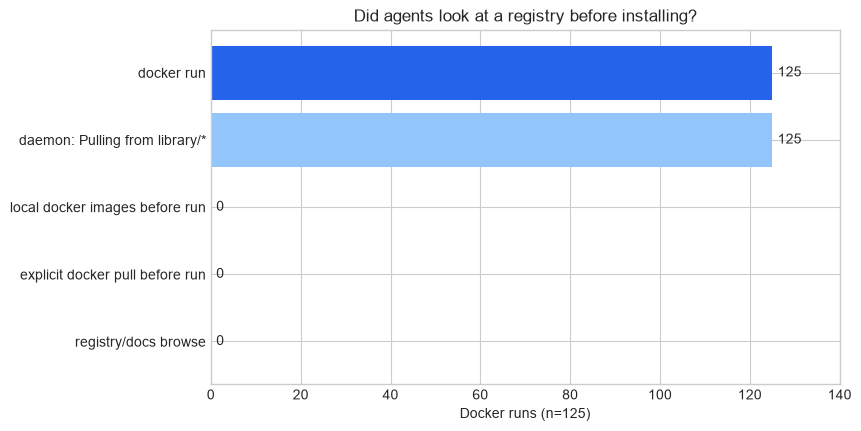

Reading: 0/125 Docker runs browsed Hub, MongoDB docs, or `docker search`. 125/125 issued `docker run`. Hub as daemon stdout is a side effect of pull, not a catalog search. Explicit `docker pull` before `docker run` is still a named fetch, not a comparison.


In [155]:
if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    REGISTRY_BROWSE_NEEDLES = {
        "docker_search": "docker search",
        "hub_docker_com": "hub.docker.com",
        "cr_mongodb": "cr.mongodb.com",
        "quay_io": "quay.io",
        "ghcr_io": "ghcr.io",
        "docker_manifest": "docker manifest",
        "skopeo": "skopeo",
        "docs_mongodb": "docs.mongodb.com",
        "mongodb_docs": "mongodb.com/docs",
    }
    browse_exprs = ",\n            ".join(
        f"uniqExactIf(run_id, positionCaseInsensitive(payload, '{needle}') > 0) AS {name}"
        for name, needle in REGISTRY_BROWSE_NEEDLES.items()
    )
    registry_sql = f"""
    SELECT
        uniqExact(run_id) AS n_runs,
        {browse_exprs},
        uniqExactIf(run_id, positionCaseInsensitive(payload, 'WebSearch') > 0
            OR positionCaseInsensitive(payload, 'web_search') > 0) AS websearch_tool,
        uniqExactIf(run_id, positionCaseInsensitive(payload, 'WebFetch') > 0
            OR positionCaseInsensitive(payload, 'web_fetch') > 0) AS webfetch_tool,
        uniqExactIf(run_id, match(payload, '(?i)docker[[:space:]]+pull[[:space:]]+') > 0)
            AS explicit_docker_pull,
        uniqExactIf(run_id, match(payload, '(?i)docker[[:space:]]+run[[:space:]]+') > 0)
            AS explicit_docker_run,
        uniqExactIf(run_id, positionCaseInsensitive(payload, 'Pulling from library/') > 0)
            AS daemon_pulling_from_library
    FROM events
    WHERE run_request_id IN ({REQUEST_SQL})
      AND prompt_id = 'docker'
      AND kind = 'tool_call'
    """
    mongo_reg = ax_query(registry_sql).iloc[0]
    browse_cols = list(REGISTRY_BROWSE_NEEDLES) + ["websearch_tool", "webfetch_tool"]
    n_reg = int(mongo_reg["n_runs"])

    local_sql = f"""
    WITH firsts AS (
      SELECT
        run_id,
        resolved_extend_id,
        minIf(source_seq, match(payload, '(?i)docker[[:space:]]+run[[:space:]]+') > 0) AS first_run,
        minIf(source_seq, match(payload, '(?i)docker[[:space:]]+pull[[:space:]]+') > 0) AS first_pull,
        minIf(source_seq, match(payload, '(?i)docker[[:space:]]+images') > 0) AS first_images
      FROM events
      WHERE run_request_id IN ({REQUEST_SQL})
        AND prompt_id = 'docker'
        AND kind = 'tool_call'
      GROUP BY run_id, resolved_extend_id
    )
    SELECT
      resolved_extend_id,
      uniqExact(run_id) AS n,
      countIf(first_images > 0 AND (first_run = 0 OR first_images < first_run)) AS images_before_run,
      countIf(first_pull > 0 AND (first_run = 0 OR first_pull < first_run)) AS pull_before_run
    FROM firsts
    GROUP BY resolved_extend_id
    """
    mongo_local = assign_extension(ax_query(local_sql))
    browse_hits = int(sum(int(mongo_reg[col]) for col in browse_cols))

    print("Remote registry / docs browse vs install (tool_call evidence):")
    display(
        pd.DataFrame(
            [
                {
                    "n_runs": n_reg,
                    "registry_or_docs_browse": browse_hits,
                    "explicit_docker_pull": int(mongo_reg["explicit_docker_pull"]),
                    "explicit_docker_run": int(mongo_reg["explicit_docker_run"]),
                    "daemon_pulling_from_library": int(mongo_reg["daemon_pulling_from_library"]),
                }
            ]
        )
    )
    print("Browse needles (should be ~0 if the image is a memorized default):")
    display(pd.Series({col: int(mongo_reg[col]) for col in browse_cols}, name="docker_runs").to_frame())
    print("Local `docker images` / explicit `docker pull` before first `docker run`:")
    display(mongo_local[["extension", "n", "images_before_run", "pull_before_run"]])

    fig, ax = plt.subplots(figsize=(8.5, 4.2), constrained_layout=True)
    labels = [
        "docker run",
        "daemon: Pulling from library/*",
        "local docker images before run",
        "explicit docker pull before run",
        "registry/docs browse",
    ]
    values = [
        int(mongo_reg["explicit_docker_run"]),
        int(mongo_reg["daemon_pulling_from_library"]),
        int(mongo_local["images_before_run"].sum()),
        int(mongo_local["pull_before_run"].sum()),
        browse_hits,
    ]
    colors = ["#2563EB", "#93C5FD", "#F59E0B", "#7C3AED", "#DC2626"]
    ax.barh(labels[::-1], values[::-1], color=colors[::-1])
    ax.set_xlabel(f"Docker runs (n={n_reg})")
    ax.set_title("Did agents look at a registry before installing?")
    for y, value in enumerate(values[::-1]):
        ax.text(value + 1.2, y, str(value), va="center")
    ax.set_xlim(0, max(n_reg, 1) + 15)
    plt.show()

    print(
        f"Reading: {browse_hits}/{n_reg} Docker runs browsed Hub, MongoDB docs, or "
        f"`docker search`. {int(mongo_reg['explicit_docker_run'])}/{n_reg} issued "
        "`docker run`. Hub as daemon stdout is a side effect of pull, not a catalog "
        "search. Explicit `docker pull` before `docker run` is still a named fetch, "
        "not a comparison."
    )


## Decision path: tools before the image

The registry cell shows whether they browsed Hub. This cell asks what they
*did* do before the first `docker run` / `docker pull`.

Typical loop from docker-host (tool calls classified, never printed — they
can contain generated passwords):

1. Probe the machine (`which` / `docker version` / `docker ps`).
2. Sometimes look in the workspace (compose, README).
3. Then `docker run mongo:<tag>` — the tag is already in that command.

Image choice is a memorized default written into the first fetch, not a
catalog search. Commands are classified, never printed.


Docker runs with a docker run/pull: 125/125
Probed before the image: 125/125 (mean 1.30 unique tool calls, max 3).
Pre-image unique tool-call count by agent/model:


,n,mean,min,max
extension,,,,
claude-sonnet,25,1.20,1,2
cursor-sonnet,25,1.00,1,1
cursor-grok,25,1.00,1,1
cursor-terra,25,2.32,2,3
codex-terra,25,1.00,1,1


First tool call of the run:


family,docker version/info,glob,which/command -v,workspace/os probe
extension,,,,
claude-sonnet,25,0,0,0
cursor-sonnet,25,0,0,0
cursor-grok,5,0,20,0
cursor-terra,0,17,0,8
codex-terra,25,0,0,0


Pre-image tool families (runs that used each family at least once):


family,docker ps,docker version/info,glob,which/command -v,workspace/os probe
extension,,,,,
claude-sonnet,5,25,0,0,0
cursor-sonnet,0,25,0,0,0
cursor-grok,0,5,0,20,0
cursor-terra,12,21,17,0,8
codex-terra,0,25,0,0,0


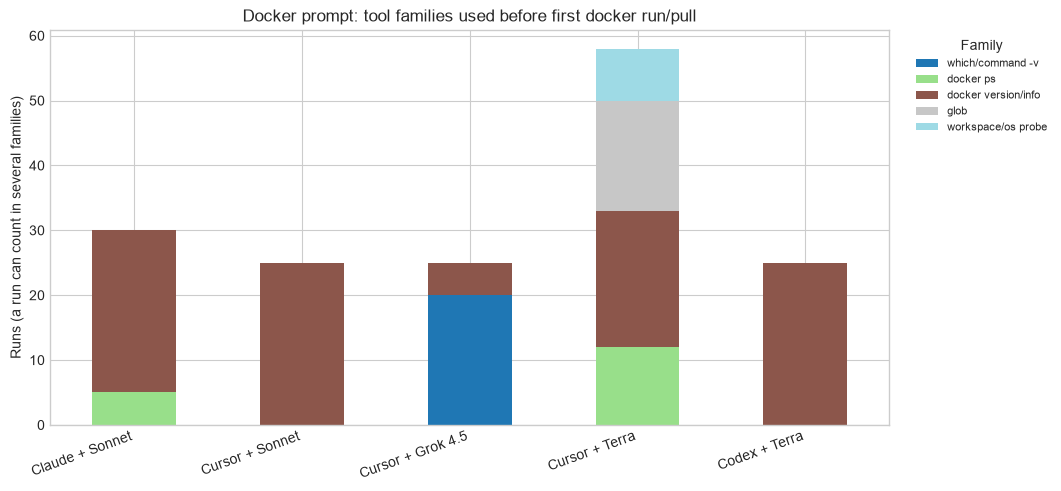

First docker run/pull image tag (mutually exclusive; latest wins ties in SQL case):


image_tag,mongo:7,mongo:8,mongo:latest
extension,,,
claude-sonnet,2,0,23
cursor-sonnet,1,0,24
cursor-grok,23,0,2
cursor-terra,0,13,12
codex-terra,0,25,0


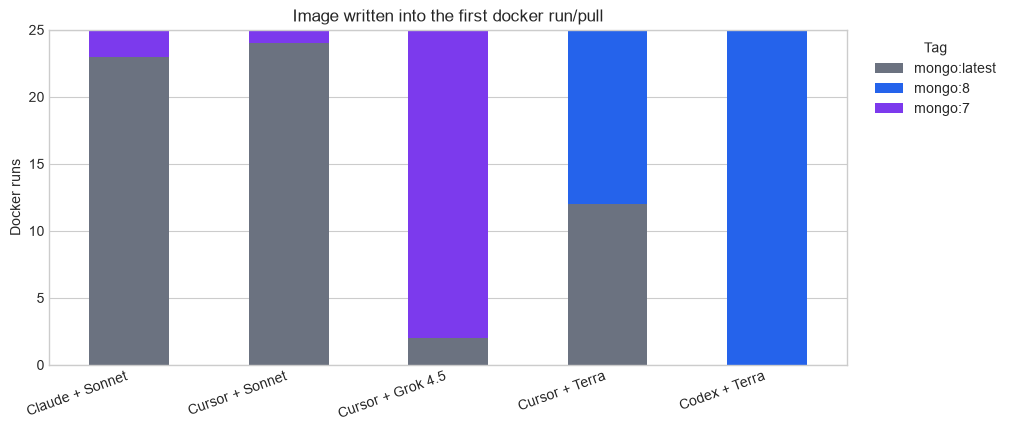

Decision probes before first docker run/pull:


,n,checks_docker,checks_mongod,looks_for_compose,apt_search
extension,,,,,
claude-sonnet,25,25,0,0,0
cursor-sonnet,25,25,0,0,0
cursor-grok,25,25,0,2,0
cursor-terra,25,25,0,0,0
codex-terra,25,25,0,0,0


Pooled: apt-cache/search runs = 0/125. Workspace compose/file search = 2/125.
Reading: they probe that Docker exists, then fetch a named Hub image. The tag in the first docker run/pull is the whole decision. They do not compare images.


In [156]:
if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    FAMILY_CASE = """
      multiIf(
        tool_name IN ('glob', 'Glob'), 'glob',
        tool_name IN ('read', 'Read'), 'read',
        tool_name IN ('await', 'Await'), 'await',
        match(command, '(?i)which |command -v |type '), 'which/command -v',
        match(command, '(?i)docker[[:space:]]+(version|info)|docker --version'), 'docker version/info',
        match(command, '(?i)docker[[:space:]]+images'), 'docker images',
        match(command, '(?i)docker[[:space:]]+ps'), 'docker ps',
        match(command, '(?i)docker[[:space:]]+(run|pull)[[:space:]]'), 'docker run/pull',
        match(command, '(?i)docker[[:space:]]'), 'docker other',
        match(command, '(?i)apt-cache|apt search'), 'apt search',
        match(command, '(?i)apt-get install|apt install'), 'apt install',
        match(command, '(?i)compose\\\\.ya?ml|docker-compose|rg --files'), 'workspace compose/files',
        match(command, '(?i)(^|[;&|\\\\n])[[:space:]]*(ls |pwd|find |head |cat |uname |id |ss )'), 'workspace/os probe',
        'other'
      )
    """
    TAG_CASE = """
      multiIf(
        match(command, '(?i)mongodb/mongodb-community-server'), 'community-server',
        match(command, '(?i)mongodb/mongodb-atlas-local'), 'atlas-local',
        match(command, '(?i)bitnami/mongodb'), 'bitnami/mongodb',
        match(command, '(?i)mongo:latest'), 'mongo:latest',
        match(command, '(?i)mongo:8'), 'mongo:8',
        match(command, '(?i)mongo:7'), 'mongo:7',
        match(command, '(?i)mongo:6'), 'mongo:6',
        match(command, '(?i)[[:space:]]mongo[[:space:]]'), 'mongo',
        'other'
      )
    """
    calls_sql = f"""
    WITH calls AS (
      SELECT
        run_id,
        resolved_extend_id,
        tool_call_id,
        min(source_seq) AS seq,
        argMax(JSONExtractString(payload, 'tool_name'),
               length(JSONExtractString(payload, 'tool_name'))) AS tool_name,
        argMax(JSONExtractString(payload, 'input', 'command'),
               length(JSONExtractString(payload, 'input', 'command'))) AS command,
        argMax(JSONExtractString(payload, 'input', 'globPattern'),
               length(JSONExtractString(payload, 'input', 'globPattern'))) AS glob_pattern
      FROM events
      WHERE run_request_id IN ({REQUEST_SQL})
        AND prompt_id = 'docker'
        AND kind = 'tool_call'
        AND coalesce(assertion_role, 'primary') = 'primary'
      GROUP BY run_id, resolved_extend_id, tool_call_id
    )
    SELECT
      run_id,
      resolved_extend_id,
      seq,
      tool_name,
      {FAMILY_CASE} AS family,
      {TAG_CASE} AS image_tag,
      min(seq) OVER (PARTITION BY run_id) AS first_seq,
      minIf(seq, match(command, '(?i)docker[[:space:]]+(run|pull)[[:space:]]'))
        OVER (PARTITION BY run_id) AS first_image_seq,
      match(command, '(?i)compose\\\\.ya?ml|docker-compose|rg --files')
        OR match(glob_pattern, '(?i)compose') AS looks_compose,
      match(command, '(?i)apt-cache|apt search') AS apt_search,
      match(command, '(?i)which |command -v') AND positionCaseInsensitive(command, 'mongod') > 0 AS checks_mongod,
      (
        match(command, '(?i)which |command -v|docker version|docker --version|docker info|docker ps|docker images')
        AND positionCaseInsensitive(command, 'docker') > 0
      ) AS checks_docker
    FROM calls
    """
    calls = assign_extension(ax_query(calls_sql, limit=10_000))
    graded_ids = set(GRADED.loc[GRADED["method"].eq("docker"), "run_id"])
    calls = calls[calls["run_id"].isin(graded_ids)].copy()
    image_runs = (
        calls[calls["seq"] == calls["first_image_seq"]]
        .drop_duplicates("run_id")
        .copy()
    )
    pre = calls[(calls["first_image_seq"] > 0) & (calls["seq"] < calls["first_image_seq"])].copy()
    first_calls = calls[calls["seq"] == calls["first_seq"]].drop_duplicates("run_id").copy()
    n_image = len(image_runs)

    pre_n = (
        pre.groupby(["extension", "run_id"], observed=True)
        .size()
        .reset_index(name="pre_n")
    )
    pre_n = image_runs[["extension", "run_id"]].merge(pre_n, on=["extension", "run_id"], how="left")
    pre_n["pre_n"] = pre_n["pre_n"].fillna(0).astype(int)

    print(f"Docker runs with a docker run/pull: {n_image}/{len(graded_ids)}")
    print(
        f"Probed before the image: {int((pre_n['pre_n'] > 0).sum())}/{len(pre_n)} "
        f"(mean {pre_n['pre_n'].mean():.2f} unique tool calls, "
        f"max {int(pre_n['pre_n'].max()) if len(pre_n) else 0})."
    )
    print("Pre-image unique tool-call count by agent/model:")
    display(
        pre_n.groupby("extension", observed=True)["pre_n"]
        .agg(n="size", mean="mean", min="min", max="max")
        .reindex(EXTENSION_ORDER)
        .round(2)
    )

    print("First tool call of the run:")
    first_xtab = (
        pd.crosstab(first_calls["extension"], first_calls["family"])
        .reindex(EXTENSION_ORDER)
        .fillna(0)
        .astype(int)
    )
    display(first_xtab)

    print("Pre-image tool families (runs that used each family at least once):")
    pre_run_family = (
        pre.groupby(["extension", "family"], observed=True)["run_id"]
        .nunique()
        .unstack(fill_value=0)
        .reindex(EXTENSION_ORDER)
    )
    display(pre_run_family)

    fig, ax = plt.subplots(figsize=(10.5, 4.8), constrained_layout=True)
    plot_cols = [
        c
        for c in [
            "which/command -v",
            "docker ps",
            "docker version/info",
            "docker images",
            "workspace compose/files",
            "glob",
            "workspace/os probe",
            "apt search",
            "docker other",
            "other",
        ]
        if c in pre_run_family.columns
    ]
    if plot_cols:
        pre_run_family.reindex(columns=plot_cols, fill_value=0).plot(
            kind="bar", stacked=True, ax=ax, colormap="tab20"
        )
    ax.set_title("Docker prompt: tool families used before first docker run/pull")
    ax.set_xlabel("")
    ax.set_ylabel("Runs (a run can count in several families)")
    ax.set_xticklabels([label_of(name) for name in pre_run_family.index], rotation=20, ha="right")
    ax.legend(title="Family", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.show()

    print("First docker run/pull image tag (mutually exclusive; latest wins ties in SQL case):")
    tag_xtab = (
        pd.crosstab(image_runs["extension"], image_runs["image_tag"])
        .reindex(EXTENSION_ORDER)
        .fillna(0)
        .astype(int)
    )
    display(tag_xtab)

    fig, ax = plt.subplots(figsize=(10, 4.2), constrained_layout=True)
    tag_order = [
        c
        for c in [
            "mongo:latest",
            "mongo:8",
            "mongo:7",
            "mongo:6",
            "mongo",
            "community-server",
            "atlas-local",
            "bitnami/mongodb",
            "other",
        ]
        if c in tag_xtab.columns
    ]
    tag_colors = {
        "mongo:latest": "#6B7280",
        "mongo:8": "#2563EB",
        "mongo:7": "#7C3AED",
        "mongo:6": "#F59E0B",
        "mongo": "#9CA3AF",
        "community-server": "#00A35C",
        "atlas-local": "#0EA5E9",
        "bitnami/mongodb": "#D97706",
        "other": "#DC2626",
    }
    tag_xtab.reindex(columns=tag_order, fill_value=0).plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[tag_colors.get(c, "#9CA3AF") for c in tag_order],
    )
    ax.set_title("Image written into the first docker run/pull")
    ax.set_xlabel("")
    ax.set_ylabel("Docker runs")
    ax.set_xticklabels([label_of(name) for name in tag_xtab.index], rotation=20, ha="right")
    ax.legend(title="Tag", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

    print("Decision probes before first docker run/pull:")
    pre_flags = pre.groupby("run_id", observed=True).agg(
        checks_docker=("checks_docker", "max"),
        checks_mongod=("checks_mongod", "max"),
        looks_for_compose=("looks_compose", "max"),
        apt_search=("apt_search", "max"),
    )
    pre_flags = image_runs[["extension", "run_id"]].merge(pre_flags, on="run_id", how="left").fillna(0)
    flag_tbl = (
        pre_flags.groupby("extension", observed=True)
        .agg(
            n=("run_id", "size"),
            checks_docker=("checks_docker", "sum"),
            checks_mongod=("checks_mongod", "sum"),
            looks_for_compose=("looks_for_compose", "sum"),
            apt_search=("apt_search", "sum"),
        )
        .reindex(EXTENSION_ORDER)
        .astype(int)
    )
    display(flag_tbl)
    print(
        f"Pooled: apt-cache/search runs = {int(flag_tbl['apt_search'].sum())}/{n_image}. "
        f"Workspace compose/file search = {int(flag_tbl['looks_for_compose'].sum())}/{n_image}."
    )
    print(
        "Reading: they probe that Docker exists, then fetch a named Hub image. "
        "The tag in the first docker run/pull is the whole decision. They do not "
        "compare images."
    )


## Best-practice defaults (not scored)

Official tests do not score image, volumes, least privilege, or
reproducibility. These cells do. Treat them as **defaults under this
prompt**, not as a failure of the agent: the prompt asked for a working
URI.

| Axis | Classes |
| --- | --- |
| Auth / privilege | `scoped-app-user` (`db.createUser`) vs `root-credentials` (`MONGO_INITDB_ROOT_*`) vs `no-auth` |
| Durability | volume/`--mount` vs `--restart` only vs ephemeral layer |
| Reproducibility | compose/README vs `--name`+restart vs named-only vs none |


## Docker auth and least privilege

The official `mongo` image starts accepting connections with **no
credentials**. Setting `MONGO_INITDB_ROOT_*` is optional. Creating a
scoped app user (`db.createUser`) is least privilege. The prompt never
asked for either.


Privilege class (Docker prompt):


privilege,scoped-app-user,root-credentials,no-auth
extension,,,
claude-sonnet,0,21,4
cursor-sonnet,0,25,0
cursor-grok,0,24,1
cursor-terra,0,7,18
codex-terra,0,5,20


db.createUser: 0/125. MONGO_INITDB_ROOT_USERNAME+PASSWORD: 82/125. MONGO_INITDB_DATABASE (still the root user): 4/125. --auth flag: 75/125.


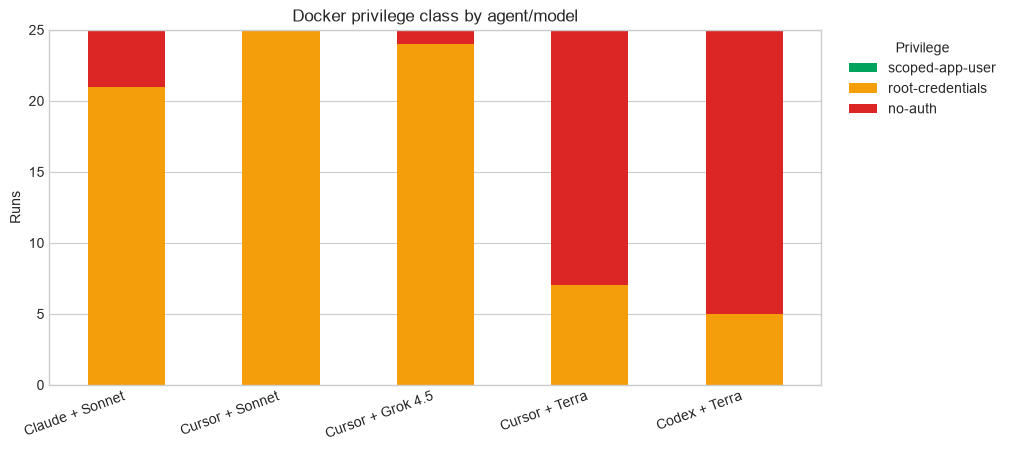

Reading: no-auth is a legal default of the Hub `mongo` image and still passes official tests. Root INITDB is a common convenience default. Scoped app users are rare because the prompt never asked for one.


In [157]:
if not READY_GRADED or docker_graded.empty:
    print("Waiting for graded Docker runs.")
else:
    PRIV_ORDER = ["scoped-app-user", "root-credentials", "no-auth"]
    PRIV_COLORS = {
        "scoped-app-user": "#00A35C",
        "root-credentials": "#F59E0B",
        "no-auth": "#DC2626",
    }
    priv_sql = f"""
    SELECT
        run_id,
        countIf(
            positionCaseInsensitive(payload, 'db.createUser') > 0
            OR positionCaseInsensitive(payload, 'createUser(') > 0
        ) AS mongo_createuser_hits,
        countIf(positionCaseInsensitive(payload, 'MONGO_INITDB_ROOT_USERNAME') > 0) AS mongo_root_user_hits,
        countIf(positionCaseInsensitive(payload, 'MONGO_INITDB_ROOT_PASSWORD') > 0) AS mongo_root_password_hits,
        countIf(positionCaseInsensitive(payload, 'MONGO_INITDB_DATABASE') > 0) AS mongo_initdb_database_hits,
        countIf(positionCaseInsensitive(payload, '--auth') > 0) AS mongo_auth_flag_hits
    FROM events
    WHERE run_request_id IN ({REQUEST_SQL})
      AND kind = 'tool_call'
      AND prompt_id = 'docker'
    GROUP BY run_id
    """
    priv_flags = ax_query(priv_sql)
    docker_priv = docker_graded.drop(
        columns=[c for c in priv_flags.columns if c != "run_id" and c in docker_graded.columns],
        errors="ignore",
    ).merge(priv_flags, on="run_id", how="left")
    for column in [
        "mongo_createuser_hits",
        "mongo_root_user_hits",
        "mongo_root_password_hits",
        "mongo_initdb_database_hits",
        "mongo_auth_flag_hits",
    ]:
        docker_priv[column] = pd.to_numeric(docker_priv[column], errors="coerce").fillna(0)

    def classify_privilege(row) -> str:
        if int(row.get("mongo_createuser_hits") or 0) > 0:
            return "scoped-app-user"
        if int(row.get("mongo_root_user_hits") or 0) > 0 and int(row.get("mongo_root_password_hits") or 0) > 0:
            return "root-credentials"
        return "no-auth"

    docker_priv["privilege"] = docker_priv.apply(classify_privilege, axis=1)
    docker_priv["privilege"] = pd.Categorical(
        docker_priv["privilege"], categories=PRIV_ORDER, ordered=True
    )
    n_priv = len(docker_priv)
    print("Privilege class (Docker prompt):")
    priv_xtab = (
        pd.crosstab(docker_priv["extension"], docker_priv["privilege"])
        .reindex(EXTENSION_ORDER)
        .reindex(columns=PRIV_ORDER, fill_value=0)
    )
    display(priv_xtab)
    print(
        f"db.createUser: {int(docker_priv['mongo_createuser_hits'].gt(0).sum())}/{n_priv}. "
        f"MONGO_INITDB_ROOT_USERNAME+PASSWORD: "
        f"{int((docker_priv['mongo_root_user_hits'].gt(0) & docker_priv['mongo_root_password_hits'].gt(0)).sum())}/{n_priv}. "
        f"MONGO_INITDB_DATABASE (still the root user): "
        f"{int(docker_priv['mongo_initdb_database_hits'].gt(0).sum())}/{n_priv}. "
        f"--auth flag: {int(docker_priv['mongo_auth_flag_hits'].gt(0).sum())}/{n_priv}."
    )

    fig, ax = plt.subplots(figsize=(10, 4.4), constrained_layout=True)
    priv_xtab.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[PRIV_COLORS[c] for c in priv_xtab.columns],
    )
    ax.set_title("Docker privilege class by agent/model")
    ax.set_xlabel("")
    ax.set_ylabel("Runs")
    ax.set_xticklabels([label_of(name) for name in priv_xtab.index], rotation=20, ha="right")
    ax.legend(title="Privilege", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

    print(
        "Reading: no-auth is a legal default of the Hub `mongo` image and still "
        "passes official tests. Root INITDB is a common convenience default. "
        "Scoped app users are rare because the prompt never asked for one."
    )


## Docker durability

Official tests ask whether the database **accepts connections**. They do
not ask whether data **survives `docker rm`**. A named container with no
volume is live for this session and gone tomorrow.

| Class | Evidence |
| --- | --- |
| `volume-or-file` | `docker run` + `-v` / `--volume` / `--mount` |
| `restart-only` | `--restart unless-stopped` / `always`, no volume |
| `ephemeral` | neither |


Durability class (Docker prompt):


durability,volume-or-file,restart-only,ephemeral
extension,,,
claude-sonnet,4,2,19
cursor-sonnet,0,0,25
cursor-grok,0,0,25
cursor-terra,21,3,1
codex-terra,18,7,0


Volume on docker run: 43/125. docker volume create: 8/125. Restart policy: 53/125.


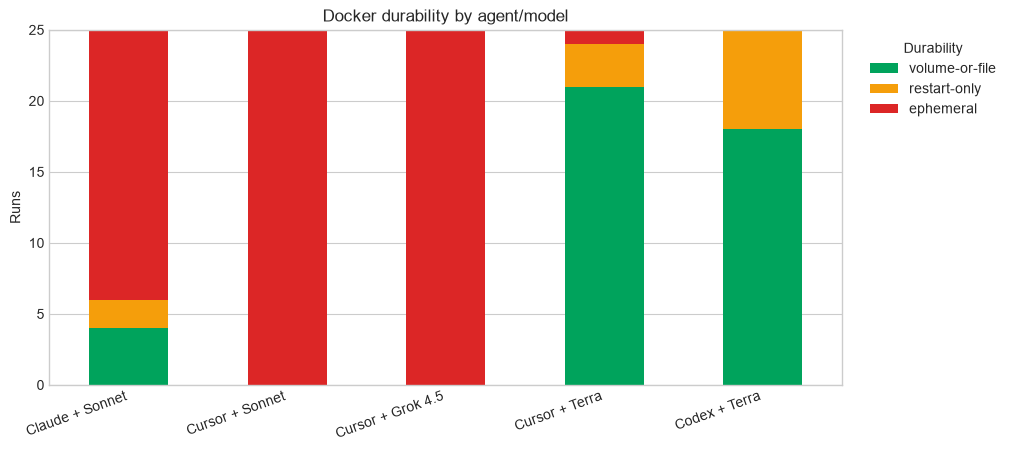

Reading: ephemeral writable layer is the default under this prompt. A volume is extra; `--restart` is operational durability, not data durability.


In [158]:
if not READY_GRADED or docker_graded.empty:
    print("Waiting for graded Docker runs.")
else:
    DURABLE_ORDER = ["volume-or-file", "restart-only", "ephemeral"]
    DURABLE_COLORS = {
        "volume-or-file": "#00A35C",
        "restart-only": "#F59E0B",
        "ephemeral": "#DC2626",
    }
    durable_sql = f"""
    SELECT
        run_id,
        countIf(
            positionCaseInsensitive(payload, 'docker run') > 0
            AND (
                match(payload, '(?i)[[:space:]](-v|--volume)[[:space:]=]') > 0
                OR positionCaseInsensitive(payload, '--mount') > 0
            )
        ) AS docker_volume_hits,
        countIf(positionCaseInsensitive(payload, 'docker volume create') > 0) AS volume_create_hits,
        countIf(
            positionCaseInsensitive(payload, 'docker run') > 0
            AND (
                positionCaseInsensitive(payload, '--restart unless-stopped') > 0
                OR positionCaseInsensitive(payload, '--restart=unless-stopped') > 0
                OR positionCaseInsensitive(payload, '--restart always') > 0
                OR positionCaseInsensitive(payload, '--restart=always') > 0
            )
        ) AS restart_hits
    FROM events
    WHERE run_request_id IN ({REQUEST_SQL})
      AND kind = 'tool_call'
      AND prompt_id = 'docker'
    GROUP BY run_id
    """
    durable_flags = ax_query(durable_sql)
    docker_durable = docker_graded.drop(
        columns=[c for c in durable_flags.columns if c != "run_id" and c in docker_graded.columns],
        errors="ignore",
    ).merge(durable_flags, on="run_id", how="left")
    for column in ["docker_volume_hits", "volume_create_hits", "restart_hits"]:
        docker_durable[column] = pd.to_numeric(docker_durable[column], errors="coerce").fillna(0)

    def classify_durability(row) -> str:
        if int(row.get("docker_volume_hits") or 0) > 0:
            return "volume-or-file"
        if int(row.get("restart_hits") or 0) > 0:
            return "restart-only"
        return "ephemeral"

    docker_durable["durability"] = docker_durable.apply(classify_durability, axis=1)
    docker_durable["durability"] = pd.Categorical(
        docker_durable["durability"], categories=DURABLE_ORDER, ordered=True
    )
    n_dur = len(docker_durable)
    print("Durability class (Docker prompt):")
    dur_xtab = (
        pd.crosstab(docker_durable["extension"], docker_durable["durability"])
        .reindex(EXTENSION_ORDER)
        .reindex(columns=DURABLE_ORDER, fill_value=0)
    )
    display(dur_xtab)
    print(
        f"Volume on docker run: {int(docker_durable['docker_volume_hits'].gt(0).sum())}/{n_dur}. "
        f"docker volume create: {int(docker_durable['volume_create_hits'].gt(0).sum())}/{n_dur}. "
        f"Restart policy: {int(docker_durable['restart_hits'].gt(0).sum())}/{n_dur}."
    )

    fig, ax = plt.subplots(figsize=(10, 4.4), constrained_layout=True)
    dur_xtab.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[DURABLE_COLORS[c] for c in dur_xtab.columns],
    )
    ax.set_title("Docker durability by agent/model")
    ax.set_xlabel("")
    ax.set_ylabel("Runs")
    ax.set_xticklabels([label_of(name) for name in dur_xtab.index], rotation=20, ha="right")
    ax.legend(title="Durability", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

    print(
        "Reading: ephemeral writable layer is the default under this prompt. "
        "A volume is extra; `--restart` is operational durability, not data durability."
    )


## Docker reproducibility

Can a teammate reconstruct the database from an artifact, or does it
exist only as a live container in this sandbox?

| Class | Evidence |
| --- | --- |
| `compose-or-docs` | compose YAML, `Dockerfile`, or `README.md` |
| `named+restart` | `docker run --name` **and** `--restart` |
| `named-only` | `docker run --name` without restart or compose |
| `none` | no named container, no artifact |


Reproducibility class (Docker prompt):


reproducibility,compose-or-docs,named+restart,named-only,none
extension,,,,
claude-sonnet,0,4,21,0
cursor-sonnet,0,0,25,0
cursor-grok,0,0,25,0
cursor-terra,0,24,1,0
codex-terra,0,25,0,0


compose file: 0/125. Dockerfile: 0/125. README.md: 0/125. docker run --name: 125/125.


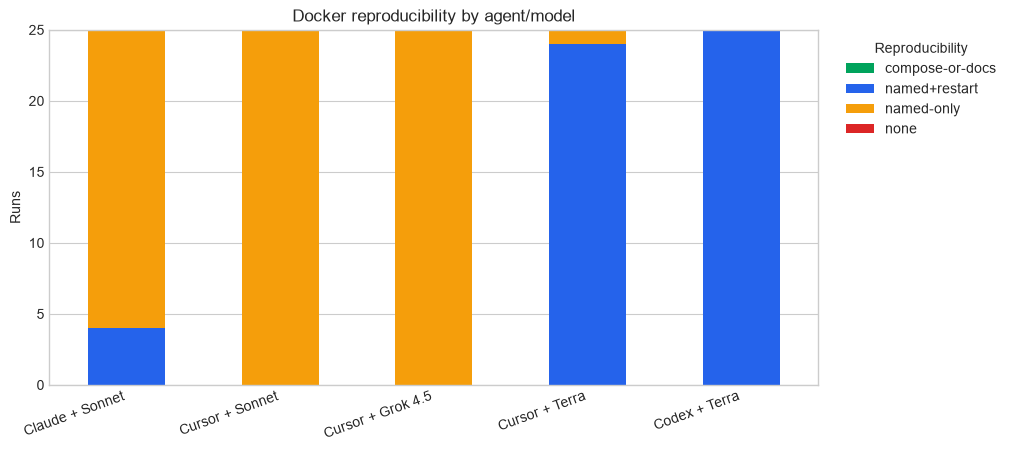

Reading: `--name` is session-local (`docker start` this box). A compose file is portable (`docker compose up` elsewhere). Collapsing them would hide agents that name containers constantly and never write compose.


In [159]:
if not READY_GRADED or docker_graded.empty:
    print("Waiting for graded Docker runs.")
else:
    REPRO_ORDER = ["compose-or-docs", "named+restart", "named-only", "none"]
    REPRO_COLORS = {
        "compose-or-docs": "#00A35C",
        "named+restart": "#2563EB",
        "named-only": "#F59E0B",
        "none": "#DC2626",
    }
    repro_sql = f"""
    SELECT
        run_id,
        countIf(
            positionCaseInsensitive(payload, 'docker-compose.yml') > 0
            OR positionCaseInsensitive(payload, 'docker-compose.yaml') > 0
            OR positionCaseInsensitive(payload, 'compose.yaml') > 0
            OR positionCaseInsensitive(payload, 'compose.yml') > 0
        ) AS compose_file_hits,
        countIf(positionCaseInsensitive(payload, 'Dockerfile') > 0) AS dockerfile_hits,
        countIf(positionCaseInsensitive(payload, 'README.md') > 0) AS readme_hits,
        countIf(
            positionCaseInsensitive(payload, 'docker run') > 0
            AND match(payload, '(?i)--name[[:space:]=]') > 0
        ) AS docker_name_hits,
        countIf(
            positionCaseInsensitive(payload, 'docker run') > 0
            AND (
                positionCaseInsensitive(payload, '--restart unless-stopped') > 0
                OR positionCaseInsensitive(payload, '--restart=unless-stopped') > 0
                OR positionCaseInsensitive(payload, '--restart always') > 0
                OR positionCaseInsensitive(payload, '--restart=always') > 0
            )
        ) AS restart_hits
    FROM events
    WHERE run_request_id IN ({REQUEST_SQL})
      AND kind = 'tool_call'
      AND prompt_id = 'docker'
    GROUP BY run_id
    """
    repro_flags = ax_query(repro_sql)
    docker_repro = docker_graded.drop(
        columns=[c for c in repro_flags.columns if c != "run_id" and c in docker_graded.columns],
        errors="ignore",
    ).merge(repro_flags, on="run_id", how="left")
    for column in [
        "compose_file_hits",
        "dockerfile_hits",
        "readme_hits",
        "docker_name_hits",
        "restart_hits",
    ]:
        docker_repro[column] = pd.to_numeric(docker_repro[column], errors="coerce").fillna(0)

    def classify_repro(row) -> str:
        if (
            int(row.get("compose_file_hits") or 0) > 0
            or int(row.get("dockerfile_hits") or 0) > 0
            or int(row.get("readme_hits") or 0) > 0
        ):
            return "compose-or-docs"
        named = int(row.get("docker_name_hits") or 0) > 0
        restart = int(row.get("restart_hits") or 0) > 0
        if named and restart:
            return "named+restart"
        if named:
            return "named-only"
        return "none"

    docker_repro["reproducibility"] = docker_repro.apply(classify_repro, axis=1)
    docker_repro["reproducibility"] = pd.Categorical(
        docker_repro["reproducibility"], categories=REPRO_ORDER, ordered=True
    )
    n_repro = len(docker_repro)
    print("Reproducibility class (Docker prompt):")
    repro_xtab = (
        pd.crosstab(docker_repro["extension"], docker_repro["reproducibility"])
        .reindex(EXTENSION_ORDER)
        .reindex(columns=REPRO_ORDER, fill_value=0)
    )
    display(repro_xtab)
    print(
        f"compose file: {int(docker_repro['compose_file_hits'].gt(0).sum())}/{n_repro}. "
        f"Dockerfile: {int(docker_repro['dockerfile_hits'].gt(0).sum())}/{n_repro}. "
        f"README.md: {int(docker_repro['readme_hits'].gt(0).sum())}/{n_repro}. "
        f"docker run --name: {int(docker_repro['docker_name_hits'].gt(0).sum())}/{n_repro}."
    )

    fig, ax = plt.subplots(figsize=(10, 4.4), constrained_layout=True)
    repro_xtab.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[REPRO_COLORS[c] for c in repro_xtab.columns],
    )
    ax.set_title("Docker reproducibility by agent/model")
    ax.set_xlabel("")
    ax.set_ylabel("Runs")
    ax.set_xticklabels([label_of(name) for name in repro_xtab.index], rotation=20, ha="right")
    ax.legend(title="Reproducibility", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

    print(
        "Reading: `--name` is session-local (`docker start` this box). A compose "
        "file is portable (`docker compose up` elsewhere). Collapsing them would "
        "hide agents that name containers constantly and never write compose."
    )


## Ephemeral + curl: how they provisioned

Same boolean-evidence style, method-specific codebook. The prompt hands
them the POST create curl. Watch whether they poll for `ACTIVE`, attempt
a MongoDB client, search docs, or whether the create JSON includes a
claim URL.

| Flag | Evidence |
| --- | --- |
| POST create | `ephemeralClusters:create` / `-X POST` |
| GET poll | `-X GET`, wait-for-ACTIVE, cluster status |
| Client attempt | `mongosh`, pymongo, `npx mongodb` |
| Client missing | "not installed" / "command not found" near a client |
| Docs/search | `docs.mongodb.com` / WebSearch / WebFetch |
| Claim URL | `claimUrl` in a tool payload (usually the create JSON, not a click) |


Ephemeral + curl graded runs: 125


,signal,runs,share_pct
0,POST create / ephemeralClusters,125,100.0
1,GET poll / ACTIVE,125,100.0
2,mongosh,118,94.4
3,pymongo,99,79.2
4,npx mongodb/mongosh,0,0.0
5,any MongoDB client,118,94.4
6,client missing language,95,76.0
7,docs / web search,4,3.2
8,curl without docs search,121,96.8
9,claimUrl in tool output (API JSON),125,100.0


,extension,n,post_create,get_poll,any_client,client_missing,docs_search,claim_url
0,claude-sonnet,25,25,25,25,22,1,25
1,cursor-sonnet,25,25,25,25,23,0,25
2,cursor-grok,25,25,25,25,17,1,25
3,cursor-terra,25,25,25,23,19,2,25
4,codex-terra,25,25,25,20,14,0,25


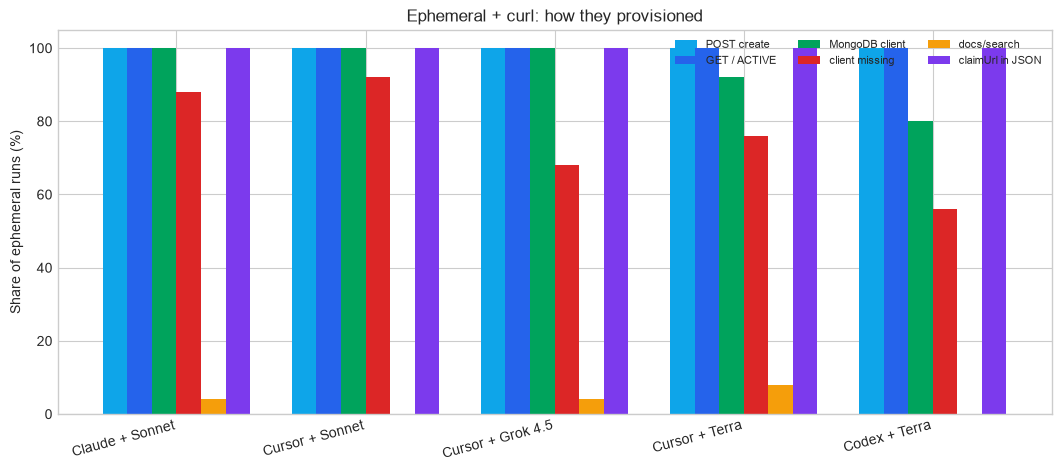

Reading: POST create is the handed curl; GET/ACTIVE is whether they waited (here both are 100%). `mongosh` is the usual client; npx is unused. Client-missing language fires on `command -v` misses that later recover, so it is not the same as the Codex connection-fail set. claimUrl in the create JSON is the API returning a claim link, not evidence the agent opened it. Docs/search is rare — they follow the prompt curl.


In [160]:
if not READY_GRADED:
    print("Waiting for graded runs.")
    eph_flags = pd.DataFrame()
else:
    eph_sql = f"""
    SELECT
        run_id,
        countIf(
            positionCaseInsensitive(payload, 'ephemeralClusters:create') > 0
            OR positionCaseInsensitive(payload, 'ephemeralClusters') > 0
               AND positionCaseInsensitive(payload, 'POST') > 0
        ) AS post_create_hits,
        countIf(
            positionCaseInsensitive(payload, '-X GET') > 0
            OR positionCaseInsensitive(payload, 'wait-for') > 0
            OR positionCaseInsensitive(payload, 'ACTIVE') > 0
        ) AS get_poll_hits,
        countIf(positionCaseInsensitive(payload, 'mongosh') > 0) AS mongosh_hits,
        countIf(positionCaseInsensitive(payload, 'pymongo') > 0) AS pymongo_hits,
        countIf(
            positionCaseInsensitive(payload, 'npx mongodb') > 0
            OR positionCaseInsensitive(payload, 'npx mongosh') > 0
            OR positionCaseInsensitive(payload, 'mongodb-cli') > 0
        ) AS npx_mongo_hits,
        countIf(
            positionCaseInsensitive(payload, 'not installed') > 0
            OR positionCaseInsensitive(payload, 'command not found') > 0
            OR positionCaseInsensitive(payload, 'No such file') > 0
        ) AS client_missing_hits,
        countIf(
            positionCaseInsensitive(payload, 'docs.mongodb.com') > 0
            OR positionCaseInsensitive(payload, 'mongodb.com/docs') > 0
            OR positionCaseInsensitive(payload, 'WebSearch') > 0
            OR positionCaseInsensitive(payload, 'web_search') > 0
            OR positionCaseInsensitive(payload, 'WebFetch') > 0
        ) AS docs_search_hits,
        countIf(
            positionCaseInsensitive(payload, 'claimUrl') > 0
            OR positionCaseInsensitive(payload, 'claim-url') > 0
            OR positionCaseInsensitive(payload, 'claim url') > 0
        ) AS claim_url_hits,
        countIf(positionCaseInsensitive(payload, 'curl') > 0) AS curl_hits
    FROM events
    WHERE run_request_id IN ({REQUEST_SQL})
      AND kind = 'tool_call'
      AND prompt_id = 'atlas-ephemeral-curl'
    GROUP BY run_id
    """
    eph_raw = ax_query(eph_sql)
    eph_flags = GRADED[GRADED["method"].eq("atlas-ephemeral-curl")].merge(
        eph_raw, on="run_id", how="left"
    )
    bool_hit_cols = [
        "post_create_hits",
        "get_poll_hits",
        "mongosh_hits",
        "pymongo_hits",
        "npx_mongo_hits",
        "client_missing_hits",
        "docs_search_hits",
        "claim_url_hits",
        "curl_hits",
    ]
    for column in bool_hit_cols:
        eph_flags[column] = pd.to_numeric(eph_flags[column], errors="coerce").fillna(0)
    eph_flags["any_client"] = (
        eph_flags["mongosh_hits"].gt(0)
        | eph_flags["pymongo_hits"].gt(0)
        | eph_flags["npx_mongo_hits"].gt(0)
    )
    eph_flags["curl_only"] = eph_flags["curl_hits"].gt(0) & ~eph_flags["docs_search_hits"].gt(0)
    n_eph = len(eph_flags)

    pooled = pd.DataFrame(
        {
            "signal": [
                "POST create / ephemeralClusters",
                "GET poll / ACTIVE",
                "mongosh",
                "pymongo",
                "npx mongodb/mongosh",
                "any MongoDB client",
                "client missing language",
                "docs / web search",
                "curl without docs search",
                "claimUrl in tool output (API JSON)",
            ],
            "runs": [
                int(eph_flags["post_create_hits"].gt(0).sum()),
                int(eph_flags["get_poll_hits"].gt(0).sum()),
                int(eph_flags["mongosh_hits"].gt(0).sum()),
                int(eph_flags["pymongo_hits"].gt(0).sum()),
                int(eph_flags["npx_mongo_hits"].gt(0).sum()),
                int(eph_flags["any_client"].sum()),
                int(eph_flags["client_missing_hits"].gt(0).sum()),
                int(eph_flags["docs_search_hits"].gt(0).sum()),
                int(eph_flags["curl_only"].sum()),
                int(eph_flags["claim_url_hits"].gt(0).sum()),
            ],
        }
    )
    pooled["share_pct"] = pooled["runs"] / n_eph * 100
    print(f"Ephemeral + curl graded runs: {n_eph}")
    display(pooled.round(1))

    ext_eph = (
        eph_flags.groupby("extension", observed=True)
        .agg(
            n=("run_id", "size"),
            post_create=("post_create_hits", lambda s: s.gt(0).sum()),
            get_poll=("get_poll_hits", lambda s: s.gt(0).sum()),
            any_client=("any_client", "sum"),
            client_missing=("client_missing_hits", lambda s: s.gt(0).sum()),
            docs_search=("docs_search_hits", lambda s: s.gt(0).sum()),
            claim_url=("claim_url_hits", lambda s: s.gt(0).sum()),
        )
        .reindex(EXTENSION_ORDER)
        .reset_index()
    )
    display(ext_eph)

    fig, ax = plt.subplots(figsize=(10.5, 4.6), constrained_layout=True)
    x = np.arange(len(EXTENSION_ORDER))
    width = 0.13
    series = [
        ("post_create", "POST create", "#0EA5E9"),
        ("get_poll", "GET / ACTIVE", "#2563EB"),
        ("any_client", "MongoDB client", "#00A35C"),
        ("client_missing", "client missing", "#DC2626"),
        ("docs_search", "docs/search", "#F59E0B"),
        ("claim_url", "claimUrl in JSON", "#7C3AED"),
    ]
    for i, (column, label, color) in enumerate(series):
        ax.bar(
            x + (i - 2.5) * width,
            ext_eph[column] / ext_eph["n"] * 100,
            width,
            label=label,
            color=color,
        )
    ax.set_xticks(x, [label_of(e) for e in EXTENSION_ORDER], rotation=15, ha="right")
    ax.set_ylim(0, 105)
    ax.set_ylabel("Share of ephemeral runs (%)")
    ax.set_title("Ephemeral + curl: how they provisioned")
    ax.legend(frameon=False, fontsize=8, ncol=3)
    plt.show()

    print(
        "Reading: POST create is the handed curl; GET/ACTIVE is whether they "
        "waited (here both are 100%). `mongosh` is the usual client; npx is unused. "
        "Client-missing language fires on `command -v` misses that later recover, "
        "so it is not the same as the Codex connection-fail set. claimUrl in the "
        "create JSON is the API returning a claim link, not evidence the agent "
        "opened it. Docs/search is rare — they follow the prompt curl."
    )


## Ephemeral: how they get a MongoDB client

`mongosh` is **not** in the 514 base image. The previous cell counted any
payload that mentions `mongosh` (including `command -v mongosh`). This
cell classifies the **command** they actually typed (never printed —
commands can contain URIs).

| Path | Evidence |
| --- | --- |
| Probe only | `which mongosh` / `command -v mongosh` |
| Download mongosh | `curl`/`wget` of mongosh or `downloads.mongodb.com` |
| apt mongosh | `apt install` + `mongosh` / `mongodb-mongosh` |
| Run mongosh | a `mongosh ` invocation that is not a probe |
| npx mongosh | `npx … mongosh` |
| pip pymongo | `pip install pymongo` |
| Python client | `python` + `MongoClient` / `pymongo` |
| npm mongodb | `npm install mongodb` |
| Node client | `node` + `MongoClient` |

The interesting question: after the probe fails, do they **download the
shell**, or **install a language driver**?


Ephemeral client-install commands (n=125):


,signal,runs,share_pct
0,probe which/command -v mongosh,110,88.0
1,run mongosh (not a probe),9,7.2
2,curl/wget mongosh,1,0.8
3,apt install mongosh,0,0.0
4,npx mongosh,10,8.0
5,pip install pymongo,73,58.4
6,python MongoClient/pymongo,99,79.2
7,npm install mongodb,93,74.4
8,node MongoClient,62,49.6


Primary client path (mutually exclusive; download/run mongosh beats drivers):


client_path,downloaded mongosh,ran mongosh,npx mongosh,python + node drivers,python/pymongo,node mongodb driver,probed mongosh only,no client
extension,,,,,,,,
claude-sonnet,0,0,0,9,16,0,0,0
cursor-sonnet,0,0,0,2,23,0,0,0
cursor-grok,0,0,0,17,2,6,0,0
cursor-terra,1,8,1,9,2,2,0,2
codex-terra,0,0,2,8,4,2,4,5


All-three pass rate by client path:


,client_path,n,passes,rate
0,downloaded mongosh,1,1,1.000
1,ran mongosh,8,8,1.000
2,npx mongosh,3,3,1.000
3,python + node drivers,45,45,1.000
4,python/pymongo,47,42,0.894
5,node mongodb driver,10,9,0.900
6,probed mongosh only,4,1,0.250
7,no client,7,0,0.000


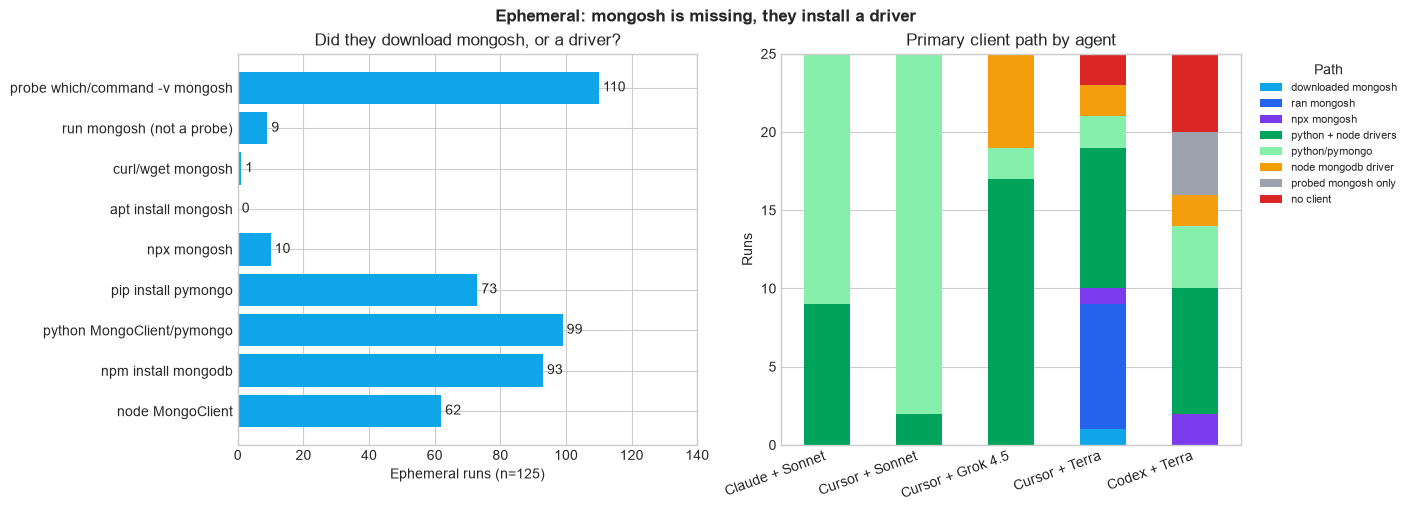

Reading: they are not downloading mongosh (1/125 curl/apt). 110/125 probe `which mongosh`; only 9/125 actually invoke mongosh. The recovery path is a language driver: pip pymongo 73/125 and python MongoClient 99/125; npm mongodb 93/125. The shell is missing from the sandbox; they do not fetch the official mongosh tarball — they install pymongo or the Node driver and ping with that.


In [161]:
if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    CLIENT_PATH_ORDER = [
        "downloaded mongosh",
        "ran mongosh",
        "npx mongosh",
        "python + node drivers",
        "python/pymongo",
        "node mongodb driver",
        "probed mongosh only",
        "no client",
    ]
    CLIENT_PATH_COLORS = {
        "downloaded mongosh": "#0EA5E9",
        "ran mongosh": "#2563EB",
        "npx mongosh": "#7C3AED",
        "python + node drivers": "#00A35C",
        "python/pymongo": "#86EFAC",
        "node mongodb driver": "#F59E0B",
        "probed mongosh only": "#9CA3AF",
        "no client": "#DC2626",
    }
    eph_client_sql = f"""
    WITH calls AS (
      SELECT
        run_id,
        resolved_extend_id,
        argMax(JSONExtractString(payload, 'input', 'command'),
               length(JSONExtractString(payload, 'input', 'command'))) AS command
      FROM events
      WHERE run_request_id IN ({REQUEST_SQL})
        AND prompt_id = 'atlas-ephemeral-curl'
        AND kind = 'tool_call'
        AND coalesce(assertion_role, 'primary') = 'primary'
      GROUP BY run_id, resolved_extend_id, tool_call_id
    )
    SELECT
      run_id,
      resolved_extend_id,
      max(match(command, '(?i)(which |command -v |type )[[:space:]]*mongosh')) AS probe_mongosh,
      max(
        match(command, '(?i)(^|[;&|\\\\n])[[:space:]]*mongosh[[:space:]]')
        AND NOT match(command, '(?i)(which |command -v |type )')
      ) AS run_mongosh,
      max(
        match(command, '(?i)(curl|wget)')
        AND match(command, '(?i)mongosh|downloads.mongodb.com')
      ) AS download_mongosh,
      max(
        match(command, '(?i)apt(-get)?[[:space:]]+install')
        AND match(command, '(?i)mongosh')
      ) AS apt_mongosh,
      max(
        match(command, '(?i)npx[[:space:]]')
        AND match(command, '(?i)mongosh')
      ) AS npx_mongosh,
      max(
        match(command, '(?i)pip3?[[:space:]]+install')
        AND match(command, '(?i)pymongo')
      ) AS pip_pymongo,
      max(
        match(command, '(?i)python3?')
        AND match(command, '(?i)MongoClient|pymongo')
      ) AS python_client,
      max(
        match(command, '(?i)npm[[:space:]]+i(nstall)?')
        AND match(command, '(?i)mongodb')
      ) AS npm_mongodb,
      max(
        match(command, '(?i)node')
        AND match(command, '(?i)MongoClient')
      ) AS node_client
    FROM calls
    GROUP BY run_id, resolved_extend_id
    """
    eph_client = assign_extension(ax_query(eph_client_sql, limit=10_000))
    eph_client = GRADED[GRADED["method"].eq("atlas-ephemeral-curl")][
        ["run_id", "extension", "passed"]
    ].merge(eph_client.drop(columns=["extension"], errors="ignore"), on="run_id", how="left")
    flag_cols = [
        "probe_mongosh",
        "run_mongosh",
        "download_mongosh",
        "apt_mongosh",
        "npx_mongosh",
        "pip_pymongo",
        "python_client",
        "npm_mongodb",
        "node_client",
    ]
    for column in flag_cols:
        eph_client[column] = pd.to_numeric(eph_client[column], errors="coerce").fillna(0).astype(bool)
    n_eph = len(eph_client)

    def classify_client_path(row) -> str:
        if row["download_mongosh"] or row["apt_mongosh"]:
            return "downloaded mongosh"
        if row["run_mongosh"]:
            return "ran mongosh"
        if row["npx_mongosh"] and not row["python_client"] and not row["node_client"]:
            return "npx mongosh"
        if row["python_client"] and row["node_client"]:
            return "python + node drivers"
        if row["python_client"]:
            return "python/pymongo"
        if row["node_client"]:
            return "node mongodb driver"
        if row["npx_mongosh"]:
            return "npx mongosh"
        if row["probe_mongosh"]:
            return "probed mongosh only"
        return "no client"

    eph_client["client_path"] = eph_client.apply(classify_client_path, axis=1)
    eph_client["client_path"] = pd.Categorical(
        eph_client["client_path"], categories=CLIENT_PATH_ORDER, ordered=True
    )

    pooled = pd.DataFrame(
        {
            "signal": [
                "probe which/command -v mongosh",
                "run mongosh (not a probe)",
                "curl/wget mongosh",
                "apt install mongosh",
                "npx mongosh",
                "pip install pymongo",
                "python MongoClient/pymongo",
                "npm install mongodb",
                "node MongoClient",
            ],
            "runs": [
                int(eph_client["probe_mongosh"].sum()),
                int(eph_client["run_mongosh"].sum()),
                int(eph_client["download_mongosh"].sum()),
                int(eph_client["apt_mongosh"].sum()),
                int(eph_client["npx_mongosh"].sum()),
                int(eph_client["pip_pymongo"].sum()),
                int(eph_client["python_client"].sum()),
                int(eph_client["npm_mongodb"].sum()),
                int(eph_client["node_client"].sum()),
            ],
        }
    )
    pooled["share_pct"] = pooled["runs"] / n_eph * 100
    print(f"Ephemeral client-install commands (n={n_eph}):")
    display(pooled.round(1))

    print("Primary client path (mutually exclusive; download/run mongosh beats drivers):")
    path_xtab = (
        pd.crosstab(eph_client["extension"], eph_client["client_path"])
        .reindex(EXTENSION_ORDER)
        .reindex(columns=CLIENT_PATH_ORDER, fill_value=0)
    )
    display(path_xtab)

    print("All-three pass rate by client path:")
    path_pass = (
        eph_client.groupby("client_path", observed=True)
        .agg(n=("run_id", "size"), passes=("passed", "sum"))
        .reindex(CLIENT_PATH_ORDER)
        .dropna(how="all")
        .reset_index()
    )
    path_pass["n"] = path_pass["n"].fillna(0).astype(int)
    path_pass["passes"] = path_pass["passes"].fillna(0).astype(int)
    path_pass["rate"] = path_pass["passes"] / path_pass["n"].replace(0, np.nan)
    display(path_pass.round(3))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    axes[0].barh(pooled["signal"][::-1], pooled["runs"][::-1], color="#0EA5E9")
    axes[0].set_xlabel(f"Ephemeral runs (n={n_eph})")
    axes[0].set_title("Did they download mongosh, or a driver?")
    for y, value in enumerate(pooled["runs"][::-1]):
        axes[0].text(value + 1.2, y, str(int(value)), va="center")
    axes[0].set_xlim(0, n_eph + 15)

    present_cols = [c for c in CLIENT_PATH_ORDER if int(path_xtab[c].sum()) > 0]
    path_xtab[present_cols].plot(
        kind="bar",
        stacked=True,
        ax=axes[1],
        color=[CLIENT_PATH_COLORS[c] for c in present_cols],
    )
    axes[1].set_title("Primary client path by agent")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Runs")
    axes[1].set_xticklabels([label_of(name) for name in path_xtab.index], rotation=20, ha="right")
    axes[1].legend(title="Path", frameon=False, fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.suptitle("Ephemeral: mongosh is missing, they install a driver", fontweight="bold")
    plt.show()

    n_download = int((eph_client["download_mongosh"] | eph_client["apt_mongosh"]).sum())
    n_run = int(eph_client["run_mongosh"].sum())
    n_pip = int(eph_client["pip_pymongo"].sum())
    n_py = int(eph_client["python_client"].sum())
    n_npm = int(eph_client["npm_mongodb"].sum())
    print(
        f"Reading: they are not downloading mongosh ({n_download}/{n_eph} curl/apt). "
        f"{int(eph_client['probe_mongosh'].sum())}/{n_eph} probe `which mongosh`; "
        f"only {n_run}/{n_eph} actually invoke mongosh. The recovery path is a "
        f"language driver: pip pymongo {n_pip}/{n_eph} and python MongoClient "
        f"{n_py}/{n_eph}; npm mongodb {n_npm}/{n_eph}. The shell is missing from "
        "the sandbox; they do not fetch the official mongosh tarball — they "
        "install pymongo or the Node driver and ping with that."
    )


## Atlas CLI local: how they provisioned

The prompt asks for an Atlas **local** deployment. Agents install the CLI
themselves, then run the local recipe. Searching the whole tool-call JSON
mixes argv with CLI stdout (the package name in a GitHub URL, `--force` in
help text, the local image in Docker pull logs). This cell classifies the
**command** they typed, plus three **output-only** signals (payload has the
string, command fields do not). Chart outputs never print commands;
representative templates are below.

| Step | Path | Evidence |
| --- | --- | --- |
| 1. Get the CLI | apt CLI | `apt-get install` / `apt install` and `mongodb-atlas-cli` / `mongodb-atlas` in the same command |
|  | curl tarball | `curl`/`wget` and atlas-cli in the same command (GitHub releases, install.sh, tarball, or CLI binary URL) |
|  | npx | `npx` and `atlas` |
|  | other | none of the above |
| 2. Local recipe | deployments setup | typed `atlas deployments setup` |
|  | `--type local` | typed on a command that also has `setup` (optional; CLI can default to local) |
|  | `--force` | typed on a command that also has `atlas deployments` |
| 3. CLI vs typed | local image | `mongodb-atlas-local` typed vs output-only |
|  | atlas auth | `atlas auth` / `auth login` typed vs output-only (CLI nag) |
|  | docker run | typed vs output-only (CLI log) |

Install path is mutually exclusive (first match). Recipe flags and typed vs
output-only are independent booleans.

**Apt command (31/125).** First-match on `apt` / `apt-get` + `install` +
`mongodb-atlas-cli` (or `mongodb-atlas`) in the same command. What they type:

```
sudo apt-get install -y mongodb-atlas-cli
```

Sometimes `mongodb-mongosh` on the same line. A few add the Atlas CLI apt repo
first (`pgp.mongodb.com/atlascli.asc`, then
`deb … repo.mongodb.com/apt/debian bookworm/mongodb-atlas-cli/1.0 main`). Some
apt-classified runs are actually `sudo apt-get install -y /tmp/mongodb-atlas-cli.deb`
after curling a `.deb` — the matcher still counts those as apt.

**Curl command (92/125).** First-match on `curl` / `wget` plus `atlas-cli` /
`mongodb-atlas-cli` in the same command. Typical:

```
curl -fsSL https://fastdl.mongodb.org/mongocli/mongodb-atlas-cli_1.58.1_linux_x86_64.tar.gz -o … && tar -xzf …
```

or the same basename as a `.deb`, then `dpkg -i`. Same filename also from GitHub
`mongodb/mongodb-atlas-cli` releases. Modal pin is **1.58.1**.

**Other (2/125) — chart unchanged.** One Cursor+Terra, one Codex+Terra.

- **Cursor+Terra:** curled
  `fastdl.mongodb.org/mongocli/atlascli_1.58.1_linux_x86_64.tar.gz` (filename
  `atlascli`, no hyphen — the matcher wants `atlas-cli`) and then provisioned
  with `docker run mongodb/atlas:latest local setup`.
- **Codex+Terra:** never installed a host CLI. HEAD-requested
  `fastdl.mongodb.org/mongocli/mongocli_2.0.0_linux_x86_64.tgz`, then used the
  image as the CLI: `docker run --entrypoint atlas mongodb/atlas:latest … local setup`.


Atlas CLI local graded runs: 125
Non-empty input.command on 125/125 runs (203 / 1683 tool_call_ids had empty command after argMax).
Chart 1 — how they got the CLI binary (command only, first match):


,path,runs,share_pct
0,apt CLI,31,24.8
1,curl tarball,92,73.6
2,npx,0,0.0
3,other,2,1.6


install_path,apt CLI,curl tarball,npx,other
extension,,,,
claude-sonnet,5,20,0,0
cursor-sonnet,6,19,0,0
cursor-grok,17,8,0,0
cursor-terra,3,21,0,1
codex-terra,0,24,0,1


Chart 2 — did they type the local recipe?


,signal,runs,share_pct
0,typed atlas deployments setup,92,73.6
1,typed --type local on a setup command,32,25.6
2,typed --force on atlas deployments,31,24.8


,extension,n,typed_setup,typed_type_local,typed_force
0,claude-sonnet,25,24,17,17
1,cursor-sonnet,25,25,13,13
2,cursor-grok,25,13,0,0
3,cursor-terra,25,5,1,0
4,codex-terra,25,25,1,1


Chart 3 — typed vs output-only (payload has it, command fields do not):


,signal,typed,output_only,in_payload,typed_pct,output_only_pct
0,mongodb-atlas-local,5,123,123,4.0,98.4
1,atlas auth / auth login,1,22,23,0.8,17.6
2,docker run,7,10,16,5.6,8.0


,extension,n,mongodb-atlas-local typed,mongodb-atlas-local output-only,atlas auth / auth login typed,atlas auth / auth login output-only,docker run typed,docker run output-only
0,claude-sonnet,25,1,25,0,0,1,0
1,cursor-sonnet,25,2,25,0,3,3,0
2,cursor-grok,25,0,23,0,10,0,4
3,cursor-terra,25,0,25,1,8,1,5
4,codex-terra,25,2,25,0,1,2,1


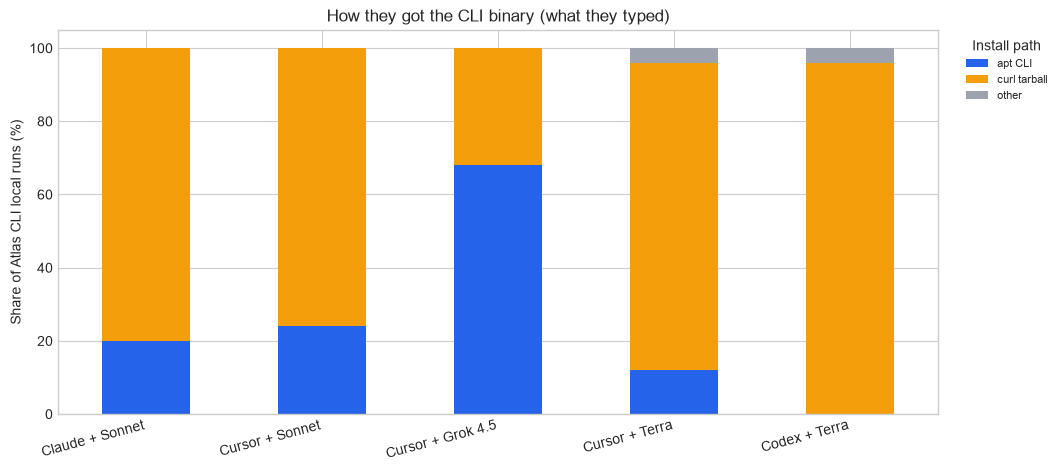

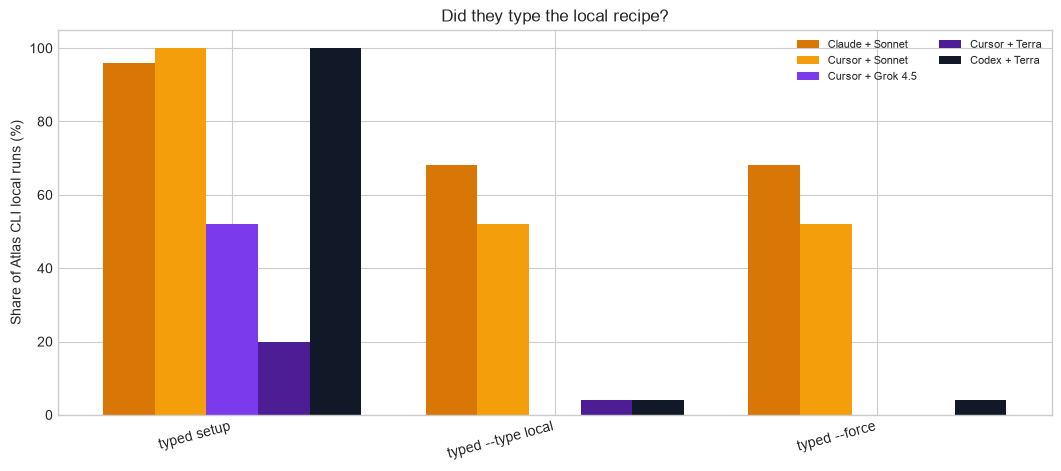

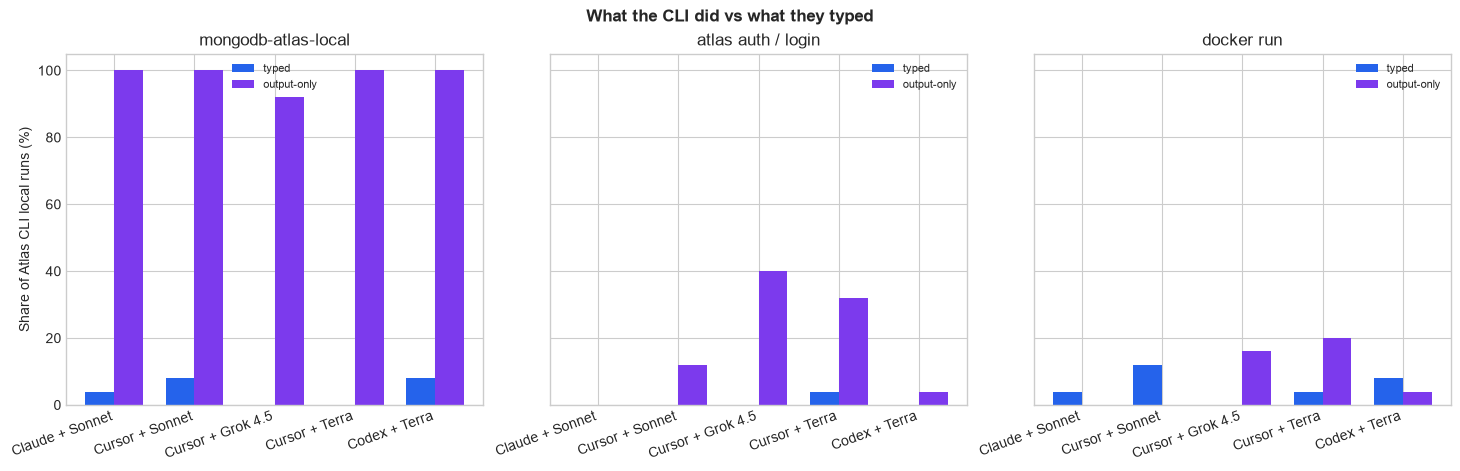

Reading: the CLI binary is a curl download (92/125), not apt (31/125); npx 0/125, other 2/125. Grok is the apt cell (17/25). They type `atlas deployments setup` on 92/125; Grok 13/25 and Cursor+Terra 5/25 type it less often than Sonnet/Codex. `--type local` is optional (32/125) and `--force` on the recipe command is 31/125, not every run. The local image is almost never typed (5/125) — it is CLI stdout (123/125). Typed `atlas auth` is 1/125; the rest of the old auth count is nag text (22/125). Typed `docker run` 7/125 vs output-only 10/125.


In [6]:
if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    INSTALL_PATH_ORDER = ["apt CLI", "curl tarball", "npx", "other"]
    INSTALL_PATH_COLORS = {
        "apt CLI": "#2563EB",
        "curl tarball": "#F59E0B",
        "npx": "#7C3AED",
        "other": "#9CA3AF",
    }
    atlas_sql = f"""
    WITH calls AS (
      SELECT
        run_id,
        resolved_extend_id,
        argMax(JSONExtractString(payload, 'input', 'command'),
               length(JSONExtractString(payload, 'input', 'command'))) AS command,
        max(positionCaseInsensitive(payload, 'mongodb-atlas-local') > 0) AS pay_image,
        max(
            positionCaseInsensitive(payload, 'atlas auth') > 0
            OR positionCaseInsensitive(payload, 'auth login') > 0
        ) AS pay_auth,
        max(positionCaseInsensitive(payload, 'docker run') > 0) AS pay_docker
      FROM events
      WHERE run_request_id IN ({REQUEST_SQL})
        AND prompt_id = 'atlas-cli-local'
        AND kind = 'tool_call'
        AND coalesce(assertion_role, 'primary') = 'primary'
      GROUP BY run_id, resolved_extend_id, tool_call_id
    )
    SELECT
      run_id,
      resolved_extend_id,
      max(length(command) > 0) AS has_command,
      count() AS n_tool_calls,
      countIf(length(command) = 0) AS n_empty_command_calls,
      max(
        match(command, '(?i)apt(-get)?')
        AND match(command, '(?i)[[:space:]]install[[:space:]]')
        AND match(command, '(?i)mongodb-atlas-cli|mongodb-atlas')
      ) AS apt_cli,
      max(
        match(command, '(?i)(curl|wget)')
        AND match(command, '(?i)atlas-cli|mongodb-atlas-cli')
      ) AS curl_tarball,
      max(
        match(command, '(?i)\\\\bnpx\\\\b')
        AND match(command, '(?i)atlas')
      ) AS npx_atlas,
      max(match(command, '(?i)atlas[[:space:]]+deployments[[:space:]]+setup')) AS typed_setup,
      max(
        match(command, '(?i)--type[=[:space:]]+local')
        AND match(command, '(?i)setup')
      ) AS typed_type_local,
      max(
        match(command, '(?i)--force')
        AND match(command, '(?i)atlas[[:space:]]+deployments')
      ) AS typed_force,
      max(positionCaseInsensitive(command, 'mongodb-atlas-local') > 0) AS typed_image,
      max(
        pay_image AND positionCaseInsensitive(command, 'mongodb-atlas-local') = 0
      ) AS output_image,
      max(
        positionCaseInsensitive(command, 'atlas auth') > 0
        OR positionCaseInsensitive(command, 'auth login') > 0
      ) AS typed_auth,
      max(
        pay_auth
        AND positionCaseInsensitive(command, 'atlas auth') = 0
        AND positionCaseInsensitive(command, 'auth login') = 0
      ) AS output_auth,
      max(match(command, '(?i)docker[[:space:]]+run')) AS typed_docker,
      max(pay_docker AND NOT match(command, '(?i)docker[[:space:]]+run')) AS output_docker
    FROM calls
    GROUP BY run_id, resolved_extend_id
    """
    atlas_raw = assign_extension(ax_query(atlas_sql, limit=10_000))
    atlas = GRADED[GRADED["method"].eq("atlas-cli-local")][
        ["run_id", "extension"]
    ].merge(atlas_raw.drop(columns=["extension"], errors="ignore"), on="run_id", how="left")
    flag_cols = [
        "has_command",
        "apt_cli",
        "curl_tarball",
        "npx_atlas",
        "typed_setup",
        "typed_type_local",
        "typed_force",
        "typed_image",
        "output_image",
        "typed_auth",
        "output_auth",
        "typed_docker",
        "output_docker",
    ]
    for column in flag_cols:
        atlas[column] = pd.to_numeric(atlas[column], errors="coerce").fillna(0).astype(bool)
    atlas["n_tool_calls"] = pd.to_numeric(atlas["n_tool_calls"], errors="coerce").fillna(0)
    atlas["n_empty_command_calls"] = pd.to_numeric(
        atlas["n_empty_command_calls"], errors="coerce"
    ).fillna(0)
    n_atlas = len(atlas)

    def classify_install(row) -> str:
        if row["apt_cli"]:
            return "apt CLI"
        if row["curl_tarball"]:
            return "curl tarball"
        if row["npx_atlas"]:
            return "npx"
        return "other"

    atlas["install_path"] = atlas.apply(classify_install, axis=1)
    atlas["install_path"] = pd.Categorical(
        atlas["install_path"], categories=INSTALL_PATH_ORDER, ordered=True
    )

    def k(column: str) -> int:
        return int(atlas[column].sum())

    print(f"Atlas CLI local graded runs: {n_atlas}")
    print(
        f"Non-empty input.command on {int(atlas['has_command'].sum())}/{n_atlas} runs "
        f"({int(atlas['n_empty_command_calls'].sum())} / "
        f"{int(atlas['n_tool_calls'].sum())} tool_call_ids had empty command after argMax)."
    )

    print("Chart 1 — how they got the CLI binary (command only, first match):")
    install_pooled = (
        atlas["install_path"]
        .value_counts()
        .reindex(INSTALL_PATH_ORDER, fill_value=0)
        .rename_axis("path")
        .reset_index(name="runs")
    )
    install_pooled["share_pct"] = install_pooled["runs"] / n_atlas * 100
    display(install_pooled.round(1))
    install_xtab = (
        pd.crosstab(atlas["extension"], atlas["install_path"])
        .reindex(EXTENSION_ORDER)
        .reindex(columns=INSTALL_PATH_ORDER, fill_value=0)
    )
    display(install_xtab)

    print("Chart 2 — did they type the local recipe?")
    recipe_pooled = pd.DataFrame(
        {
            "signal": [
                "typed atlas deployments setup",
                "typed --type local on a setup command",
                "typed --force on atlas deployments",
            ],
            "runs": [k("typed_setup"), k("typed_type_local"), k("typed_force")],
        }
    )
    recipe_pooled["share_pct"] = recipe_pooled["runs"] / n_atlas * 100
    display(recipe_pooled.round(1))
    recipe_ext = (
        atlas.groupby("extension", observed=True)
        .agg(
            n=("run_id", "size"),
            typed_setup=("typed_setup", "sum"),
            typed_type_local=("typed_type_local", "sum"),
            typed_force=("typed_force", "sum"),
        )
        .reindex(EXTENSION_ORDER)
        .reset_index()
    )
    display(recipe_ext)

    print("Chart 3 — typed vs output-only (payload has it, command fields do not):")
    io_rows = [
        ("mongodb-atlas-local", "typed_image", "output_image"),
        ("atlas auth / auth login", "typed_auth", "output_auth"),
        ("docker run", "typed_docker", "output_docker"),
    ]
    io_pooled = pd.DataFrame(
        {
            "signal": [label for label, _, _ in io_rows],
            "typed": [k(typed) for _, typed, _ in io_rows],
            "output_only": [k(output) for _, _, output in io_rows],
        }
    )
    io_pooled["in_payload"] = [
        int((atlas[typed] | atlas[output]).sum()) for _, typed, output in io_rows
    ]
    io_pooled["typed_pct"] = io_pooled["typed"] / n_atlas * 100
    io_pooled["output_only_pct"] = io_pooled["output_only"] / n_atlas * 100
    display(io_pooled.round(1))

    io_ext_rows = []
    for extension in EXTENSION_ORDER:
        sub = atlas[atlas["extension"].eq(extension)]
        n_ext = len(sub)
        row = {"extension": extension, "n": n_ext}
        for label, typed, output in io_rows:
            row[f"{label} typed"] = int(sub[typed].sum())
            row[f"{label} output-only"] = int(sub[output].sum())
        io_ext_rows.append(row)
    display(pd.DataFrame(io_ext_rows))

    fig1, ax1 = plt.subplots(figsize=(10.5, 4.6), constrained_layout=True)
    install_share = install_xtab.div(install_xtab.sum(axis=1).replace(0, np.nan), axis=0) * 100
    plot_cols = [c for c in INSTALL_PATH_ORDER if int(install_xtab[c].sum()) > 0]
    install_share[plot_cols].plot(
        kind="bar",
        stacked=True,
        ax=ax1,
        color=[INSTALL_PATH_COLORS[name] for name in plot_cols],
    )
    ax1.set_ylim(0, 105)
    ax1.set_ylabel("Share of Atlas CLI local runs (%)")
    ax1.set_xlabel("")
    ax1.set_xticklabels([label_of(name) for name in install_share.index], rotation=15, ha="right")
    ax1.set_title("How they got the CLI binary (what they typed)")
    ax1.legend(title="Install path", frameon=False, fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

    recipe_long = []
    for signal, column in [
        ("typed setup", "typed_setup"),
        ("typed --type local", "typed_type_local"),
        ("typed --force", "typed_force"),
    ]:
        for extension in EXTENSION_ORDER:
            sub = atlas[atlas["extension"].eq(extension)]
            recipe_long.append(
                {
                    "extension": extension,
                    "signal": signal,
                    "rate_pct": (sub[column].mean() * 100) if len(sub) else np.nan,
                }
            )
    fig2, ax2 = plt.subplots(figsize=(10.5, 4.6), constrained_layout=True)
    grouped_bars(
        ax2,
        pd.DataFrame(recipe_long),
        "extension",
        "rate_pct",
        "Did they type the local recipe?",
        "Share of Atlas CLI local runs (%)",
        percent=True,
        index_col="signal",
        index_order=["typed setup", "typed --type local", "typed --force"],
        xlabel="",
    )
    plt.show()

    fig3, axes = plt.subplots(1, 3, figsize=(14.5, 4.6), constrained_layout=True, sharey=True)
    panel_specs = [
        ("typed_image", "output_image", "mongodb-atlas-local"),
        ("typed_auth", "output_auth", "atlas auth / login"),
        ("typed_docker", "output_docker", "docker run"),
    ]
    x = np.arange(len(EXTENSION_ORDER))
    width = 0.36
    n_by_ext = atlas.groupby("extension", observed=True).size().reindex(EXTENSION_ORDER)
    for ax, (typed, output, title) in zip(axes, panel_specs):
        typed_pct = (
            atlas.groupby("extension", observed=True)[typed].sum().reindex(EXTENSION_ORDER)
            / n_by_ext
            * 100
        )
        output_pct = (
            atlas.groupby("extension", observed=True)[output].sum().reindex(EXTENSION_ORDER)
            / n_by_ext
            * 100
        )
        ax.bar(x - width / 2, typed_pct.fillna(0), width, label="typed", color="#2563EB")
        ax.bar(x + width / 2, output_pct.fillna(0), width, label="output-only", color="#7C3AED")
        ax.set_xticks(x, [label_of(name) for name in EXTENSION_ORDER], rotation=20, ha="right")
        ax.set_ylim(0, 105)
        ax.set_title(title)
        ax.legend(frameon=False, fontsize=8)
    axes[0].set_ylabel("Share of Atlas CLI local runs (%)")
    fig3.suptitle("What the CLI did vs what they typed", fontweight="bold")
    plt.show()

    n_apt = int((atlas["install_path"] == "apt CLI").sum())
    n_curl = int((atlas["install_path"] == "curl tarball").sum())
    n_npx = int((atlas["install_path"] == "npx").sum())
    n_other = int((atlas["install_path"] == "other").sum())
    apt_by = (
        atlas.assign(_apt=atlas["install_path"].eq("apt CLI"))
        .groupby("extension", observed=True)["_apt"]
        .sum()
        .reindex(EXTENSION_ORDER)
    )
    grok_apt = int(apt_by.get("cursor-grok", 0))
    setup_by = (
        atlas.groupby("extension", observed=True)["typed_setup"].sum().reindex(EXTENSION_ORDER)
    )
    grok_setup = int(setup_by.get("cursor-grok", 0))
    terra_setup = int(setup_by.get("cursor-terra", 0))
    print(
        f"Reading: the CLI binary is a curl download ({n_curl}/{n_atlas}), not apt "
        f"({n_apt}/{n_atlas}); npx {n_npx}/{n_atlas}, other {n_other}/{n_atlas}. "
        f"Grok is the apt cell ({grok_apt}/25). They type `atlas deployments setup` on "
        f"{k('typed_setup')}/{n_atlas}; Grok {grok_setup}/25 and Cursor+Terra "
        f"{terra_setup}/25 type it less often than Sonnet/Codex. "
        f"`--type local` is optional ({k('typed_type_local')}/{n_atlas}) and "
        f"`--force` on the recipe command is {k('typed_force')}/{n_atlas}, not every run. "
        f"The local image is almost never typed ({k('typed_image')}/{n_atlas}) — it is "
        f"CLI stdout ({k('output_image')}/{n_atlas}). Typed `atlas auth` is "
        f"{k('typed_auth')}/{n_atlas}; the rest of the old auth count is nag text "
        f"({k('output_auth')}/{n_atlas}). Typed `docker run` {k('typed_docker')}/{n_atlas} "
        f"vs output-only {k('output_docker')}/{n_atlas}."
    )


## apt: how they provisioned

The prompt asks for the native OS package manager. MongoDB is not in
default Debian repos in a usable way, so the documented path is: add the
MongoDB apt repo, install `mongodb-org`, start `mongod`. Flags below are
**command-only**. Commands are never printed.

| Step | Path | Evidence (typed command) |
| --- | --- | --- |
| Install | MongoDB apt repo + mongodb-org | `repo.mongodb.org` / `mongodb-org.list` **and** `apt install` of `mongodb-org` |
| Install | mongodb-org without repo setup | `apt install` `mongodb-org`, no repo/list file in any command |
| Install | distro `mongodb` package | `apt install mongodb` / `mongodb-server` without `mongodb-org` |
| Install | other | none of the above (docker, source, already present) |
| Start | systemd | `systemctl start` / `service mongod start` / `systemctl enable --now` |
| Start | manual daemon | `mongod --fork` and/or `--dbpath` |
| Config | bookworm | expected Debian codename in the sandbox |
| Config | trixie | wrong-codename footgun |
| Config | bindIp | `bindIp` / `bind_ip` / `0.0.0.0` |
| Config | auth | `authorization: enabled` / `security.authorization` / `createUser` / `--auth` |

GPG (`apt-key` / `gpg` / `signed-by`) is a boolean footnote, not a
competing install bar. Chart 1 is mutually exclusive first-match; chart 2
shows both start recipes (overlap is the fallback). Config (bookworm /
trixie / bindIp / auth) is command-only counts under chart 2, not a
third figure — output-only is apt / os-release / `cat mongod.conf`
printing defaults.


apt graded runs: 125 (non-empty input.command on 125/125)
Chart 1 — install path (command only, mutually exclusive):


,path,runs,share_pct
0,MongoDB apt repo + mongodb-org,125,100.0
1,mongodb-org without repo setup,0,0.0
2,distro mongodb package,0,0.0
3,other,0,0.0


install_path,MongoDB apt repo + mongodb-org,mongodb-org without repo setup,distro mongodb package,other
extension,,,,
claude-sonnet,25,0,0,0
cursor-sonnet,25,0,0,0
cursor-grok,25,0,0,0
cursor-terra,25,0,0,0
codex-terra,25,0,0,0


GPG footnote (apt-key / gpg / signed-by in command): 124/125


,extension,n,typed_gpg
0,claude-sonnet,25,25
1,cursor-sonnet,25,25
2,cursor-grok,25,25
3,cursor-terra,25,25
4,codex-terra,25,24


Chart 2 — start recipe (command only; bars are not exclusive):


,signal,runs,share_pct
0,systemd start / enable --now,105,84.0
1,mongod --fork / --dbpath,44,35.2
2,typed both,25,20.0


,extension,n,systemd,fork,both
0,claude-sonnet,25,19,6,0
1,cursor-sonnet,25,22,4,1
2,cursor-grok,25,25,3,3
3,cursor-terra,25,17,17,10
4,codex-terra,25,22,14,11


Config (command only, not a third chart): bookworm typed 125/125; trixie typed 20/125; bindIp typed 24/125; auth / createUser typed 0/125.


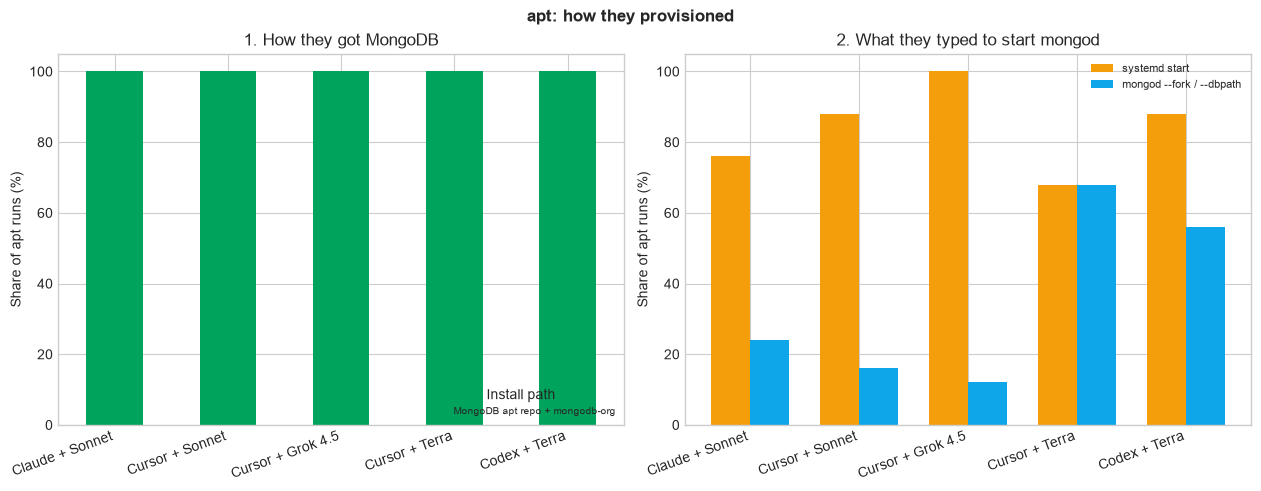

Reading: documented path is repo + mongodb-org (125/125); mongodb-org without repo in command 0/125; distro mongodb 0/125; other 0/125. GPG in command 124/125. They start with systemd 105/125 and/or mongod --fork/--dbpath 44/125 (overlap 25/125; Terra 17, Codex 14). bookworm typed 125/125; trixie typed 20/125; bindIp typed 24/125; auth / createUser typed 0/125. 0/125 graded runs have empty input.command on every captured tool_call.


In [6]:
if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    INSTALL_PATH_ORDER = [
        "MongoDB apt repo + mongodb-org",
        "mongodb-org without repo setup",
        "distro mongodb package",
        "other",
    ]
    INSTALL_PATH_COLORS = {
        "MongoDB apt repo + mongodb-org": "#00A35C",
        "mongodb-org without repo setup": "#F59E0B",
        "distro mongodb package": "#8C8C8C",
        "other": "#DC2626",
    }
    apt_sql = f"""
    SELECT
      run_id,
      resolved_extend_id,
      max(length(command) > 0) AS has_command,
      max(
        positionCaseInsensitive(command, 'repo.mongodb.org') > 0
        OR positionCaseInsensitive(command, 'mongodb-org.list') > 0
      ) AS typed_repo,
      max(
        match(command, '(?i)apt(-get)?[[:space:]]+install')
        AND positionCaseInsensitive(command, 'mongodb-org') > 0
      ) AS typed_org_install,
      max(
        match(command, '(?i)apt(-get)?[[:space:]]+install')
        AND (
          match(command, '(?i)[[:space:]]mongodb[[:space:]]')
          OR match(command, '(?i)[[:space:]]mongodb$')
          OR positionCaseInsensitive(command, 'mongodb-server') > 0
        )
        AND positionCaseInsensitive(command, 'mongodb-org') = 0
      ) AS typed_distro,
      max(
        positionCaseInsensitive(command, 'apt-key') > 0
        OR positionCaseInsensitive(command, 'signed-by') > 0
        OR positionCaseInsensitive(command, 'gpg') > 0
      ) AS typed_gpg,
      max(
        match(command, '(?i)systemctl[[:space:]]+start[[:space:]]+mongo')
        OR (
          match(command, '(?i)systemctl[[:space:]]+enable')
          AND match(command, '(?i)mongo')
        )
        OR match(command, '(?i)service[[:space:]]+mongo[db]*[[:space:]]+start')
      ) AS typed_systemd,
      max(
        positionCaseInsensitive(command, 'mongod') > 0
        AND (
          positionCaseInsensitive(command, concat('-', '-fork')) > 0
          OR positionCaseInsensitive(command, concat('-', '-dbpath')) > 0
        )
      ) AS typed_fork,
      max(positionCaseInsensitive(command, 'bookworm') > 0) AS typed_bookworm,
      max(positionCaseInsensitive(command, 'trixie') > 0) AS typed_trixie,
      max(
        positionCaseInsensitive(command, 'bindIp') > 0
        OR positionCaseInsensitive(command, 'bind_ip') > 0
        OR position(command, '0.0.0.0') > 0
      ) AS typed_bindip,
      max(
        positionCaseInsensitive(command, 'authorization: enabled') > 0
        OR positionCaseInsensitive(command, 'security.authorization') > 0
        OR positionCaseInsensitive(command, 'createUser') > 0
        OR positionCaseInsensitive(command, concat('-', '-auth')) > 0
      ) AS typed_auth
    FROM (
      SELECT
        run_id,
        resolved_extend_id,
        argMax(JSONExtractString(payload, 'input', 'command'),
               length(JSONExtractString(payload, 'input', 'command'))) AS command
      FROM events
      WHERE run_request_id IN ({REQUEST_SQL})
        AND prompt_id = 'local-package-manager'
        AND kind = 'tool_call'
        AND coalesce(assertion_role, 'primary') = 'primary'
      GROUP BY run_id, resolved_extend_id, tool_call_id
    )
    GROUP BY run_id, resolved_extend_id
    """
    apt_raw = assign_extension(ax_query(apt_sql, limit=10_000))
    apt_flags = GRADED[GRADED["method"].eq("local-package-manager")][
        ["run_id", "extension", "passed"]
    ].merge(apt_raw.drop(columns=["extension"], errors="ignore"), on="run_id", how="left")
    flag_cols = [
        "has_command",
        "typed_repo",
        "typed_org_install",
        "typed_distro",
        "typed_gpg",
        "typed_systemd",
        "typed_fork",
        "typed_bookworm",
        "typed_trixie",
        "typed_bindip",
        "typed_auth",
    ]
    for column in flag_cols:
        apt_flags[column] = pd.to_numeric(apt_flags[column], errors="coerce").fillna(0).astype(bool)
    apt_flags["typed_both_start"] = apt_flags["typed_systemd"] & apt_flags["typed_fork"]
    n_apt = len(apt_flags)
    n_cmd = int(apt_flags["has_command"].sum())

    def classify_install(row) -> str:
        if row["typed_repo"] and row["typed_org_install"]:
            return "MongoDB apt repo + mongodb-org"
        if row["typed_org_install"]:
            return "mongodb-org without repo setup"
        if row["typed_distro"]:
            return "distro mongodb package"
        return "other"

    apt_flags["install_path"] = apt_flags.apply(classify_install, axis=1)
    apt_flags["install_path"] = pd.Categorical(
        apt_flags["install_path"], categories=INSTALL_PATH_ORDER, ordered=True
    )

    print(f"apt graded runs: {n_apt} (non-empty input.command on {n_cmd}/{n_apt})")

    print("Chart 1 — install path (command only, mutually exclusive):")
    path_counts = (
        apt_flags["install_path"].value_counts().reindex(INSTALL_PATH_ORDER).fillna(0).astype(int)
    )
    path_pooled = pd.DataFrame(
        {
            "path": INSTALL_PATH_ORDER,
            "runs": [int(path_counts[name]) for name in INSTALL_PATH_ORDER],
        }
    )
    path_pooled["share_pct"] = path_pooled["runs"] / n_apt * 100
    display(path_pooled.round(1))
    path_xtab = (
        pd.crosstab(apt_flags["extension"], apt_flags["install_path"])
        .reindex(EXTENSION_ORDER)
        .reindex(columns=INSTALL_PATH_ORDER, fill_value=0)
    )
    display(path_xtab)
    path_share = path_xtab.div(path_xtab.sum(axis=1).replace(0, np.nan), axis=0) * 100

    gpg_n = int(apt_flags["typed_gpg"].sum())
    gpg_ext = (
        apt_flags.groupby("extension", observed=True)
        .agg(n=("run_id", "size"), typed_gpg=("typed_gpg", "sum"))
        .reindex(EXTENSION_ORDER)
        .reset_index()
    )
    print(f"GPG footnote (apt-key / gpg / signed-by in command): {gpg_n}/{n_apt}")
    display(gpg_ext)

    print("Chart 2 — start recipe (command only; bars are not exclusive):")
    start_pooled = pd.DataFrame(
        {
            "signal": [
                "systemd start / enable --now",
                "mongod --fork / --dbpath",
                "typed both",
            ],
            "runs": [
                int(apt_flags["typed_systemd"].sum()),
                int(apt_flags["typed_fork"].sum()),
                int(apt_flags["typed_both_start"].sum()),
            ],
        }
    )
    start_pooled["share_pct"] = start_pooled["runs"] / n_apt * 100
    display(start_pooled.round(1))
    ext_start = (
        apt_flags.groupby("extension", observed=True)
        .agg(
            n=("run_id", "size"),
            systemd=("typed_systemd", "sum"),
            fork=("typed_fork", "sum"),
            both=("typed_both_start", "sum"),
        )
        .reindex(EXTENSION_ORDER)
        .reset_index()
    )
    display(ext_start)

    n_bw_t = int(apt_flags["typed_bookworm"].sum())
    n_tx_t = int(apt_flags["typed_trixie"].sum())
    n_bi_t = int(apt_flags["typed_bindip"].sum())
    n_au_t = int(apt_flags["typed_auth"].sum())
    print(
        f"Config (command only, not a third chart): bookworm typed {n_bw_t}/{n_apt}; "
        f"trixie typed {n_tx_t}/{n_apt}; bindIp typed {n_bi_t}/{n_apt}; "
        f"auth / createUser typed {n_au_t}/{n_apt}."
    )

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)

    present_cols = [c for c in INSTALL_PATH_ORDER if int(path_xtab[c].sum()) > 0]
    path_share[present_cols].plot(
        kind="bar",
        stacked=True,
        ax=axes[0],
        color=[INSTALL_PATH_COLORS[c] for c in present_cols],
    )
    axes[0].set_title("1. How they got MongoDB")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Share of apt runs (%)")
    axes[0].set_ylim(0, 105)
    axes[0].set_xticklabels([label_of(name) for name in path_share.index], rotation=20, ha="right")
    axes[0].legend(title="Install path", frameon=False, fontsize=7, loc="lower right")

    x = np.arange(len(EXTENSION_ORDER))
    width = 0.36
    axes[1].bar(
        x - width / 2,
        ext_start["systemd"] / ext_start["n"] * 100,
        width,
        label="systemd start",
        color="#F59E0B",
    )
    axes[1].bar(
        x + width / 2,
        ext_start["fork"] / ext_start["n"] * 100,
        width,
        label="mongod --fork / --dbpath",
        color="#0EA5E9",
    )
    axes[1].set_xticks(x, [label_of(e) for e in EXTENSION_ORDER], rotation=20, ha="right")
    axes[1].set_ylim(0, 105)
    axes[1].set_ylabel("Share of apt runs (%)")
    axes[1].set_title("2. What they typed to start mongod")
    axes[1].legend(frameon=False, fontsize=8)

    fig.suptitle("apt: how they provisioned", fontweight="bold")
    plt.show()

    n_repo_org = int(path_counts["MongoDB apt repo + mongodb-org"])
    n_org_only = int(path_counts["mongodb-org without repo setup"])
    n_distro = int(path_counts["distro mongodb package"])
    n_other = int(path_counts["other"])
    n_sys = int(apt_flags["typed_systemd"].sum())
    n_fork = int(apt_flags["typed_fork"].sum())
    n_both = int(apt_flags["typed_both_start"].sum())
    fork_by = (
        apt_flags.groupby("extension", observed=True)["typed_fork"].sum().reindex(EXTENSION_ORDER)
    )
    terra_fork = int(fork_by.get("cursor-terra", 0))
    codex_fork = int(fork_by.get("codex-terra", 0))
    print(
        f"Reading: documented path is repo + mongodb-org ({n_repo_org}/{n_apt}); "
        f"mongodb-org without repo in command {n_org_only}/{n_apt}; "
        f"distro mongodb {n_distro}/{n_apt}; other {n_other}/{n_apt}. "
        f"GPG in command {gpg_n}/{n_apt}. "
        f"They start with systemd {n_sys}/{n_apt} and/or mongod --fork/--dbpath "
        f"{n_fork}/{n_apt} (overlap {n_both}/{n_apt}; Terra {terra_fork}, Codex {codex_fork}). "
        f"bookworm typed {n_bw_t}/{n_apt}; trixie typed {n_tx_t}/{n_apt}; "
        f"bindIp typed {n_bi_t}/{n_apt}; auth / createUser typed {n_au_t}/{n_apt}. "
        f"{n_apt - n_cmd}/{n_apt} graded runs have empty input.command on every "
        f"captured tool_call."
    )


## Interpretation

Computed on primary `01M0TJ5VB6K4FTS0G10R6GMDMR` plus 12 fill-in request
ids. **n=5 trials are not in this sample**, except Atlas CLI → cloud,
which is overlaid on the partial-credit extension × method heatmap and
the all-runs efficiency charts. Snapshot after test-only reruns on
2026-08-25.

### Sample

Agent sandboxes finished earlier: **503** measurement rows (440 primary +
63 fill-in). Official tests now sit on **496 / 503**. Seven complete runs
never scored (evidence-manifest 404 on retest). Four cells are 24/25
instead of 25; the rest are 25. That is close enough for method-level
85% inference (~123–125 trials per recipe).

Scorers did not crash. Substitution (URI+connection pass,
method-constraint fail) is **0 / 496**.

### RQ2 — auth-required method (Atlas CLI → cloud, n=5 overlay)

Scale did not rerun Atlas CLI → hosted cloud. The n=5 run already
showed the login wall: **0/25** hosted clusters, **0/5 per extension**.
No browser login in the sandbox. Two Cursor runs substituted a local
Atlas deployment (URI + connection, method-constraint fail); everyone
else is 0/3. Failure-path cost on those 25 runs is the expensive
outlier. More scale trials would re-measure that wall, not a close
success rate. The overlay is labeled `(n=5)` on the two chart groups
above.

### RQ1 — unauthenticated methods (completion)

Pooled 459/496 ≈ **92.5%** (85% Wilson 90.7–94.1%). That is **not**
uniformly ≳95%. Two recipes are, two are not:

- Docker **123/125 (98.4%)** and Atlas CLI local **121/123 (98.4%)** —
  practically equivalent (diff 0pp, CI inside ±10pp). Both clear 95%
  at 85% confidence.
- Ephemeral + curl **108/124 (87.1%)** and apt **107/124 (86.3%)** —
  practically equivalent to each other. Each is a **material** ~11–12pp
  worse than Docker (CIs exclude 0 and exceed 10pp).

Almost every miss is `connection-verified-in-agent`, not a missing URI
and not method-constraint. Ephemeral 16 connection misses; apt 17.
That matches the n=5 Codex pattern: cluster or mongod exists, ping
never shown. Docker and Atlas CLI local each have two misses.

### Partial credit (k/3)

Same three tests, scoring `k/3` instead of all-or-nothing. Pooled
**97.5%** (85% bootstrap 97.0–98.1%). No 0/3 or 1/3 runs. Docker and
Atlas CLI local **99.5%**; ephemeral **95.7%**; apt **95.4%**. The
strict ~11–12pp gap vs Docker becomes ~4pp — significant at 85% but
inside the 10pp MDE, so practically equivalent on this metric.
All-or-nothing remains the primary completion claim.

### Connection-miss autopsy

The 11–12pp gap is **not one failure mode**.

- **apt:** mostly a **codebook false negative**. 12/17 `readiness-only`,
  15/17 still have `insertOne` in tool calls. Agents ping, then
  `systemctl status mongod` / `ss 27017`; the start-boundary regex
  treats `status mongod` as a restart and drops the ping.
- **ephemeral + curl:** cluster **was** created (URI + API on every
  miss). **0** `{ok:1}`. Codex is 12/16; Cursor+Terra 4/16. Client
  missing in the sandbox (`mongosh` / pymongo / npx driver), not an
  API failure. Claude / Cursor+Sonnet / Grok have zero ephemeral
  connection misses.

Repairing the start regex would likely lift apt a lot. Ephemeral still
needs mongosh or a driver in the image (or a prompt that installs one)
before Codex matches the other agents.

### RQ3 — efficiency among successes

Docker is the cheap/short recipe (~3.9 tool calls, ~$0.11, ~47s).
Relative to Docker on the success path (bootstrap 85% mean ratio):

- Ephemeral + curl: ~1.9× tool calls, ~1.8× cost (material)
- Atlas CLI local: ~3.4× tool calls, ~2.7× cost (material)
- apt: ~2.9× tool calls, ~2.5× cost (material)

Turns are still harness-noisy (Codex reports 1). Prefer tool calls and
dollars. Failure-path cost is a separate story: apt failures grind
(~$0.51, 17 tool calls); ephemeral failures are cheap (~$0.06) because
they skip the ping; the two Atlas CLI local failures are expensive
outliers.

### Recipe-following (full ~500)

Agents use the prompted recipe:

- Docker: `docker run` on 125/125; no apt
- Ephemeral + curl: ephemeral API on 125/125; hosted host on 125/125
- Atlas CLI local: `atlas deployments` on 127/127 (`docker run` on 41/127
  is expected — local Atlas uses Docker)
- apt: apt on 126/126; `docker run` on **0/126**

### Product reading

Give agents a working local recipe (Docker or Atlas CLI local) and they
provision MongoDB at ~98% with this prompt. Atlas CLI local costs about
3× the steps and 2.7× the dollars of Docker. Treat the 87% recipes with
care: apt often **did** ping and the scorer threw it away; ephemeral
often **did** create a cluster and then had no `mongosh`/driver to
prove it (Codex). Apt is not secretly Docker. Nobody substituted a
local URI for a hosted one on the curl prompt.

### Defaults axis (not scored)

Official tests stay the RQ1 metric. These findings are what agents
shipped when the prompt did not ask for quality. None of this changes
scorers.

**Docker (n=125 graded).** Capability is complete: `docker run` 125/125,
published port 125/125, `--network host` 0/125, compose 2/125 (Grok).
Every run used the Hub `mongo` image. **0/125** mentioned
`mongodb/mongodb-community-server`, `mongodb/mongodb-atlas-local`,
Bitnami, or enterprise — same memorized default as docker-host (0/148
when the prompt did *not* name Docker). Naming Docker in the prompt did
not steer the image. Tags split by agent: Codex 25/25 `mongo:8`, Grok
23/25 `mongo:7`, Sonnet cells mostly `mongo:latest` (Claude 23/25,
Cursor-Sonnet 24/25), Cursor+Terra mixed 13 `mongo:8` / 12 `:latest`.
**0/125** browsed Hub, docs, or `docker search`. **0/125** listed local
images or ran `docker pull` before `docker run`; 125/125 got
`Pulling from library/*` as daemon stdout. They probe Docker (mean 1.3
calls) then fetch a named tag. **0/125** `db.createUser`. INITDB root
credentials 82/125 (Sonnet/Grok almost always; Terra/Codex mostly
no-auth). Volumes 43/125 — almost all Cursor+Terra (21) and Codex (18);
Cursor-Sonnet and Grok 25/25 ephemeral layer. **125/125** `docker run
--name`; **0** compose/Dockerfile/README. Terra/Codex add `--restart`;
Sonnet/Grok are named-only.

**Ephemeral + curl (n=125).** POST create 125/125 and GET/ACTIVE 125/125
— they used the handed curl and waited. Docs/search 4/125. `claimUrl`
appears because the create JSON includes it, not because agents opened
a claim page.

`mongosh` is **not on the sandbox** and they almost never download it:
**1/125** curl/wget, **0/125** apt. 110/125 probe `which mongosh`; only
9/125 actually invoke the shell (8 of those pass; Cursor+Terra). The
recovery is a **language driver**: `pip install pymongo` 73/125 and
python `MongoClient` 99/125; `npm install mongodb` 93/125. Primary path
is python and/or node (102/125). Driver paths pass; **no client** is
0/7 and **probe-only** is 1/4 — that is the Codex connection-miss
shape.


**Atlas CLI local (n=125).** They get the CLI by curling the binary
(**92/125**), not apt (**31/125**); npx 0/125, other 2/125. Apt is
`sudo apt-get install -y mongodb-atlas-cli`. Curl is
`fastdl.mongodb.org/mongocli/mongodb-atlas-cli_<ver>_linux_x86_64.tar.gz`
(or `.deb`, then `dpkg -i`) / GitHub `mongodb-atlas-cli` releases; modal pin
**1.58.1**. The two **other** are Cursor+Terra (curl of `atlascli_*.tar.gz`,
filename has no hyphen so it missed the matcher, then
`docker run mongodb/atlas:latest local setup`) and Codex+Terra (no host CLI;
`docker run --entrypoint atlas mongodb/atlas:latest … local setup`). Chart
unchanged. Grok is the apt exception (17/25). They type
`atlas deployments setup` on **92/125** — not the old payload 117/125.
`--type local` is optional (**32/125**) and `--force` on the recipe command
is **31/125**, not 125/125. The local image is CLI stdout: typed **5/125**
vs output-only **123/125**. Typed `atlas auth` is **1/125**; the old 23 is
nag text (22 output-only), concentrated in Grok (10) and Cursor+Terra (8).
Typed `docker run` **7/125** vs output-only **10/125**.

**apt (n=125).** Command-only install path is MongoDB apt repo +
`mongodb-org` on **125/125** (0 distro `mongodb`, 0 other). GPG
(`apt-key` / `gpg` / `signed-by`) is a footnote: **124/125** (Codex
24/25). systemd start / enable --now **105/125**; `mongod --fork` /
`--dbpath` **44/125** (overlap 25/125; Terra 17, Codex 14). bookworm
typed **125/125**; **20/125** wrote trixie in a command (do not treat
apt / os-release stdout as choosing trixie). bindIp typed **24/125**.
**auth / createUser typed 0/125.** All 125 graded runs had a non-empty
`input.command`.

